# Previsão Antecipada do Tempo de Internamento na UCI: Pipeline de Machine Learning no MIMIC-III

## Fase 2: Pré-processamento, Modelação, Validação e Interpretação dos Resultados

**Estudantes:** Beatriz Seabra, Iara Ferreira  
**Instituição:** Faculdade de Ciências da Universidade do Porto (FCUP)  
**Curso:** Licenciatura em Inteligência Artificial e Ciência de Dados  
**Dataset:** MIMIC-III (Medical Information Mart for Intensive Care)


## 0. Introdução e Objetivo da Fase 2

Na Fase 1 deste projeto foi construída uma matriz preditiva agregada por estadia em UCI (`ICUSTAY_ID`), utilizando informação clínica registada nas primeiras 24 horas após a admissão. Essa matriz combina sinais vitais, variáveis neurológicas, variáveis respiratórias, estatísticas agregadas dos eventos clínicos, informação demográfica e o target `LOS_DIAS`, correspondente ao tempo total de permanência na UCI.

Nesta segunda fase, o objetivo é desenvolver uma pipeline completa de Machine Learning para prever o `LOS_DIAS` a partir da matriz final produzida na Fase 1. Esta etapa inclui a preparação dos dados para modelação, a definição correta dos conjuntos de treino e teste, o tratamento de valores em falta, o treino de modelos supervisionados, a validação dos resultados, a análise dos erros e a interpretação das variáveis mais relevantes.

A unidade de previsão continua a ser a estadia em UCI (`ICUSTAY_ID`). No entanto, como um mesmo paciente (`SUBJECT_ID`) pode ter mais do que uma estadia em UCI, o particionamento dos dados deve ser feito por paciente e não por linha individual. Esta decisão é essencial para evitar *data leakage*, garantindo que estadias do mesmo paciente não aparecem simultaneamente nos conjuntos de treino e teste.

Outro aspeto central desta fase é o tratamento dos valores em falta. A matriz final contém valores nulos porque nem todas as variáveis clínicas são medidas em todos os pacientes. Em contexto clínico, a ausência de uma medição pode também conter informação relevante, refletindo diferentes níveis de monitorização, gravidade ou necessidade de intervenção. Por isso, a imputação será realizada apenas dentro das pipelines de Machine Learning, evitando que informação do conjunto de teste seja usada durante o treino.

A previsão será avaliada com métricas adequadas a um problema de regressão clínica, nomeadamente MAE, RMSE, MedianAE e R². A métrica principal será o MAE, uma vez que permite interpretar diretamente o erro médio do modelo em dias de internamento. Para além disso, serão comparados modelos simples e modelos mais complexos, sempre tendo como referência um baseline baseado na mediana do `LOS_DIAS` no conjunto de treino.


### Questões de Investigação da Fase 2

1. É possível prever o tempo de permanência em UCI (`LOS_DIAS`) a partir da informação clínica disponível nas primeiras 24 horas?
2. Os modelos de Machine Learning conseguem superar um baseline simples baseado na mediana do tempo de internamento?
3. A transformação logarítmica do target melhora a capacidade preditiva perante a forte assimetria do `LOS_DIAS`?
4. Que modelos apresentam melhor compromisso entre desempenho preditivo, interpretabilidade e custo computacional?
5. Que variáveis parecem contribuir mais para a previsão do tempo de internamento?
6. O modelo apresenta o mesmo desempenho em estadias curtas, médias e longas?
7. Qual é o impacto das estadias muito curtas na performance global dos modelos?


### Decisões Metodológicas Principais

- A matriz de entrada da Fase 2 é o ficheiro `df_features_fase1.parquet`, produzido na Fase 1.
- Não é feito novo processamento direto do ficheiro original `CHARTEVENTS.csv.gz`.
- Cada observação corresponde a uma estadia em UCI (`ICUSTAY_ID`).
- O target do problema é `LOS_DIAS`.
- O identificador `SUBJECT_ID` é usado apenas para controlar o particionamento dos dados.
- As colunas `ICUSTAY_ID` e `SUBJECT_ID` não são usadas como features preditivas.
- O split treino/teste é feito por grupos, usando `SUBJECT_ID`, para evitar *data leakage*.
- A imputação de valores em falta é feita dentro das pipelines de Machine Learning.
- São testadas abordagens com target original e com target transformado através de `log1p(LOS_DIAS)`.
- A validação cruzada é realizada com `GroupKFold`, preservando a separação entre pacientes.
- A avaliação final é feita no conjunto de teste, nunca usado durante o treino ou seleção dos modelos.
- São registados tempos de execução para discutir o desempenho computacional da pipeline.


### Estrutura da Fase 2

```text
Fase 2
├── Carregamento da matriz final produzida na Fase 1
├── Validação estrutural da feature matrix
├── Definição do problema de regressão
│   ├── Target: LOS_DIAS
│   ├── Unidade de previsão: ICUSTAY_ID
│   └── Agrupamento para split: SUBJECT_ID
├── Separação entre features, target e identificadores
├── Split treino/teste com GroupShuffleSplit por SUBJECT_ID
├── Definição das métricas de avaliação
│   ├── MAE
│   ├── RMSE
│   ├── MedianAE
│   └── R²
├── Construção de pipelines de pré-processamento
│   ├── Imputação pela mediana
│   ├── Missing indicators
│   └── Scaling para modelos lineares
├── Criação de baseline simples
│   └── Previsão constante pela mediana do treino
├── Treino de modelos tradicionais de Machine Learning
│   ├── Linear Regression
│   ├── Ridge Regression
│   ├── ElasticNet
│   ├── Random Forest
│   └── HistGradientBoosting
├── Comparação entre target original e target logarítmico
│   ├── LOS_DIAS
│   └── log1p(LOS_DIAS)
├── Validação cruzada com GroupKFold
├── Pesquisa controlada de hiperparâmetros com RandomizedSearchCV
├── Avaliação final do melhor modelo no conjunto de teste
├── Análise dos erros por grupos de LOS
│   ├── LOS curto: < 2 dias
│   ├── LOS médio: 2–7 dias
│   ├── LOS longo: 7–14 dias
│   └── LOS muito longo: > 14 dias
├── Análise da importância das variáveis
├── Análise de sensibilidade às estadias muito curtas
├── Profiling de tempos de execução
└── Output final
    ├── modelo final treinado
    ├── tabela de resultados dos modelos
    ├── previsões no conjunto de teste
    ├── importância das features
    └── ficheiros de profiling

## 1. Configuração do Ambiente e Carregamento da Matriz Final da Fase 1

Nesta secção são importadas as bibliotecas necessárias para a Fase 2 e é carregada a matriz final produzida na Fase 1.

A Fase 2 parte diretamente do ficheiro `df_features_fase1.parquet`, que contém a feature matrix agregada por `ICUSTAY_ID`. Esta decisão evita repetir o processamento pesado do ficheiro original `CHARTEVENTS.csv.gz`, que já foi tratado na Fase 1.

Além das bibliotecas base para manipulação de dados, visualização e avaliação, são também preparados os algoritmos adicionais que serão usados nesta fase: `XGBoost` e `LightGBM`.

Também é criada uma estrutura simples de profiling para guardar os tempos de execução das principais etapas da pipeline de Machine Learning.

In [1]:
import os
import sys
import time
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Configuração global
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Dicionário para guardar tempos de execução da Fase 2
profiling_results = {}

fase2_start_time = time.time()

print("Ambiente inicializado com sucesso.")
print(f"RANDOM_STATE = {RANDOM_STATE}")


# ============================================================
# Garantir disponibilidade de XGBoost e LightGBM
# ============================================================

def install_if_missing(package_name, import_name=None):
    """
    Instala um pacote caso este não esteja disponível no ambiente atual.

    package_name: nome usado no pip install
    import_name: nome usado no import, quando diferente do package_name
    """
    if import_name is None:
        import_name = package_name

    try:
        __import__(import_name)
        print(f"{package_name} já está disponível.")
    except ImportError:
        print(f"{package_name} não encontrado. A instalar...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
        print(f"{package_name} instalado com sucesso.")


install_if_missing("xgboost", "xgboost")
install_if_missing("lightgbm", "lightgbm")

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("XGBoost e LightGBM importados com sucesso.")


# ============================================================
# Montar Google Drive
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    print("Google Drive montado com sucesso.")
except Exception:
    IN_COLAB = False
    print("Ambiente não parece ser Google Colab. Montagem do Drive ignorada.")


# ============================================================
# Definir possíveis caminhos para o ficheiro da Fase 1
# ============================================================

possible_paths = [
    "/content/drive/MyDrive/Projeto_MIMIC/df_features_fase1.parquet",
    "/content/drive/MyDrive/df_features_fase1.parquet",
    "df_features_fase1.parquet"
]

DATA_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Não foi encontrado o ficheiro df_features_fase1.parquet. "
        "Confirma se o ficheiro está guardado em /content/drive/MyDrive/Projeto_MIMIC/ "
        "ou altera manualmente a variável DATA_PATH."
    )

print(f"Ficheiro encontrado em: {DATA_PATH}")


# ============================================================
# Criar pasta para guardar outputs da Fase 2
# ============================================================

if IN_COLAB:
    OUTPUT_DIR = Path("/content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs")
else:
    OUTPUT_DIR = Path("Fase_2_Outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pasta de outputs da Fase 2: {OUTPUT_DIR}")


# ============================================================
# Carregar matriz final da Fase 1
# ============================================================

t0 = time.time()

df = pd.read_parquet(DATA_PATH)

load_time = time.time() - t0
profiling_results["carregamento_parquet_segundos"] = load_time

print("\nMatriz da Fase 1 carregada com sucesso.")
print(f"Tempo de carregamento: {load_time:.2f} segundos")
print(f"Dimensão da matriz: {df.shape[0]:,} linhas × {df.shape[1]:,} colunas")


# ============================================================
# Visualização inicial
# ============================================================

display(df.head())

print("\nInformação geral da matriz:")
df.info()

Ambiente inicializado com sucesso.
RANDOM_STATE = 42
xgboost já está disponível.
lightgbm já está disponível.
XGBoost e LightGBM importados com sucesso.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado com sucesso.
Ficheiro encontrado em: /content/drive/MyDrive/Projeto_MIMIC/df_features_fase1.parquet
Pasta de outputs da Fase 2: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs

Matriz da Fase 1 carregada com sucesso.
Tempo de carregamento: 3.01 segundos
Dimensão da matriz: 59,057 linhas × 60 colunas


,ICUSTAY_ID,SUBJECT_ID,IDADE,GENDER_BIN,LOS_DIAS,DBP_mean,GCS_Eye_Opening_mean,GCS_Motor_Response_mean,GCS_Total_mean,GCS_Verbal_Response_mean,Heart_Rate_mean,MBP_mean,Respiratory_Rate_mean,SBP_mean,SpO2_mean,Temperature_mean,DBP_std,GCS_Eye_Opening_std,GCS_Motor_Response_std,GCS_Total_std,GCS_Verbal_Response_std,Heart_Rate_std,MBP_std,Respiratory_Rate_std,SBP_std,SpO2_std,Temperature_std,DBP_min,GCS_Eye_Opening_min,GCS_Motor_Response_min,GCS_Total_min,GCS_Verbal_Response_min,Heart_Rate_min,MBP_min,Respiratory_Rate_min,SBP_min,SpO2_min,Temperature_min,DBP_max,GCS_Eye_Opening_max,GCS_Motor_Response_max,GCS_Total_max,GCS_Verbal_Response_max,Heart_Rate_max,MBP_max,Respiratory_Rate_max,SBP_max,SpO2_max,Temperature_max,DBP_count,GCS_Eye_Opening_count,GCS_Motor_Response_count,GCS_Total_count,GCS_Verbal_Response_count,Heart_Rate_count,MBP_count,Respiratory_Rate_count,SBP_count,SpO2_count,Temperature_count
0,200001,55973,61.0000,0,3.0786,58.0476,3.8333,6.0000,NaN,5.0000,100.7600,69.2000,21.2308,100.8571,98.0769,37.1759,5.5541,0.4082,0.0000,NaN,0.0000,10.7985,1.9235,4.7775,7.5716,2.2790,0.5085,49.0000,3.0000,6.0000,NaN,5.0000,88.0000,66.0000,15.0000,89.0000,94.0000,36.3889,68.0000,4.0000,6.0000,NaN,5.0000,134.0000,71.0000,32.0000,116.0000,100.0000,37.6667,21,6,6,0,6,25,5,26,21,26,6
1,200003,27513,48.0000,1,5.8884,64.0625,NaN,NaN,11.5000,NaN,99.3864,70.5926,29.3864,112.0000,95.5333,37.3283,7.5936,NaN,NaN,4.9857,NaN,15.5910,9.9856,7.5088,11.8040,2.1805,0.8136,49.0000,NaN,NaN,3.0000,NaN,72.0000,52.0000,14.0000,89.0000,89.0000,36.3889,81.0000,NaN,NaN,15.0000,NaN,122.0000,85.0000,39.0000,141.0000,98.0000,39.0000,16,0,0,8,0,44,27,44,16,45,11
2,200006,10950,54.0000,1,1.3194,NaN,NaN,NaN,15.0000,NaN,74.1364,74.2424,19.0476,NaN,98.5417,36.9667,NaN,NaN,NaN,0.0000,NaN,5.0360,9.3295,2.8544,NaN,1.5874,0.6219,NaN,NaN,NaN,15.0000,NaN,62.0000,61.0000,14.0000,NaN,94.0000,36.1667,NaN,NaN,NaN,15.0000,NaN,84.0000,97.3333,26.0000,NaN,100.0000,37.6667,0,0,0,7,0,22,22,21,0,24,5
3,200007,20707,43.0000,1,1.2914,NaN,NaN,NaN,15.0000,NaN,94.0645,77.1905,21.5200,NaN,95.7500,37.1889,NaN,NaN,NaN,0.0000,NaN,6.0163,13.2539,3.6185,NaN,1.1650,0.5009,NaN,NaN,NaN,15.0000,NaN,80.0000,50.6667,13.0000,NaN,94.0000,36.3889,NaN,NaN,NaN,15.0000,NaN,104.0000,109.3330,29.0000,NaN,97.0000,37.6111,0,0,0,5,0,31,28,25,0,8,5
4,200009,29904,47.0000,0,2.1549,62.6452,NaN,NaN,7.5714,NaN,95.7742,65.0000,16.1613,101.1613,99.8485,NaN,10.9318,NaN,NaN,3.3094,NaN,5.5420,0.0000,2.3108,13.7237,0.8704,NaN,49.0000,NaN,NaN,3.0000,NaN,88.0000,65.0000,13.0000,86.0000,95.0000,NaN,84.0000,NaN,NaN,11.0000,NaN,106.0000,65.0000,22.0000,130.0000,100.0000,NaN,31,0,0,7,0,31,1,31,31,33,0



Informação geral da matriz:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59057 entries, 0 to 59056
Data columns (total 60 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ICUSTAY_ID                 59057 non-null  object 
 1   SUBJECT_ID                 59057 non-null  object 
 2   IDADE                      59057 non-null  float64
 3   GENDER_BIN                 59057 non-null  int64  
 4   LOS_DIAS                   59057 non-null  float64
 5   DBP_mean                   36759 non-null  float64
 6   GCS_Eye_Opening_mean       23300 non-null  float64
 7   GCS_Motor_Response_mean    23287 non-null  float64
 8   GCS_Total_mean             28838 non-null  float64
 9   GCS_Verbal_Response_mean   23290 non-null  float64
 10  Heart_Rate_mean            59048 non-null  float64
 11  MBP_mean                   33411 non-null  float64
 12  Respiratory_Rate_mean      52183 non-null  float64
 13  SBP_mean         

## 2. Validação Estrutural da Matriz da Fase 1

Antes de iniciar a modelação, é necessário validar se a matriz produzida na Fase 1 está coerente para ser usada numa pipeline de Machine Learning.

Nesta secção são verificados os seguintes pontos:

- existência das colunas essenciais: `ICUSTAY_ID`, `SUBJECT_ID` e `LOS_DIAS`;
- número de estadias únicas em UCI;
- número de pacientes únicos;
- existência de duplicados ao nível de `ICUSTAY_ID`;
- distribuição inicial do target `LOS_DIAS`;
- presença de valores em falta nas features;
- identificação das colunas que serão usadas como features preditivas.

Esta validação é importante porque a Fase 2 parte diretamente da matriz agregada da Fase 1. Qualquer problema estrutural nesta matriz poderia comprometer o treino, a validação e a interpretação dos modelos.

In [2]:
t0 = time.time()


# Verificar colunas obrigatórias
required_columns = ["ICUSTAY_ID", "SUBJECT_ID", "LOS_DIAS"]

missing_required_columns = [
    col for col in required_columns if col not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"As seguintes colunas obrigatórias estão em falta: {missing_required_columns}"
    )

print("Todas as colunas obrigatórias estão presentes:")
print(required_columns)


# Dimensão geral da matriz
n_rows, n_cols = df.shape

n_icustays = df["ICUSTAY_ID"].nunique()
n_subjects = df["SUBJECT_ID"].nunique()

print("\nDimensão geral da matriz:")
print(f"Número total de linhas: {n_rows:,}")
print(f"Número total de colunas: {n_cols:,}")
print(f"Número de ICUSTAY_ID únicos: {n_icustays:,}")
print(f"Número de SUBJECT_ID únicos: {n_subjects:,}")


# Verificar duplicados ao nível da unidade de previsão
duplicated_icustays = df["ICUSTAY_ID"].duplicated().sum()

print("\nVerificação de duplicados:")
print(f"Número de ICUSTAY_ID duplicados: {duplicated_icustays:,}")

if duplicated_icustays > 0:
    print(
        "Atenção: existem ICUSTAY_ID duplicados. "
        "Isto teria de ser resolvido antes da modelação."
    )
else:
    print("Não existem ICUSTAY_ID duplicados. Cada linha representa uma estadia única em UCI.")


# Verificar pacientes com múltiplas estadias
stays_per_subject = (
    df.groupby("SUBJECT_ID")["ICUSTAY_ID"]
    .nunique()
    .sort_values(ascending=False)
)

subjects_with_multiple_stays = (stays_per_subject > 1).sum()

print("\nEstadias por paciente:")
print(f"Número de pacientes com mais do que uma estadia em UCI: {subjects_with_multiple_stays:,}")
print("\nTop 10 pacientes com mais estadias:")
display(stays_per_subject.head(10).to_frame("num_icustays"))

# Estatísticas do target
print("\nEstatísticas do target LOS_DIAS:")
display(df["LOS_DIAS"].describe().to_frame("LOS_DIAS"))

# Contagem de estadias muito curtas
los_short_summary = pd.DataFrame({
    "Critério": [
        "LOS < 1 hora",
        "LOS < 6 horas",
        "LOS < 24 horas",
        "LOS >= 24 horas"
    ],
    "Nº estadias": [
        (df["LOS_DIAS"] < 1/24).sum(),
        (df["LOS_DIAS"] < 6/24).sum(),
        (df["LOS_DIAS"] < 1).sum(),
        (df["LOS_DIAS"] >= 1).sum()
    ]
})

los_short_summary["Percentagem"] = (
    los_short_summary["Nº estadias"] / len(df) * 100
).round(2)

print("\nEstadias curtas relativamente à janela de 24h:")
display(los_short_summary)

# Definir colunas identificadoras, target e features
id_cols = ["ICUSTAY_ID", "SUBJECT_ID"]
target_col = "LOS_DIAS"

feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]

print("\nDefinição preliminar das variáveis:")
print(f"Colunas identificadoras: {id_cols}")
print(f"Target: {target_col}")
print(f"Número de features preditivas: {len(feature_cols)}")

print("\nLista de features preditivas:")
for col in feature_cols:
    print(f"- {col}")


# Análise de valores em falta nas features
missing_summary = pd.DataFrame({
    "feature": feature_cols,
    "n_missing": df[feature_cols].isna().sum().values,
    "pct_missing": (df[feature_cols].isna().mean().values * 100).round(2)
})

missing_summary = missing_summary.sort_values("pct_missing", ascending=False)

total_missing_values = df[feature_cols].isna().sum().sum()
total_feature_cells = df[feature_cols].shape[0] * df[feature_cols].shape[1]
pct_total_missing = total_missing_values / total_feature_cells * 100

print("\nResumo global de valores em falta nas features:")
print(f"Total de valores em falta: {total_missing_values:,}")
print(f"Percentagem global de valores em falta: {pct_total_missing:.2f}%")

print("\nTop 20 features com maior percentagem de valores em falta:")
display(missing_summary.head(20))


# Guardar profiling desta etapa
validation_time = time.time() - t0
profiling_results["validacao_estrutural_segundos"] = validation_time

print(f"\nTempo da validação estrutural: {validation_time:.2f} segundos")

Todas as colunas obrigatórias estão presentes:
['ICUSTAY_ID', 'SUBJECT_ID', 'LOS_DIAS']

Dimensão geral da matriz:
Número total de linhas: 59,057
Número total de colunas: 60
Número de ICUSTAY_ID únicos: 59,057
Número de SUBJECT_ID únicos: 44,940

Verificação de duplicados:
Número de ICUSTAY_ID duplicados: 0
Não existem ICUSTAY_ID duplicados. Cada linha representa uma estadia única em UCI.

Estadias por paciente:
Número de pacientes com mais do que uma estadia em UCI: 8,271

Top 10 pacientes com mais estadias:


,num_icustays
SUBJECT_ID,
13033,41
109,38
11861,35
5060,30
20643,25
19213,24
7809,23
11318,22
23657,21



Estatísticas do target LOS_DIAS:


,LOS_DIAS
count,"59,057.0000"
mean,5.0045
std,9.5944
min,0.0144
25%,1.1500
50%,2.1409
75%,4.6325
max,173.0725



Estadias curtas relativamente à janela de 24h:


,Critério,Nº estadias,Percentagem
0,LOS < 1 hora,47,0.0800
1,LOS < 6 horas,2161,3.6600
2,LOS < 24 horas,10638,18.0100
3,LOS >= 24 horas,48419,81.9900



Definição preliminar das variáveis:
Colunas identificadoras: ['ICUSTAY_ID', 'SUBJECT_ID']
Target: LOS_DIAS
Número de features preditivas: 57

Lista de features preditivas:
- IDADE
- GENDER_BIN
- DBP_mean
- GCS_Eye_Opening_mean
- GCS_Motor_Response_mean
- GCS_Total_mean
- GCS_Verbal_Response_mean
- Heart_Rate_mean
- MBP_mean
- Respiratory_Rate_mean
- SBP_mean
- SpO2_mean
- Temperature_mean
- DBP_std
- GCS_Eye_Opening_std
- GCS_Motor_Response_std
- GCS_Total_std
- GCS_Verbal_Response_std
- Heart_Rate_std
- MBP_std
- Respiratory_Rate_std
- SBP_std
- SpO2_std
- Temperature_std
- DBP_min
- GCS_Eye_Opening_min
- GCS_Motor_Response_min
- GCS_Total_min
- GCS_Verbal_Response_min
- Heart_Rate_min
- MBP_min
- Respiratory_Rate_min
- SBP_min
- SpO2_min
- Temperature_min
- DBP_max
- GCS_Eye_Opening_max
- GCS_Motor_Response_max
- GCS_Total_max
- GCS_Verbal_Response_max
- Heart_Rate_max
- MBP_max
- Respiratory_Rate_max
- SBP_max
- SpO2_max
- Temperature_max
- DBP_count
- GCS_Eye_Opening_count
- GCS_M

,feature,n_missing,pct_missing
4,GCS_Motor_Response_mean,35770,60.5700
15,GCS_Motor_Response_std,35770,60.5700
26,GCS_Motor_Response_min,35770,60.5700
37,GCS_Motor_Response_max,35770,60.5700
6,GCS_Verbal_Response_mean,35767,60.5600
28,GCS_Verbal_Response_min,35767,60.5600
39,GCS_Verbal_Response_max,35767,60.5600
17,GCS_Verbal_Response_std,35767,60.5600
3,GCS_Eye_Opening_mean,35757,60.5500
14,GCS_Eye_Opening_std,35757,60.5500



Tempo da validação estrutural: 0.50 segundos


### Interpretação da Validação Estrutural

A validação estrutural confirma que a matriz produzida na Fase 1 está adequada para a Fase 2. Existem 59 057 estadias únicas em UCI, cada uma identificada por um `ICUSTAY_ID` distinto, pelo que a unidade de previsão está corretamente definida.

No entanto, foram identificados 8 271 pacientes com mais do que uma estadia em UCI. Este resultado reforça a necessidade de fazer a separação entre treino e teste com base em `SUBJECT_ID`, e não através de uma divisão aleatória das linhas da matriz. Caso contrário, estadias diferentes do mesmo paciente poderiam aparecer simultaneamente no treino e no teste, criando uma situação de *data leakage*.

A distribuição do target `LOS_DIAS` é fortemente assimétrica. A mediana é de aproximadamente 2.14 dias, enquanto a média é de aproximadamente 5.00 dias e o valor máximo ultrapassa os 173 dias. Esta diferença mostra que existem estadias muito longas, capazes de influenciar fortemente o treino dos modelos. Por esse motivo, será testada uma abordagem com o target original e outra com transformação logarítmica, usando `log1p(LOS_DIAS)`.

Também se observa uma percentagem global de valores em falta de 27.71% nas features preditivas. Esta ausência de valores é esperada em dados clínicos, uma vez que nem todas as variáveis são medidas em todos os pacientes. Assim, os valores em falta não serão preenchidos diretamente na matriz antes do split. A imputação será realizada dentro das pipelines de Machine Learning, usando apenas informação do conjunto de treino.

Por fim, existem 10 638 estadias com duração inferior a 24 horas, correspondendo a 18.01% da amostra. Como a matriz foi construída com uma janela máxima de 24 horas, estas estadias serão mantidas na análise principal, assumindo que a janela contém toda a informação disponível até à saída da UCI. Mais à frente será feita uma análise de sensibilidade para avaliar o impacto das estadias muito curtas.

## 3. Definição Formal de Features, Target e Grupos

Nesta secção são separados os elementos necessários para a modelação supervisionada.

A variável alvo do problema é `LOS_DIAS`, que representa o tempo total de permanência na UCI em dias. As features preditivas correspondem às variáveis demográficas e clínicas agregadas na Fase 1, excluindo os identificadores `ICUSTAY_ID` e `SUBJECT_ID`.

A coluna `ICUSTAY_ID` identifica a estadia em UCI e será usada apenas para rastrear as previsões no conjunto de teste. A coluna `SUBJECT_ID` identifica o paciente e será usada exclusivamente como variável de agrupamento no split treino/teste e na validação cruzada.

Esta separação é essencial para evitar que identificadores entrem no treino do modelo, uma vez que estes não representam informação clínica generalizável.

In [3]:
t0 = time.time()


# Definir colunas identificadoras e target
id_cols = ["ICUSTAY_ID", "SUBJECT_ID"]
target_col = "LOS_DIAS"


# Definir features preditivas
feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]


# Construir X, y e groups
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df["SUBJECT_ID"].copy()

# Identificadores guardados à parte para análise posterior
ids = df[id_cols].copy()


# Validações básicas
print("Dimensões principais:")
print(f"X: {X.shape[0]:,} linhas × {X.shape[1]:,} features")
print(f"y: {y.shape[0]:,} valores")
print(f"groups: {groups.shape[0]:,} valores")
print(f"ids: {ids.shape[0]:,} linhas × {ids.shape[1]:,} colunas")

# Confirmar que os identificadores não entraram nas features
for forbidden_col in id_cols + [target_col]:
    if forbidden_col in X.columns:
        raise ValueError(f"A coluna {forbidden_col} entrou indevidamente em X.")

print("\nConfirmação:")
print("ICUSTAY_ID, SUBJECT_ID e LOS_DIAS não estão nas features preditivas.")


# Verificar tipos de dados das features
feature_dtypes = X.dtypes.value_counts().to_frame("n_features")
feature_dtypes.index.name = "dtype"

print("\nTipos de dados das features:")
display(feature_dtypes)

non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric_features) > 0:
    raise TypeError(
        "Existem features não numéricas em X. "
        f"Features problemáticas: {non_numeric_features}"
    )

print("Todas as features são numéricas.")


# Verificar target
print("\nValidação do target:")
print(f"Número de valores nulos em y: {y.isna().sum():,}")
print(f"Número de valores <= 0 em y: {(y <= 0).sum():,}")
print(f"Valor mínimo de LOS_DIAS: {y.min():.4f}")
print(f"Valor máximo de LOS_DIAS: {y.max():.4f}")

if y.isna().sum() > 0:
    raise ValueError("O target LOS_DIAS contém valores nulos.")

if (y <= 0).sum() > 0:
    raise ValueError("O target LOS_DIAS contém valores menores ou iguais a zero.")


# Verificar features totalmente nulas
all_missing_features = X.columns[X.isna().all()].tolist()

print("\nFeatures totalmente nulas:")
if len(all_missing_features) == 0:
    print("Não existem features totalmente nulas.")
else:
    print(all_missing_features)


# Verificar features constantes
constant_features = []

for col in X.columns:
    if X[col].nunique(dropna=True) <= 1:
        constant_features.append(col)

print("\nFeatures constantes ou quase sem variação:")
if len(constant_features) == 0:
    print("Não existem features constantes.")
else:
    print(constant_features)


# Resumo final para a modelação
modeling_summary = pd.DataFrame({
    "Elemento": [
        "Unidade de previsão",
        "Target",
        "Nº observações",
        "Nº features",
        "Nº pacientes únicos",
        "Nº estadias únicas"
    ],
    "Valor": [
        "ICUSTAY_ID",
        target_col,
        f"{len(df):,}",
        f"{len(feature_cols):,}",
        f"{groups.nunique():,}",
        f"{df['ICUSTAY_ID'].nunique():,}"
    ]
})

print("\nResumo da definição do problema:")
display(modeling_summary)


# Guardar profiling desta etapa
definition_time = time.time() - t0
profiling_results["definicao_X_y_groups_segundos"] = definition_time

print(f"\nTempo da definição de X, y e groups: {definition_time:.2f} segundos")

Dimensões principais:
X: 59,057 linhas × 57 features
y: 59,057 valores
groups: 59,057 valores
ids: 59,057 linhas × 2 colunas

Confirmação:
ICUSTAY_ID, SUBJECT_ID e LOS_DIAS não estão nas features preditivas.

Tipos de dados das features:


,n_features
dtype,
float64,45
int64,12


Todas as features são numéricas.

Validação do target:
Número de valores nulos em y: 0
Número de valores <= 0 em y: 0
Valor mínimo de LOS_DIAS: 0.0144
Valor máximo de LOS_DIAS: 173.0725

Features totalmente nulas:
Não existem features totalmente nulas.

Features constantes ou quase sem variação:
Não existem features constantes.

Resumo da definição do problema:


,Elemento,Valor
0,Unidade de previsão,ICUSTAY_ID
1,Target,LOS_DIAS
2,Nº observações,"59,057"
3,Nº features,57
4,Nº pacientes únicos,"44,940"
5,Nº estadias únicas,"59,057"



Tempo da definição de X, y e groups: 0.31 segundos


## 4. Análise Visual Inicial do Target

Antes de avançar para o split treino/teste e para a construção dos modelos, é útil analisar visualmente a distribuição da variável alvo `LOS_DIAS`.

Esta variável representa o tempo total de permanência na UCI, medido em dias. Em problemas clínicos deste tipo, é comum a distribuição ser assimétrica: muitos pacientes têm estadias relativamente curtas, enquanto um número reduzido apresenta internamentos muito longos.

Esta assimetria pode afetar o treino dos modelos, sobretudo porque valores extremos podem dominar o erro. Por isso, nesta fase são comparadas duas representações do target:

- `LOS_DIAS`, na escala original em dias;
- `log1p(LOS_DIAS)`, uma transformação logarítmica que reduz o peso das estadias extremamente longas.

A análise visual desta distribuição ajuda a justificar a escolha das métricas de avaliação e a decisão de testar modelos com o target original e com o target transformado.

Resumo comparativo do target original e transformado:


,Métrica,LOS_DIAS,log1p(LOS_DIAS)
0,Mínimo,0.0144,0.0143
1,1º Quartil,1.1500,0.7655
2,Mediana,2.1409,1.1445
3,Média,5.0045,1.3472
4,3º Quartil,4.6325,1.7286
5,Máximo,173.0725,5.1595
6,Desvio-padrão,9.5944,0.8023


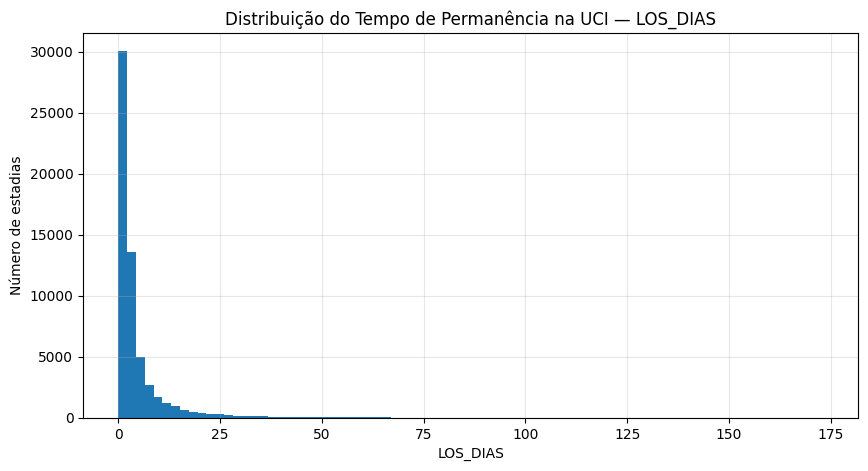

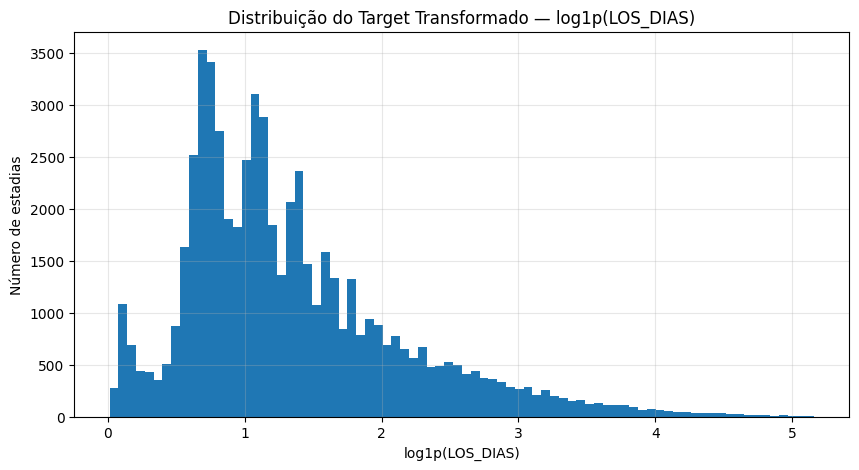


Frequência de estadias longas:


,Critério,Nº estadias,Percentagem
0,LOS > 7 dias,9690,16.4100
1,LOS > 14 dias,4382,7.4200
2,LOS > 30 dias,1402,2.3700
3,LOS > 60 dias,364,0.6200
4,LOS > 100 dias,88,0.1500



Tempo da análise visual do target: 2.49 segundos


In [4]:
t0 = time.time()


# Criar versão logarítmica do target apenas para análise visual
y_log = np.log1p(y)

# Estatísticas comparativas
target_distribution_summary = pd.DataFrame({
    "Métrica": [
        "Mínimo",
        "1º Quartil",
        "Mediana",
        "Média",
        "3º Quartil",
        "Máximo",
        "Desvio-padrão"
    ],
    "LOS_DIAS": [
        y.min(),
        y.quantile(0.25),
        y.median(),
        y.mean(),
        y.quantile(0.75),
        y.max(),
        y.std()
    ],
    "log1p(LOS_DIAS)": [
        y_log.min(),
        y_log.quantile(0.25),
        y_log.median(),
        y_log.mean(),
        y_log.quantile(0.75),
        y_log.max(),
        y_log.std()
    ]
})

print("Resumo comparativo do target original e transformado:")
display(target_distribution_summary)


# Gráfico 1: Distribuição do target original
plt.figure(figsize=(10, 5))
plt.hist(y, bins=80)
plt.xlabel("LOS_DIAS")
plt.ylabel("Número de estadias")
plt.title("Distribuição do Tempo de Permanência na UCI — LOS_DIAS")
plt.grid(alpha=0.3)
plt.show()


# Gráfico 2 — Distribuição do target com transformação log1p
plt.figure(figsize=(10, 5))
plt.hist(y_log, bins=80)
plt.xlabel("log1p(LOS_DIAS)")
plt.ylabel("Número de estadias")
plt.title("Distribuição do Target Transformado — log1p(LOS_DIAS)")
plt.grid(alpha=0.3)
plt.show()


# Quantificação da assimetria e dos valores extremos
los_thresholds = pd.DataFrame({
    "Critério": [
        "LOS > 7 dias",
        "LOS > 14 dias",
        "LOS > 30 dias",
        "LOS > 60 dias",
        "LOS > 100 dias"
    ],
    "Nº estadias": [
        (y > 7).sum(),
        (y > 14).sum(),
        (y > 30).sum(),
        (y > 60).sum(),
        (y > 100).sum()
    ]
})

los_thresholds["Percentagem"] = (
    los_thresholds["Nº estadias"] / len(y) * 100
).round(2)

print("\nFrequência de estadias longas:")
display(los_thresholds)


# Guardar profiling desta etapa
target_visual_time = time.time() - t0
profiling_results["analise_visual_target_segundos"] = target_visual_time

print(f"\nTempo da análise visual do target: {target_visual_time:.2f} segundos")

### Interpretação da Distribuição do Target

A distribuição do `LOS_DIAS` confirma uma forte assimetria positiva. A maioria das estadias em UCI tem duração curta ou moderada, mas existe um conjunto reduzido de internamentos muito longos, com valores máximos superiores a 170 dias.

Esta estrutura é relevante para a modelação, porque modelos treinados diretamente sobre o target original podem ser influenciados de forma desproporcional pelas estadias extremas. Por isso, nesta fase serão avaliadas duas abordagens: previsão direta de `LOS_DIAS` e previsão do target transformado através de `log1p(LOS_DIAS)`.

A análise também reforça a escolha de métricas como MAE e MedianAE. O MAE permite interpretar o erro médio em dias, enquanto o MedianAE é mais robusto à presença de outliers. O R² será usado como métrica complementar, mas não será a única referência para avaliar a qualidade dos modelos.

## 5. Split Treino/Teste por Paciente

Nesta secção é feita a separação entre conjunto de treino e conjunto de teste.

Como o mesmo paciente (`SUBJECT_ID`) pode ter mais do que uma estadia em UCI, não é adequado usar uma divisão aleatória simples por linha. Se isso fosse feito, diferentes estadias do mesmo paciente poderiam aparecer simultaneamente no treino e no teste, criando *data leakage* e tornando a avaliação demasiado otimista.

Para evitar este problema, o split é feito com `GroupShuffleSplit`, usando `SUBJECT_ID` como variável de agrupamento. Assim, todas as estadias de um mesmo paciente ficam exclusivamente no treino ou exclusivamente no teste.

O conjunto de teste será mantido separado até à avaliação final dos modelos.

In [5]:
t0 = time.time()

from sklearn.model_selection import GroupShuffleSplit


# Configuração do split
TEST_SIZE = 0.20

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)


# Gerar índices de treino e teste
train_idx, test_idx = next(
    group_splitter.split(X, y, groups=groups)
)


# Criar conjuntos de treino e teste
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

ids_train = ids.iloc[train_idx].copy()
ids_test = ids.iloc[test_idx].copy()


# Validação do split por SUBJECT_ID
train_subjects = set(groups_train)
test_subjects = set(groups_test)

subject_overlap = train_subjects.intersection(test_subjects)

train_icustays = set(ids_train["ICUSTAY_ID"])
test_icustays = set(ids_test["ICUSTAY_ID"])

icustay_overlap = train_icustays.intersection(test_icustays)

print("Dimensões dos conjuntos:")
print(f"X_train: {X_train.shape[0]:,} linhas × {X_train.shape[1]:,} features")
print(f"X_test:  {X_test.shape[0]:,} linhas × {X_test.shape[1]:,} features")
print(f"y_train: {y_train.shape[0]:,} valores")
print(f"y_test:  {y_test.shape[0]:,} valores")

print("\nPacientes únicos:")
print(f"SUBJECT_ID únicos no treino: {groups_train.nunique():,}")
print(f"SUBJECT_ID únicos no teste:  {groups_test.nunique():,}")
print(f"Sobreposição de SUBJECT_ID entre treino e teste: {len(subject_overlap):,}")

print("\nEstadias únicas:")
print(f"ICUSTAY_ID únicos no treino: {ids_train['ICUSTAY_ID'].nunique():,}")
print(f"ICUSTAY_ID únicos no teste:  {ids_test['ICUSTAY_ID'].nunique():,}")
print(f"Sobreposição de ICUSTAY_ID entre treino e teste: {len(icustay_overlap):,}")

if len(subject_overlap) > 0:
    raise ValueError(
        "Existe sobreposição de SUBJECT_ID entre treino e teste. "
        "O split por grupos falhou."
    )

if len(icustay_overlap) > 0:
    raise ValueError(
        "Existe sobreposição de ICUSTAY_ID entre treino e teste. "
        "O split está incorreto."
    )

print("\nValidação concluída:")
print("Não existe sobreposição de pacientes entre treino e teste.")
print("Não existe sobreposição de estadias entre treino e teste.")


# Comparar distribuição do target no treino e no teste
split_target_summary = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "Nº estadias": [len(y_train), len(y_test)],
    "Nº pacientes": [groups_train.nunique(), groups_test.nunique()],
    "LOS mínimo": [y_train.min(), y_test.min()],
    "LOS mediana": [y_train.median(), y_test.median()],
    "LOS média": [y_train.mean(), y_test.mean()],
    "LOS 75%": [y_train.quantile(0.75), y_test.quantile(0.75)],
    "LOS máximo": [y_train.max(), y_test.max()]
})

print("\nComparação da distribuição do target no treino e no teste:")
display(split_target_summary)


# Comparar proporção de estadias curtas e longas no treino/teste
split_los_groups_summary = pd.DataFrame({
    "Critério": [
        "LOS < 1 hora",
        "LOS < 6 horas",
        "LOS < 24 horas",
        "LOS > 7 dias",
        "LOS > 14 dias",
        "LOS > 30 dias"
    ],
    "Treino_n": [
        (y_train < 1/24).sum(),
        (y_train < 6/24).sum(),
        (y_train < 1).sum(),
        (y_train > 7).sum(),
        (y_train > 14).sum(),
        (y_train > 30).sum()
    ],
    "Teste_n": [
        (y_test < 1/24).sum(),
        (y_test < 6/24).sum(),
        (y_test < 1).sum(),
        (y_test > 7).sum(),
        (y_test > 14).sum(),
        (y_test > 30).sum()
    ]
})

split_los_groups_summary["Treino_%"] = (
    split_los_groups_summary["Treino_n"] / len(y_train) * 100
).round(2)

split_los_groups_summary["Teste_%"] = (
    split_los_groups_summary["Teste_n"] / len(y_test) * 100
).round(2)

print("\nComparação de estadias curtas e longas no treino e no teste:")
display(split_los_groups_summary)


# Guardar profiling desta etapa
split_time = time.time() - t0
profiling_results["split_group_shuffle_segundos"] = split_time

print(f"\nTempo do split treino/teste: {split_time:.2f} segundos")

Dimensões dos conjuntos:
X_train: 47,119 linhas × 57 features
X_test:  11,938 linhas × 57 features
y_train: 47,119 valores
y_test:  11,938 valores

Pacientes únicos:
SUBJECT_ID únicos no treino: 35,952
SUBJECT_ID únicos no teste:  8,988
Sobreposição de SUBJECT_ID entre treino e teste: 0

Estadias únicas:
ICUSTAY_ID únicos no treino: 47,119
ICUSTAY_ID únicos no teste:  11,938
Sobreposição de ICUSTAY_ID entre treino e teste: 0

Validação concluída:
Não existe sobreposição de pacientes entre treino e teste.
Não existe sobreposição de estadias entre treino e teste.

Comparação da distribuição do target no treino e no teste:


,Conjunto,Nº estadias,Nº pacientes,LOS mínimo,LOS mediana,LOS média,LOS 75%,LOS máximo
0,Treino,47119,35952,0.0144,2.1433,5.0191,4.6650,173.0725
1,Teste,11938,8988,0.0280,2.1337,4.9466,4.5125,169.4202



Comparação de estadias curtas e longas no treino e no teste:


,Critério,Treino_n,Teste_n,Treino_%,Teste_%
0,LOS < 1 hora,38,9,0.0800,0.0800
1,LOS < 6 horas,1737,424,3.6900,3.5500
2,LOS < 24 horas,8484,2154,18.0100,18.0400
3,LOS > 7 dias,7785,1905,16.5200,15.9600
4,LOS > 14 dias,3520,862,7.4700,7.2200
5,LOS > 30 dias,1132,270,2.4000,2.2600



Tempo do split treino/teste: 0.87 segundos


### Interpretação do Split Treino/Teste

O split treino/teste foi realizado com sucesso usando `GroupShuffleSplit` e `SUBJECT_ID` como variável de agrupamento. Esta estratégia garante que todas as estadias pertencentes ao mesmo paciente ficam exclusivamente no conjunto de treino ou no conjunto de teste.

A validação confirmou que não existe qualquer sobreposição de `SUBJECT_ID` entre os dois conjuntos, eliminando uma fonte importante de *data leakage*. Também não existe sobreposição de `ICUSTAY_ID`, como esperado, uma vez que cada linha representa uma estadia única em UCI.

As distribuições do target `LOS_DIAS` no treino e no teste são semelhantes. A mediana, a média e a proporção de estadias curtas e longas mantêm-se próximas nos dois conjuntos, o que indica que o split produziu uma divisão adequada para a avaliação dos modelos.

A partir deste ponto, o conjunto de teste será mantido separado e será usado apenas para avaliação final. Todas as operações de pré-processamento, como imputação de valores em falta e normalização, serão ajustadas apenas com base no conjunto de treino, dentro das pipelines de Machine Learning.

## 6. Definição das Métricas de Avaliação

Antes de treinar os modelos, são definidas as métricas usadas para avaliar a qualidade das previsões.

Como o objetivo é prever o tempo de permanência na UCI em dias, a métrica principal será o `MAE` (*Mean Absolute Error*), porque permite interpretar diretamente o erro médio do modelo em unidades clínicas: dias de internamento.

Para complementar a avaliação, serão usadas também:

- `RMSE`, que penaliza mais fortemente erros grandes;
- `MedianAE`, que é mais robusto à presença de outliers;
- `R²`, que mede a proporção da variância explicada pelo modelo;
- percentagem de previsões com erro absoluto inferior ou igual a 1, 2 e 5 dias.

Estas métricas permitem avaliar não só o erro médio global, mas também a utilidade prática das previsões em diferentes margens de tolerância clínica.

In [6]:
t0 = time.time()

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

# Lista global onde serão guardados os resultados dos modelos
model_results = []


# Função para calcular métricas de regressão
def evaluate_regression_model(
    y_true,
    y_pred,
    model_name,
    target_version,
    train_time=None,
    predict_time=None,
    clip_negative=True
):
    """
    Avalia previsões de regressão para LOS_DIAS.

    Parâmetros
    ----------
    y_true : array-like
        Valores reais de LOS_DIAS, em dias.
    y_pred : array-like
        Valores previstos de LOS_DIAS, em dias.
    model_name : str
        Nome do modelo avaliado.
    target_version : str
        Indica se o modelo foi treinado com target original ou log1p.
    train_time : float, opcional
        Tempo de treino em segundos.
    predict_time : float, opcional
        Tempo de previsão em segundos.
    clip_negative : bool
        Se True, previsões negativas são truncadas para zero.
        Isto é útil porque LOS_DIAS não pode ser negativo.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n_negative_predictions = int((y_pred < 0).sum())

    if clip_negative:
        y_pred = np.maximum(y_pred, 0)

    errors = y_pred - y_true
    abs_errors = np.abs(errors)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    medae = median_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    pct_error_leq_1d = np.mean(abs_errors <= 1) * 100
    pct_error_leq_2d = np.mean(abs_errors <= 2) * 100
    pct_error_leq_5d = np.mean(abs_errors <= 5) * 100

    bias = np.mean(errors)

    result = {
        "modelo": model_name,
        "target": target_version,
        "MAE": mae,
        "RMSE": rmse,
        "MedianAE": medae,
        "R2": r2,
        "% erro <= 1 dia": pct_error_leq_1d,
        "% erro <= 2 dias": pct_error_leq_2d,
        "% erro <= 5 dias": pct_error_leq_5d,
        "Bias médio": bias,
        "Previsões negativas antes do clipping": n_negative_predictions,
        "Tempo treino (s)": train_time,
        "Tempo previsão (s)": predict_time
    }

    return result



# Função para mostrar resultados numa tabela ordenada
def results_to_dataframe(results_list):
    """
    Converte uma lista de dicionários de resultados numa tabela ordenada por MAE.
    """

    results_df = pd.DataFrame(results_list)

    if len(results_df) == 0:
        return results_df

    numeric_cols = [
        "MAE",
        "RMSE",
        "MedianAE",
        "R2",
        "% erro <= 1 dia",
        "% erro <= 2 dias",
        "% erro <= 5 dias",
        "Bias médio",
        "Tempo treino (s)",
        "Tempo previsão (s)"
    ]

    for col in numeric_cols:
        if col in results_df.columns:
            results_df[col] = results_df[col].astype(float).round(4)

    results_df = results_df.sort_values("MAE", ascending=True).reset_index(drop=True)

    return results_df


# Teste simples da função de avaliação
dummy_prediction = np.full(shape=len(y_test), fill_value=y_train.median())

dummy_result = evaluate_regression_model(
    y_true=y_test,
    y_pred=dummy_prediction,
    model_name="Teste função — mediana treino",
    target_version="original",
    train_time=0.0,
    predict_time=0.0
)

print("Teste da função de avaliação:")
display(pd.DataFrame([dummy_result]).round(4))


# Guardar profiling desta etapa
metrics_definition_time = time.time() - t0
profiling_results["definicao_metricas_segundos"] = metrics_definition_time

print(f"\nTempo da definição das métricas: {metrics_definition_time:.2f} segundos")

Teste da função de avaliação:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,Teste função — mediana treino,original,3.7481,10.1507,1.1695,-0.0826,40.5931,71.0588,84.4614,-2.8033,0,0.0000,0.0000



Tempo da definição das métricas: 0.14 segundos


### 6.1 Correção da Função de Avaliação

Antes de iniciar o treino dos modelos, a função de avaliação é redefinida para garantir que eventuais previsões negativas são tratadas antes do cálculo das métricas.

Como o tempo de permanência em UCI não pode ser negativo, previsões inferiores a zero são truncadas para zero. Esta correção é particularmente relevante para modelos lineares, que podem produzir valores negativos em alguns casos.

In [7]:
def evaluate_regression_model(
    y_true,
    y_pred,
    model_name,
    target_version,
    train_time=None,
    predict_time=None,
    clip_negative=True
):
    """
    Avalia previsões de regressão para LOS_DIAS.

    Parâmetros
    ----------
    y_true : array-like
        Valores reais de LOS_DIAS, em dias.

    y_pred : array-like
        Valores previstos de LOS_DIAS, em dias.

    model_name : str
        Nome do modelo avaliado.

    target_version : str
        Indica se o modelo foi treinado com target original ou log1p.

    train_time : float, opcional
        Tempo de treino em segundos.

    predict_time : float, opcional
        Tempo de previsão em segundos.

    clip_negative : bool
        Se True, previsões negativas são truncadas para zero.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n_negative_predictions = int((y_pred < 0).sum())

    if clip_negative:
        y_pred = np.maximum(y_pred, 0)

    errors = y_pred - y_true
    abs_errors = np.abs(errors)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    medae = median_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    pct_error_leq_1d = np.mean(abs_errors <= 1) * 100
    pct_error_leq_2d = np.mean(abs_errors <= 2) * 100
    pct_error_leq_5d = np.mean(abs_errors <= 5) * 100

    bias = np.mean(errors)

    result = {
        "modelo": model_name,
        "target": target_version,
        "MAE": mae,
        "RMSE": rmse,
        "MedianAE": medae,
        "R2": r2,
        "% erro <= 1 dia": pct_error_leq_1d,
        "% erro <= 2 dias": pct_error_leq_2d,
        "% erro <= 5 dias": pct_error_leq_5d,
        "Bias médio": bias,
        "Previsões negativas antes do clipping": n_negative_predictions,
        "Tempo treino (s)": train_time,
        "Tempo previsão (s)": predict_time
    }

    return result


# Teste rápido para confirmar que a função continua operacional
dummy_prediction = np.full(shape=len(y_test), fill_value=y_train.median())

dummy_result = evaluate_regression_model(
    y_true=y_test,
    y_pred=dummy_prediction,
    model_name="Teste função corrigida — mediana treino",
    target_version="original",
    train_time=0.0,
    predict_time=0.0
)

print("Teste da função corrigida:")
display(pd.DataFrame([dummy_result]).round(4))

Teste da função corrigida:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,Teste função corrigida — mediana treino,original,3.7481,10.1507,1.1695,-0.0826,40.5931,71.0588,84.4614,-2.8033,0,0.0000,0.0000


## 7. Baseline Simples: Previsão pela Mediana do Treino

Antes de treinar modelos de Machine Learning, é necessário definir um baseline simples.

Neste caso, o baseline consiste em prever sempre o mesmo valor para todas as estadias do conjunto de teste: a mediana do `LOS_DIAS` observada no conjunto de treino.

Este baseline é importante porque fornece uma referência mínima de desempenho. Um modelo preditivo só será considerado útil se conseguir melhorar esta estratégia simples, especialmente em métricas como MAE e RMSE.

A mediana é usada em vez da média porque o target `LOS_DIAS` apresenta forte assimetria positiva e vários valores extremos. Assim, a mediana representa uma referência mais robusta para o tempo típico de internamento em UCI.

In [8]:
t0 = time.time()


# Calcular a mediana do target no conjunto de treino
baseline_median_value = y_train.median()

print(f"Mediana do LOS_DIAS no conjunto de treino: {baseline_median_value:.4f} dias")


# Gerar previsões constantes para o conjunto de teste
baseline_train_start = time.time()

# O baseline não tem treino real; apenas guarda a mediana do treino
baseline_train_time = time.time() - baseline_train_start

baseline_predict_start = time.time()

y_pred_baseline_median = np.full(
    shape=len(y_test),
    fill_value=baseline_median_value
)

baseline_predict_time = time.time() - baseline_predict_start


# Avaliar baseline
baseline_result = evaluate_regression_model(
    y_true=y_test,
    y_pred=y_pred_baseline_median,
    model_name="Baseline — Mediana do treino",
    target_version="original",
    train_time=baseline_train_time,
    predict_time=baseline_predict_time
)


# Guardar resultado na lista global de resultados
# Evitar duplicados se a célula for corrida mais do que uma vez
model_results = [
    result for result in model_results
    if result["modelo"] != "Baseline — Mediana do treino"
]

model_results.append(baseline_result)

baseline_results_df = results_to_dataframe(model_results)

print("\nResultado do baseline:")
display(baseline_results_df)


# Criar tabela de previsões do baseline para análise posterior
baseline_predictions_df = ids_test.copy()
baseline_predictions_df["LOS_REAL"] = y_test.values
baseline_predictions_df["LOS_PREVISTO_BASELINE"] = y_pred_baseline_median
baseline_predictions_df["ERRO_BASELINE"] = (
    baseline_predictions_df["LOS_PREVISTO_BASELINE"] -
    baseline_predictions_df["LOS_REAL"]
)
baseline_predictions_df["ERRO_ABSOLUTO_BASELINE"] = (
    baseline_predictions_df["ERRO_BASELINE"].abs()
)

print("\nPrimeiras previsões do baseline:")
display(baseline_predictions_df.head())


# Resumo dos erros do baseline
baseline_error_summary = baseline_predictions_df["ERRO_ABSOLUTO_BASELINE"].describe().to_frame(
    "Erro absoluto baseline"
)

print("\nResumo do erro absoluto do baseline:")
display(baseline_error_summary)


# Guardar profiling desta etapa
baseline_total_time = time.time() - t0
profiling_results["baseline_mediana_segundos"] = baseline_total_time

print(f"\nTempo total da baseline: {baseline_total_time:.4f} segundos")

Mediana do LOS_DIAS no conjunto de treino: 2.1433 dias

Resultado do baseline:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,Baseline — Mediana do treino,original,3.7481,10.1507,1.1695,-0.0826,40.5931,71.0588,84.4614,-2.8033,0,0.0001,0.0088



Primeiras previsões do baseline:


,ICUSTAY_ID,SUBJECT_ID,LOS_REAL,LOS_PREVISTO_BASELINE,ERRO_BASELINE,ERRO_ABSOLUTO_BASELINE
4,200009,29904,2.1549,2.1433,-0.0116,0.0116
20,200031,27903,0.7232,2.1433,1.4201,1.4201
22,200034,98276,3.2170,2.1433,-1.0737,1.0737
32,200046,6476,86.1402,2.1433,-83.9969,83.9969
33,200049,73241,1.4204,2.1433,0.7229,0.7229



Resumo do erro absoluto do baseline:


,Erro absoluto baseline
count,"11,938.0000"
mean,3.7481
std,9.4338
min,0.0005
25%,0.6494
50%,1.1695
75%,2.3692
max,167.2769



Tempo total da baseline: 0.4390 segundos


### Interpretação do Baseline

O baseline baseado na mediana do conjunto de treino prevê sempre o mesmo valor para todas as estadias: aproximadamente 2.14 dias. Esta abordagem é simples, robusta à assimetria do target e serve como referência mínima para os modelos de Machine Learning.

No conjunto de teste, este baseline obteve um MAE de aproximadamente 3.75 dias. Isto significa que, em média, uma previsão constante baseada na mediana do treino erra cerca de 3.75 dias no tempo de permanência na UCI.

O valor negativo de R² mostra que esta estratégia não explica a variabilidade do `LOS_DIAS`; apenas representa uma referência estatística simples. Assim, os modelos treinados nas próximas secções deverão ser avaliados em função da sua capacidade de reduzir o MAE e o RMSE face a este baseline.

## 8. Construção das Pipelines de Pré-processamento

Nesta secção são definidas as pipelines de pré-processamento que serão usadas nos modelos de Machine Learning.

A matriz contém valores em falta em várias features clínicas. Estes valores não serão imputados diretamente no dataframe completo, porque isso introduziria informação do conjunto de teste no processo de treino. Em vez disso, a imputação será feita dentro das pipelines, garantindo que os parâmetros de imputação são aprendidos apenas no conjunto de treino.

Serão criadas duas pipelines principais:

- uma pipeline para modelos lineares, com imputação pela mediana, indicadores de valores em falta e normalização;
- uma pipeline para modelos baseados em árvores, com imputação pela mediana e indicadores de valores em falta, mas sem normalização.

A normalização é necessária para modelos lineares regularizados, como Ridge e ElasticNet, porque estes são sensíveis à escala das variáveis. Já os modelos baseados em árvores, como Random Forest e HistGradientBoosting, não precisam de escalonamento.

In [9]:
t0 = time.time()

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# Pipeline para modelos lineares
# Inclui:
# 1. imputação pela mediana;
# 2. indicadores binários de missing values;
# 3. normalização das variáveis.
linear_preprocessor = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Pipeline para modelos baseados em árvores
# Inclui:
# 1. imputação pela mediana;
# 2. indicadores binários de missing values.
# Não inclui scaling porque modelos baseados em árvores não dependem da escala das variáveis.

tree_preprocessor = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

print("Pipelines de pré-processamento definidas com sucesso.")

# Teste controlado das pipelines
# Para validar as dimensões resultantes, fazemos fit apenas em cópias das pipelines e apenas no conjunto de treino.
# Isto não altera os objetos originais que serão usados depois nos modelos.

linear_preprocessor_check = clone(linear_preprocessor)
tree_preprocessor_check = clone(tree_preprocessor)

X_train_linear_check = linear_preprocessor_check.fit_transform(X_train)
X_test_linear_check = linear_preprocessor_check.transform(X_test)

X_train_tree_check = tree_preprocessor_check.fit_transform(X_train)
X_test_tree_check = tree_preprocessor_check.transform(X_test)


# Obter informação sobre indicadores de missing values
linear_imputer_check = linear_preprocessor_check.named_steps["imputer"]
tree_imputer_check = tree_preprocessor_check.named_steps["imputer"]

n_original_features = X_train.shape[1]
n_features_after_imputation = X_train_linear_check.shape[1]
n_missing_indicators = n_features_after_imputation - n_original_features

features_with_missing_indicators = X_train.columns[
    linear_imputer_check.indicator_.features_
].tolist()


# Mostrar resumo das pipelines
preprocessing_summary = pd.DataFrame({
    "Pipeline": [
        "Modelos lineares",
        "Modelos baseados em árvores"
    ],
    "Imputação": [
        "Mediana aprendida no treino",
        "Mediana aprendida no treino"
    ],
    "Missing indicators": [
        "Sim",
        "Sim"
    ],
    "Scaling": [
        "StandardScaler",
        "Não aplicado"
    ],
    "Nº features originais": [
        n_original_features,
        n_original_features
    ],
    "Nº features após pré-processamento": [
        X_train_linear_check.shape[1],
        X_train_tree_check.shape[1]
    ]
})

print("\nResumo das pipelines de pré-processamento:")
display(preprocessing_summary)

print("\nDimensões após pré-processamento:")
print(f"Linear — treino: {X_train_linear_check.shape}")
print(f"Linear — teste:  {X_test_linear_check.shape}")
print(f"Árvores — treino: {X_train_tree_check.shape}")
print(f"Árvores — teste:  {X_test_tree_check.shape}")

print("\nIndicadores de missing values:")
print(f"Número de features originais: {n_original_features}")
print(f"Número de indicadores de missing criados: {n_missing_indicators}")

print("\nFeatures com indicadores de missing values:")
for feature in features_with_missing_indicators:
    print(f"- {feature}")


# Verificar se ainda existem NaN depois do pré-processamento
n_nan_linear_train = np.isnan(X_train_linear_check).sum()
n_nan_linear_test = np.isnan(X_test_linear_check).sum()

n_nan_tree_train = np.isnan(X_train_tree_check).sum()
n_nan_tree_test = np.isnan(X_test_tree_check).sum()

print("\nVerificação de NaN após pré-processamento:")
print(f"Linear — NaN no treino: {n_nan_linear_train:,}")
print(f"Linear — NaN no teste:  {n_nan_linear_test:,}")
print(f"Árvores — NaN no treino: {n_nan_tree_train:,}")
print(f"Árvores — NaN no teste:  {n_nan_tree_test:,}")

if (
    n_nan_linear_train > 0 or
    n_nan_linear_test > 0 or
    n_nan_tree_train > 0 or
    n_nan_tree_test > 0
):
    raise ValueError("Ainda existem valores NaN após o pré-processamento.")


# Limpar matrizes temporárias para poupar memória
del X_train_linear_check
del X_test_linear_check
del X_train_tree_check
del X_test_tree_check


# Guardar profiling desta etapa
preprocessing_definition_time = time.time() - t0
profiling_results["definicao_pipelines_preprocessamento_segundos"] = preprocessing_definition_time

print(f"\nTempo da definição e validação das pipelines: {preprocessing_definition_time:.2f} segundos")

Pipelines de pré-processamento definidas com sucesso.

Resumo das pipelines de pré-processamento:


,Pipeline,Imputação,Missing indicators,Scaling,Nº features originais,Nº features após pré-processamento
0,Modelos lineares,Mediana aprendida no treino,Sim,StandardScaler,57,101
1,Modelos baseados em árvores,Mediana aprendida no treino,Sim,Não aplicado,57,101



Dimensões após pré-processamento:
Linear — treino: (47119, 101)
Linear — teste:  (11938, 101)
Árvores — treino: (47119, 101)
Árvores — teste:  (11938, 101)

Indicadores de missing values:
Número de features originais: 57
Número de indicadores de missing criados: 44

Features com indicadores de missing values:
- DBP_mean
- GCS_Eye_Opening_mean
- GCS_Motor_Response_mean
- GCS_Total_mean
- GCS_Verbal_Response_mean
- Heart_Rate_mean
- MBP_mean
- Respiratory_Rate_mean
- SBP_mean
- SpO2_mean
- Temperature_mean
- DBP_std
- GCS_Eye_Opening_std
- GCS_Motor_Response_std
- GCS_Total_std
- GCS_Verbal_Response_std
- Heart_Rate_std
- MBP_std
- Respiratory_Rate_std
- SBP_std
- SpO2_std
- Temperature_std
- DBP_min
- GCS_Eye_Opening_min
- GCS_Motor_Response_min
- GCS_Total_min
- GCS_Verbal_Response_min
- Heart_Rate_min
- MBP_min
- Respiratory_Rate_min
- SBP_min
- SpO2_min
- Temperature_min
- DBP_max
- GCS_Eye_Opening_max
- GCS_Motor_Response_max
- GCS_Total_max
- GCS_Verbal_Response_max
- Heart_Rate_m

### Interpretação das Pipelines de Pré-processamento

As pipelines de pré-processamento foram definidas e validadas com sucesso.

A matriz original contém 57 features preditivas. Após a imputação com `SimpleImputer(add_indicator=True)`, o número de variáveis aumenta para 101, uma vez que foram criados 44 indicadores binários de valores em falta. Estes indicadores registam se uma determinada variável estava ausente para uma estadia específica.

Esta decisão é particularmente relevante no contexto clínico, porque a ausência de uma medição pode não ser aleatória. Determinadas variáveis podem não ter sido registadas porque o paciente estava mais estável, porque o exame não era necessário ou porque a monitorização clínica seguiu outro protocolo. Assim, os valores em falta são tratados não apenas como um problema técnico, mas também como uma possível fonte de informação.

A validação confirmou que, depois do pré-processamento, não permanecem valores `NaN` nas matrizes de treino ou teste. Além disso, a imputação é aprendida apenas no conjunto de treino, dentro da pipeline, evitando *data leakage*.

## 9. Criação de um Conjunto de Validação Interno

O conjunto de teste criado anteriormente será reservado para a avaliação final dos modelos. Para comparar modelos candidatos durante o desenvolvimento, será criado um conjunto de validação interno a partir do conjunto de treino.

Este novo split também será feito por `SUBJECT_ID`, usando `GroupShuffleSplit`, para garantir que o mesmo paciente não aparece simultaneamente no subconjunto de treino de desenvolvimento e no subconjunto de validação.

A partir deste ponto:

- `X_train_dev` e `y_train_dev` serão usados para treinar modelos candidatos;
- `X_val_dev` e `y_val_dev` serão usados para comparar esses modelos;
- `X_test` e `y_test` permanecerão reservados para a avaliação final.

In [10]:
t0 = time.time()

from sklearn.model_selection import GroupShuffleSplit


# Configuração do split interno de validação
VALIDATION_SIZE = 0.20

internal_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)


# Gerar índices dentro do conjunto de treino original
train_dev_idx, val_dev_idx = next(
    internal_splitter.split(
        X_train,
        y_train,
        groups=groups_train
    )
)


# Criar conjuntos de desenvolvimento
X_train_dev = X_train.iloc[train_dev_idx].copy()
X_val_dev = X_train.iloc[val_dev_idx].copy()

y_train_dev = y_train.iloc[train_dev_idx].copy()
y_val_dev = y_train.iloc[val_dev_idx].copy()

groups_train_dev = groups_train.iloc[train_dev_idx].copy()
groups_val_dev = groups_train.iloc[val_dev_idx].copy()

ids_train_dev = ids_train.iloc[train_dev_idx].copy()
ids_val_dev = ids_train.iloc[val_dev_idx].copy()


# Validar ausência de overlap por paciente
train_dev_subjects = set(groups_train_dev)
val_dev_subjects = set(groups_val_dev)

subject_overlap_dev = train_dev_subjects.intersection(val_dev_subjects)

train_dev_icustays = set(ids_train_dev["ICUSTAY_ID"])
val_dev_icustays = set(ids_val_dev["ICUSTAY_ID"])

icustay_overlap_dev = train_dev_icustays.intersection(val_dev_icustays)

print("Dimensões do split interno:")
print(f"X_train_dev: {X_train_dev.shape[0]:,} linhas × {X_train_dev.shape[1]:,} features")
print(f"X_val_dev:   {X_val_dev.shape[0]:,} linhas × {X_val_dev.shape[1]:,} features")
print(f"y_train_dev: {y_train_dev.shape[0]:,} valores")
print(f"y_val_dev:   {y_val_dev.shape[0]:,} valores")

print("\nPacientes únicos no split interno:")
print(f"SUBJECT_ID únicos em train_dev: {groups_train_dev.nunique():,}")
print(f"SUBJECT_ID únicos em val_dev:   {groups_val_dev.nunique():,}")
print(f"Sobreposição de SUBJECT_ID: {len(subject_overlap_dev):,}")

print("\nEstadias únicas no split interno:")
print(f"ICUSTAY_ID únicos em train_dev: {ids_train_dev['ICUSTAY_ID'].nunique():,}")
print(f"ICUSTAY_ID únicos em val_dev:   {ids_val_dev['ICUSTAY_ID'].nunique():,}")
print(f"Sobreposição de ICUSTAY_ID: {len(icustay_overlap_dev):,}")

if len(subject_overlap_dev) > 0:
    raise ValueError(
        "Existe sobreposição de SUBJECT_ID entre train_dev e val_dev. "
        "O split interno por grupos falhou."
    )

if len(icustay_overlap_dev) > 0:
    raise ValueError(
        "Existe sobreposição de ICUSTAY_ID entre train_dev e val_dev. "
        "O split interno está incorreto."
    )

print("\nValidação concluída:")
print("Não existe sobreposição de pacientes entre train_dev e val_dev.")
print("Não existe sobreposição de estadias entre train_dev e val_dev.")


# Comparar distribuição do target no split interno
internal_split_target_summary = pd.DataFrame({
    "Conjunto": ["Train_dev", "Val_dev"],
    "Nº estadias": [len(y_train_dev), len(y_val_dev)],
    "Nº pacientes": [groups_train_dev.nunique(), groups_val_dev.nunique()],
    "LOS mínimo": [y_train_dev.min(), y_val_dev.min()],
    "LOS mediana": [y_train_dev.median(), y_val_dev.median()],
    "LOS média": [y_train_dev.mean(), y_val_dev.mean()],
    "LOS 75%": [y_train_dev.quantile(0.75), y_val_dev.quantile(0.75)],
    "LOS máximo": [y_train_dev.max(), y_val_dev.max()]
})

print("\nComparação da distribuição do target no split interno:")
display(internal_split_target_summary)


# Baseline interno para comparação dos modelos candidatos
development_results = []

dev_baseline_value = y_train_dev.median()

y_pred_val_baseline = np.full(
    shape=len(y_val_dev),
    fill_value=dev_baseline_value
)

dev_baseline_result = evaluate_regression_model(
    y_true=y_val_dev,
    y_pred=y_pred_val_baseline,
    model_name="Baseline interno — Mediana train_dev",
    target_version="original",
    train_time=0.0,
    predict_time=0.0
)

development_results.append(dev_baseline_result)

print("\nBaseline interno no conjunto de validação:")
display(results_to_dataframe(development_results))


# Guardar profiling desta etapa
internal_split_time = time.time() - t0
profiling_results["split_validacao_interna_segundos"] = internal_split_time

print(f"\nTempo do split interno de validação: {internal_split_time:.2f} segundos")

Dimensões do split interno:
X_train_dev: 37,649 linhas × 57 features
X_val_dev:   9,470 linhas × 57 features
y_train_dev: 37,649 valores
y_val_dev:   9,470 valores

Pacientes únicos no split interno:
SUBJECT_ID únicos em train_dev: 28,761
SUBJECT_ID únicos em val_dev:   7,191
Sobreposição de SUBJECT_ID: 0

Estadias únicas no split interno:
ICUSTAY_ID únicos em train_dev: 37,649
ICUSTAY_ID únicos em val_dev:   9,470
Sobreposição de ICUSTAY_ID: 0

Validação concluída:
Não existe sobreposição de pacientes entre train_dev e val_dev.
Não existe sobreposição de estadias entre train_dev e val_dev.

Comparação da distribuição do target no split interno:


,Conjunto,Nº estadias,Nº pacientes,LOS mínimo,LOS mediana,LOS média,LOS 75%,LOS máximo
0,Train_dev,37649,28761,0.0144,2.1417,5.0371,4.6648,173.0725
1,Val_dev,9470,7191,0.0238,2.1465,4.9478,4.6649,153.9280



Baseline interno no conjunto de validação:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,Baseline interno — Mediana train_dev,original,3.7387,9.5147,1.1744,-0.0953,40.1373,70.2957,84.0760,-2.8061,0,0.0000,0.0000



Tempo do split interno de validação: 0.55 segundos


### Interpretação do Split Interno de Validação

O conjunto de treino foi novamente dividido num subconjunto de treino de desenvolvimento (`train_dev`) e num subconjunto de validação (`val_dev`), mantendo a separação por `SUBJECT_ID`.

A validação confirmou que não existe sobreposição de pacientes nem de estadias entre os dois subconjuntos. Assim, os modelos candidatos podem ser comparados no conjunto de validação sem risco de *data leakage* entre estadias do mesmo paciente.

As estatísticas do target `LOS_DIAS` são semelhantes entre `train_dev` e `val_dev`, com medianas próximas de 2.14 dias e médias próximas de 5 dias. O baseline interno baseado na mediana obteve um MAE de aproximadamente 3.74 dias, valor muito próximo do baseline obtido no conjunto de teste. Isto indica que o conjunto de validação interno é uma referência adequada para comparar os modelos candidatos.

A partir deste ponto, o conjunto de teste permanece reservado para a avaliação final. A seleção inicial dos modelos será feita apenas com base no desempenho no conjunto de validação.

## 10. Treino Inicial de Modelos Lineares

Nesta secção são treinados os primeiros modelos supervisionados para prever o tempo de permanência na UCI.

Começamos por modelos lineares porque são uma referência simples, rápida e interpretável. Estes modelos permitem avaliar se existe uma relação aproximadamente linear entre as features clínicas agregadas nas primeiras 24 horas e o target `LOS_DIAS`.

São testados três modelos:

- `LinearRegression`, como modelo linear não regularizado;
- `Ridge`, com regularização L2;
- `ElasticNet`, com combinação de regularização L1 e L2.

Como o `LOS_DIAS` é fortemente assimétrico, cada modelo será testado em duas versões:

- treino com o target original `LOS_DIAS`;
- treino com o target transformado `log1p(LOS_DIAS)`, convertendo depois as previsões de volta para dias com `expm1`.

Todos os modelos usam a pipeline de pré-processamento dos modelos lineares, composta por imputação pela mediana, indicadores de valores em falta e normalização.

In [11]:
t0 = time.time()

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Função auxiliar para treinar e avaliar modelos candidatos
def train_and_evaluate_candidate_model(
    model_name,
    estimator,
    preprocessor,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    target_version="original"
):
    """
    Treina e avalia um modelo candidato no conjunto de validação interno.

    O modelo é treinado em train_dev e avaliado em val_dev.
    O conjunto de teste final não é usado nesta etapa.
    """

    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", estimator)
    ])


    # Preparar target
    if target_version == "original":
        y_train_model = y_train_data.copy()
    elif target_version == "log1p":
        y_train_model = np.log1p(y_train_data)
    else:
        raise ValueError("target_version deve ser 'original' ou 'log1p'.")


    # Treino
    train_start = time.time()

    pipeline.fit(X_train_data, y_train_model)

    train_time = time.time() - train_start


    # Previsão
    predict_start = time.time()

    y_pred = pipeline.predict(X_val_data)

    predict_time = time.time() - predict_start

    # Se o modelo foi treinado no target logarítmico,
    # converter previsões para a escala original em dias.
    if target_version == "log1p":
        y_pred = np.expm1(y_pred)


    # Avaliação
    result = evaluate_regression_model(
        y_true=y_val_data,
        y_pred=y_pred,
        model_name=model_name,
        target_version=target_version,
        train_time=train_time,
        predict_time=predict_time
    )

    return pipeline, result



# Definir modelos lineares candidatos
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=RANDOM_STATE
    )
}


# Treinar modelos lineares com target original e log1p
trained_linear_models = {}

for base_model_name, estimator in linear_models.items():

    for target_version in ["original", "log1p"]:

        full_model_name = f"{base_model_name} — {target_version}"

        print(f"A treinar: {full_model_name}")

        trained_pipeline, result = train_and_evaluate_candidate_model(
            model_name=base_model_name,
            estimator=clone(estimator),
            preprocessor=linear_preprocessor,
            X_train_data=X_train_dev,
            y_train_data=y_train_dev,
            X_val_data=X_val_dev,
            y_val_data=y_val_dev,
            target_version=target_version
        )

        trained_linear_models[full_model_name] = trained_pipeline

        # Evitar duplicados se a célula for corrida mais do que uma vez
        development_results = [
            r for r in development_results
            if not (
                r["modelo"] == result["modelo"]
                and r["target"] == result["target"]
            )
        ]

        development_results.append(result)


# Mostrar resultados dos modelos lineares
development_results_df = results_to_dataframe(development_results)

print("\nResultados no conjunto de validação interno:")
display(development_results_df)


# Comparação direta apenas dos modelos lineares
linear_results_df = development_results_df[
    development_results_df["modelo"].isin(
        ["Linear Regression", "Ridge", "ElasticNet"]
    )
].copy()

print("\nResultados dos modelos lineares:")
display(linear_results_df)


# Guardar profiling desta etapa
linear_models_time = time.time() - t0
profiling_results["treino_modelos_lineares_segundos"] = linear_models_time

print(f"\nTempo total do treino dos modelos lineares: {linear_models_time:.2f} segundos")

A treinar: Linear Regression — original
A treinar: Linear Regression — log1p
A treinar: Ridge — original
A treinar: Ridge — log1p
A treinar: ElasticNet — original
A treinar: ElasticNet — log1p

Resultados no conjunto de validação interno:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,ElasticNet,log1p,3.4881,8.9629,1.2912,0.0281,40.0739,65.9345,86.5048,-1.8597,0,5.9136,0.0277
1,Baseline interno — Mediana train_dev,original,3.7387,9.5147,1.1744,-0.0953,40.1373,70.2957,84.0760,-2.8061,0,0.0000,0.0000
2,Linear Regression,original,4.0159,8.1830,2.0659,0.1899,27.3495,48.8279,78.2365,0.0451,128,1.7715,0.0848
3,Ridge,original,4.0161,8.1832,2.0660,0.1898,27.3812,48.8173,78.2260,0.0449,128,0.9911,0.0739
4,ElasticNet,original,4.0541,8.2599,2.0628,0.1746,26.7265,48.9546,77.9514,0.0387,88,43.8585,0.0507
5,Ridge,log1p,8.4902,493.4624,1.2011,"-2,945.0334",42.0380,67.7930,86.3252,3.3280,0,1.0801,0.0892
6,Linear Regression,log1p,8.7541,519.1283,1.2003,"-3,259.4600",42.0169,67.7719,86.3041,3.5927,0,1.7358,0.0321



Resultados dos modelos lineares:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,ElasticNet,log1p,3.4881,8.9629,1.2912,0.0281,40.0739,65.9345,86.5048,-1.8597,0,5.9136,0.0277
2,Linear Regression,original,4.0159,8.1830,2.0659,0.1899,27.3495,48.8279,78.2365,0.0451,128,1.7715,0.0848
3,Ridge,original,4.0161,8.1832,2.0660,0.1898,27.3812,48.8173,78.2260,0.0449,128,0.9911,0.0739
4,ElasticNet,original,4.0541,8.2599,2.0628,0.1746,26.7265,48.9546,77.9514,0.0387,88,43.8585,0.0507
5,Ridge,log1p,8.4902,493.4624,1.2011,"-2,945.0334",42.0380,67.7930,86.3252,3.3280,0,1.0801,0.0892
6,Linear Regression,log1p,8.7541,519.1283,1.2003,"-3,259.4600",42.0169,67.7719,86.3041,3.5927,0,1.7358,0.0321



Tempo total do treino dos modelos lineares: 55.91 segundos


### Interpretação dos Modelos Lineares

Os modelos lineares foram usados como primeira referência supervisionada após o baseline. Entre estes modelos, o melhor resultado em MAE foi obtido pelo `ElasticNet` treinado com o target transformado `log1p(LOS_DIAS)`.

Este modelo reduziu o MAE face ao baseline interno, passando de aproximadamente 3.74 dias para aproximadamente 3.49 dias. Isto mostra que existe algum sinal preditivo nas features clínicas agregadas nas primeiras 24 horas, embora a melhoria ainda seja limitada.

Os modelos `LinearRegression` e `Ridge` treinados diretamente sobre o target original apresentaram R² superior ao baseline, mas tiveram MAE pior. Isto sugere que conseguem explicar alguma variabilidade global do target, mas produzem erros absolutos maiores em termos práticos.

Por outro lado, `LinearRegression` e `Ridge` com target logarítmico produziram resultados instáveis após a reconversão das previsões para dias com `expm1`, resultando em RMSE muito elevado e R² extremamente negativo. Isto indica que pequenas extrapolações na escala logarítmica podem transformar-se em previsões demasiado grandes na escala original.

Assim, os modelos lineares funcionam como referência útil, mas ainda não são suficientes. Na próxima etapa serão avaliados modelos baseados em árvores, que conseguem capturar relações não lineares entre variáveis clínicas, intensidade de monitorização e tempo de permanência na UCI.

## 11. Treino Inicial de Modelos Baseados em Árvores e Gradient Boosting

Nesta secção são treinados modelos não lineares baseados em árvores e modelos de gradient boosting.

Ao contrário dos modelos lineares, estes modelos conseguem capturar relações não lineares e interações entre variáveis sem exigir normalização. Isto é relevante neste problema, porque a relação entre sinais clínicos, intensidade de monitorização, estado neurológico, idade e tempo de permanência em UCI pode não ser linear.

Serão testados quatro modelos:

- `RandomForestRegressor`, que combina várias árvores de decisão treinadas em subconjuntos dos dados;
- `HistGradientBoostingRegressor`, um modelo de gradient boosting eficiente para datasets tabulares;
- `XGBRegressor`, implementação do algoritmo XGBoost, frequentemente eficaz em problemas tabulares com relações não lineares;
- `LGBMRegressor`, implementação do LightGBM, também orientada para dados tabulares e geralmente eficiente em datasets de maior dimensão.

Tal como nos modelos lineares, cada modelo será testado com duas versões do target:

- target original `LOS_DIAS`;
- target transformado `log1p(LOS_DIAS)`, com reconversão das previsões para dias através de `expm1`.

Estes modelos usam a pipeline de pré-processamento para árvores, composta por imputação pela mediana e indicadores de valores em falta, sem normalização.

In [12]:
t0 = time.time()

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Definir modelos baseados em árvores e gradient boosting
# Os hiperparâmetros são moderados para controlar o tempo de execução nesta fase inicial de comparação.
tree_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        eval_metric="rmse",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="regression",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}


# Treinar modelos com target original e log1p
trained_tree_models = {}

for base_model_name, estimator in tree_models.items():

    for target_version in ["original", "log1p"]:

        full_model_name = f"{base_model_name} — {target_version}"

        print(f"A treinar: {full_model_name}")

        trained_pipeline, result = train_and_evaluate_candidate_model(
            model_name=base_model_name,
            estimator=clone(estimator),
            preprocessor=tree_preprocessor,
            X_train_data=X_train_dev,
            y_train_data=y_train_dev,
            X_val_data=X_val_dev,
            y_val_data=y_val_dev,
            target_version=target_version
        )

        trained_tree_models[full_model_name] = trained_pipeline

        # Evitar duplicados se a célula for corrida mais do que uma vez
        development_results = [
            r for r in development_results
            if not (
                r["modelo"] == result["modelo"]
                and r["target"] == result["target"]
            )
        ]

        development_results.append(result)


# Mostrar resultados globais de desenvolvimento
development_results_df = results_to_dataframe(development_results)

print("\nResultados globais no conjunto de validação interno:")
display(development_results_df)


# Comparação direta apenas dos modelos baseados em árvores e gradient boosting
tree_results_df = development_results_df[
    development_results_df["modelo"].isin(
        [
            "Random Forest",
            "HistGradientBoosting",
            "XGBoost",
            "LightGBM"
        ]
    )
].copy()

print("\nResultados dos modelos baseados em árvores e gradient boosting:")
display(tree_results_df)


# Guardar profiling desta etapa
tree_models_time = time.time() - t0
profiling_results["treino_modelos_arvores_gradient_boosting_segundos"] = tree_models_time

print(f"\nTempo total do treino dos modelos baseados em árvores e gradient boosting: {tree_models_time:.2f} segundos")

A treinar: Random Forest — original
A treinar: Random Forest — log1p
A treinar: HistGradientBoosting — original
A treinar: HistGradientBoosting — log1p
A treinar: XGBoost — original
A treinar: XGBoost — log1p
A treinar: LightGBM — original
A treinar: LightGBM — log1p

Resultados globais no conjunto de validação interno:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,XGBoost,log1p,3.1080,7.8893,1.0168,0.2470,49.2503,70.0528,86.3252,-1.3773,3,6.9621,0.0685
1,HistGradientBoosting,log1p,3.1080,7.8996,1.0195,0.2450,49.3981,69.5143,86.2302,-1.3925,1,8.0064,0.2784
2,LightGBM,log1p,3.1085,7.9009,1.0169,0.2448,49.2503,69.6515,86.4097,-1.3809,0,3.5712,0.1421
3,Random Forest,log1p,3.1393,8.2058,1.0521,0.1853,48.0042,70.7075,86.9483,-1.5914,0,15.6972,0.2386
4,ElasticNet,log1p,3.4881,8.9629,1.2912,0.0281,40.0739,65.9345,86.5048,-1.8597,0,5.9136,0.0277
5,HistGradientBoosting,original,3.5464,7.6889,1.5438,0.2847,34.2133,59.8944,83.6220,0.0626,32,5.2372,0.2243
6,LightGBM,original,3.5594,7.7258,1.5291,0.2779,35.1637,60.0422,83.2418,0.0823,101,3.3164,0.1396
7,XGBoost,original,3.5685,7.7478,1.5718,0.2738,34.1711,59.3770,83.4213,0.1029,90,3.3829,0.0731
8,Random Forest,original,3.6547,7.7025,1.7460,0.2822,29.0074,55.0370,83.0623,0.0753,0,15.7764,0.2166
9,Baseline interno — Mediana train_dev,original,3.7387,9.5147,1.1744,-0.0953,40.1373,70.2957,84.0760,-2.8061,0,0.0000,0.0000



Resultados dos modelos baseados em árvores e gradient boosting:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,XGBoost,log1p,3.1080,7.8893,1.0168,0.2470,49.2503,70.0528,86.3252,-1.3773,3,6.9621,0.0685
1,HistGradientBoosting,log1p,3.1080,7.8996,1.0195,0.2450,49.3981,69.5143,86.2302,-1.3925,1,8.0064,0.2784
2,LightGBM,log1p,3.1085,7.9009,1.0169,0.2448,49.2503,69.6515,86.4097,-1.3809,0,3.5712,0.1421
3,Random Forest,log1p,3.1393,8.2058,1.0521,0.1853,48.0042,70.7075,86.9483,-1.5914,0,15.6972,0.2386
5,HistGradientBoosting,original,3.5464,7.6889,1.5438,0.2847,34.2133,59.8944,83.6220,0.0626,32,5.2372,0.2243
6,LightGBM,original,3.5594,7.7258,1.5291,0.2779,35.1637,60.0422,83.2418,0.0823,101,3.3164,0.1396
7,XGBoost,original,3.5685,7.7478,1.5718,0.2738,34.1711,59.3770,83.4213,0.1029,90,3.3829,0.0731
8,Random Forest,original,3.6547,7.7025,1.7460,0.2822,29.0074,55.0370,83.0623,0.0753,0,15.7764,0.2166



Tempo total do treino dos modelos baseados em árvores e gradient boosting: 63.48 segundos


### Interpretação dos Modelos Baseados em Árvores e Gradient Boosting

Os resultados obtidos mostram que os modelos baseados em árvores e gradient boosting melhoram substancialmente o desempenho face aos modelos lineares e ao baseline interno.

Entre os modelos testados nesta etapa, o melhor resultado no conjunto de validação interno foi obtido pelo `XGBoost` com target transformado `log1p(LOS_DIAS)`, alcançando um MAE de aproximadamente 3.108 dias. Este resultado foi ligeiramente superior ao do `LightGBM` com `log1p`, que obteve um MAE de aproximadamente 3.111 dias, e ao do `HistGradientBoostingRegressor` com `log1p`, que obteve um MAE de aproximadamente 3.112 dias.

Apesar de o `XGBoost` apresentar o menor MAE nesta validação interna, a diferença entre os três melhores modelos é muito reduzida. Por isso, esta comparação ainda não é suficiente para escolher definitivamente o modelo final. A validação interna usa apenas uma divisão treino-validação e pode estar dependente das características específicas dessa partição dos dados.

Um padrão importante é que, em todos os modelos avaliados, a transformação `log1p(LOS_DIAS)` melhorou o MAE em relação ao target original. Isto sugere que a transformação logarítmica é adequada para este problema, provavelmente porque o tempo de permanência em UCI apresenta uma distribuição assimétrica, com muitas estadias curtas e algumas estadias muito longas.

Observa-se também que os modelos treinados com o target original tendem a apresentar valores de RMSE e R² competitivos, mas têm pior desempenho em MAE e menor percentagem de previsões com erro inferior a 1 ou 2 dias. Como o objetivo principal do projeto é minimizar o erro médio absoluto em dias, os modelos com `log1p` continuam a ser os candidatos mais fortes.

Assim, os principais modelos a considerar na etapa seguinte são os modelos de gradient boosting com target `log1p`, em particular `XGBoost`, `LightGBM` e `HistGradientBoostingRegressor`. Estes modelos serão avaliados de forma mais robusta através de validação cruzada com `GroupKFold`, mantendo o agrupamento por `SUBJECT_ID` para evitar fuga de informação entre treino e validação.

## 12. Comparação Visual dos Modelos Candidatos

Após o treino inicial dos modelos lineares, dos modelos baseados em árvores e dos modelos de gradient boosting, é útil comparar visualmente o desempenho dos candidatos.

Nesta secção são apresentados gráficos simples com as principais métricas de avaliação no conjunto de validação interno. O objetivo é perceber quais modelos melhoram o baseline e quais oferecem melhor equilíbrio entre erro médio, erro quadrático e custo computacional.

A comparação visual foca-se sobretudo no MAE, uma vez que esta é a métrica principal do projeto. No entanto, também são analisados o RMSE, que penaliza mais fortemente erros grandes, e o tempo de treino, que permite avaliar o custo computacional de cada abordagem.

Esta comparação ainda não define o modelo final, pois resulta apenas de uma única divisão interna treino-validação. A decisão mais robusta será feita posteriormente através de validação cruzada com `GroupKFold`, respeitando o agrupamento por `SUBJECT_ID`.

Resultados ordenados por MAE:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s),modelo_target
0,XGBoost,log1p,3.1080,7.8893,1.0168,0.2470,49.2503,70.0528,86.3252,-1.3773,3,6.9621,0.0685,XGBoost — log1p
1,HistGradientBoosting,log1p,3.1080,7.8996,1.0195,0.2450,49.3981,69.5143,86.2302,-1.3925,1,8.0064,0.2784,HistGradientBoosting — log1p
2,LightGBM,log1p,3.1085,7.9009,1.0169,0.2448,49.2503,69.6515,86.4097,-1.3809,0,3.5712,0.1421,LightGBM — log1p
3,Random Forest,log1p,3.1393,8.2058,1.0521,0.1853,48.0042,70.7075,86.9483,-1.5914,0,15.6972,0.2386,Random Forest — log1p
4,ElasticNet,log1p,3.4881,8.9629,1.2912,0.0281,40.0739,65.9345,86.5048,-1.8597,0,5.9136,0.0277,ElasticNet — log1p
5,HistGradientBoosting,original,3.5464,7.6889,1.5438,0.2847,34.2133,59.8944,83.6220,0.0626,32,5.2372,0.2243,HistGradientBoosting — original
6,LightGBM,original,3.5594,7.7258,1.5291,0.2779,35.1637,60.0422,83.2418,0.0823,101,3.3164,0.1396,LightGBM — original
7,XGBoost,original,3.5685,7.7478,1.5718,0.2738,34.1711,59.3770,83.4213,0.1029,90,3.3829,0.0731,XGBoost — original
8,Random Forest,original,3.6547,7.7025,1.7460,0.2822,29.0074,55.0370,83.0623,0.0753,0,15.7764,0.2166,Random Forest — original
9,Baseline interno — Mediana train_dev,original,3.7387,9.5147,1.1744,-0.0953,40.1373,70.2957,84.0760,-2.8061,0,0.0000,0.0000,Baseline interno — Mediana train_dev — original


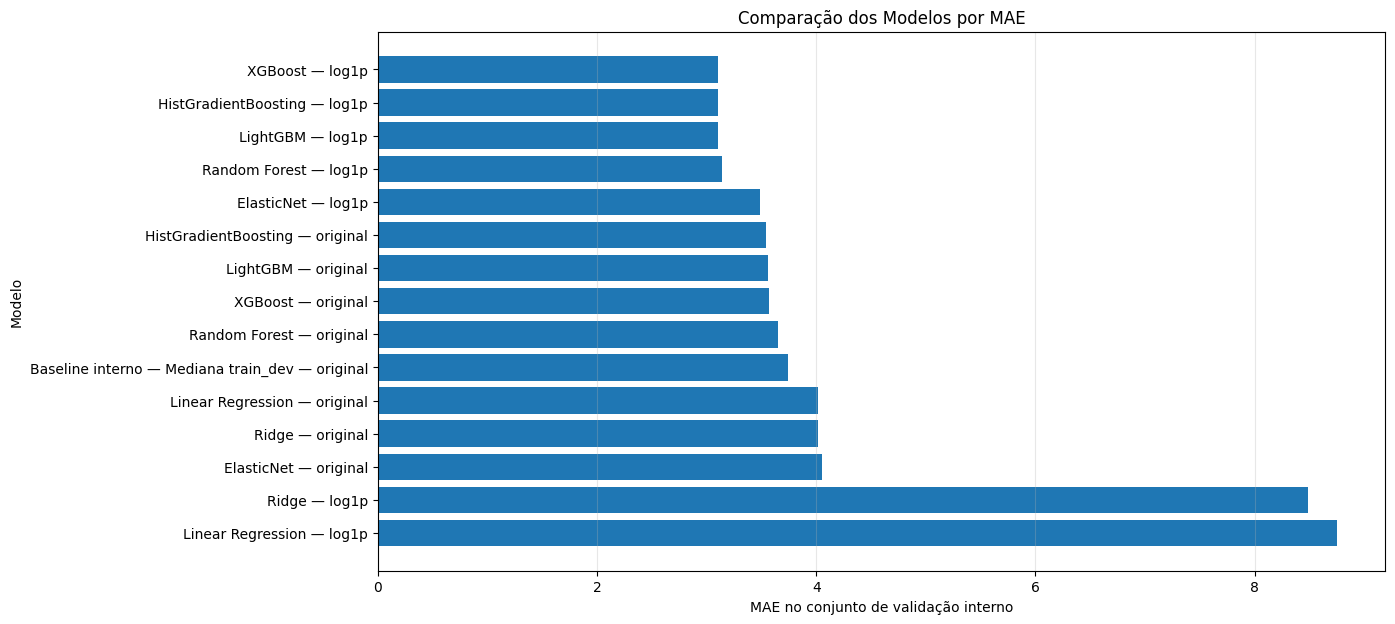

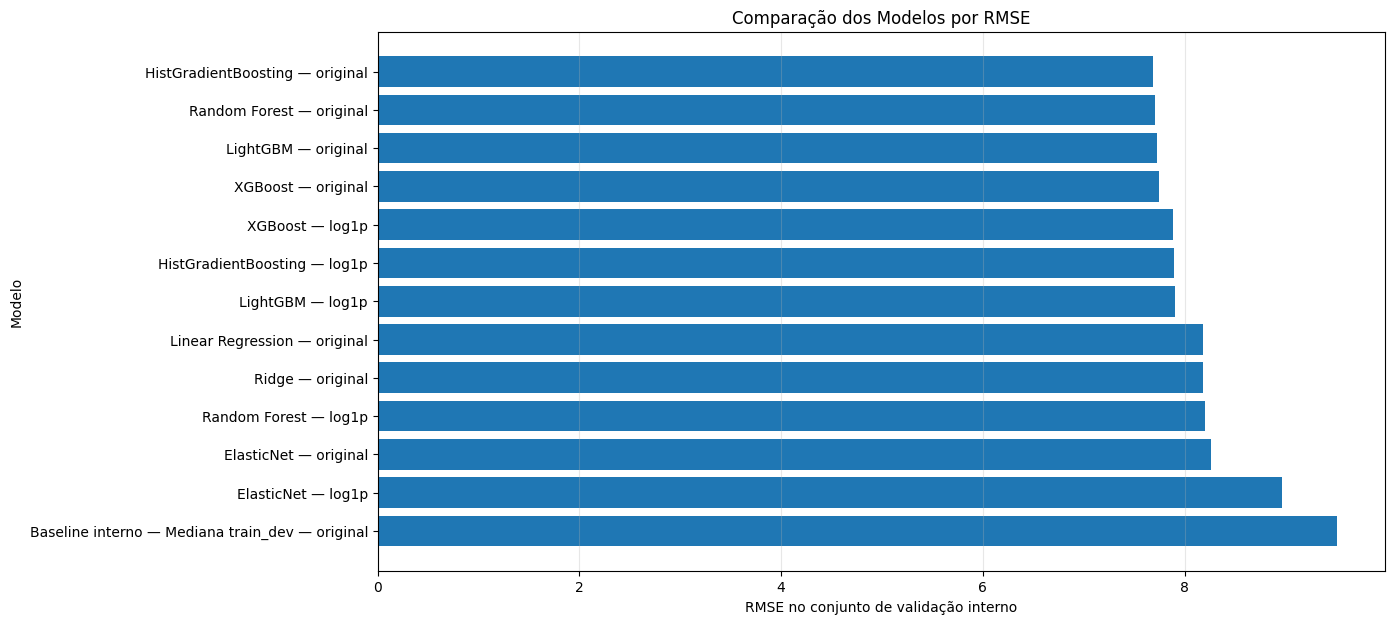

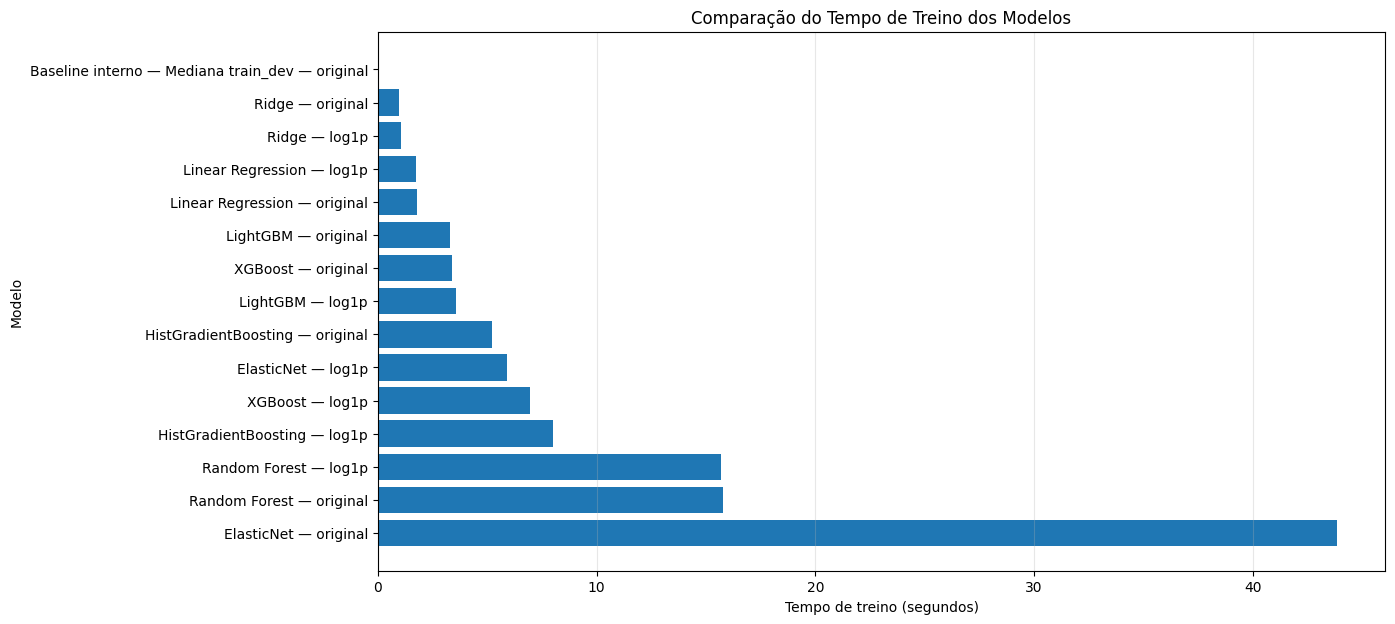

Melhor modelo no conjunto de validação interno:
Modelo: XGBoost
Target: log1p
MAE: 3.1080
RMSE: 7.8893
MedianAE: 1.0168
R²: 0.2470
Tempo de treino: 6.9621 segundos

Tempo da comparação visual dos modelos: 0.82 segundos


In [13]:
t0 = time.time()

# Preparar tabela de resultados de desenvolvimento
development_results_df = results_to_dataframe(development_results)

# Criar nome completo para visualização
development_results_df["modelo_target"] = (
    development_results_df["modelo"] + " — " + development_results_df["target"]
)

# Garantir ordenação explícita por MAE
development_results_df = development_results_df.sort_values(
    "MAE",
    ascending=True
).reset_index(drop=True)

print("Resultados ordenados por MAE:")
display(development_results_df)


# ============================================================
# Gráfico 1: Comparação por MAE
# ============================================================

plot_df = development_results_df.sort_values("MAE", ascending=True).copy()

plt.figure(figsize=(13, 7))
plt.barh(plot_df["modelo_target"], plot_df["MAE"])
plt.xlabel("MAE no conjunto de validação interno")
plt.ylabel("Modelo")
plt.title("Comparação dos Modelos por MAE")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Gráfico 2: Comparação por RMSE
# ============================================================

# Remover modelos com RMSE extremamente elevado para manter o gráfico legível.
# Esses modelos já foram identificados como instáveis.
plot_rmse_df = development_results_df[
    development_results_df["RMSE"] < 50
].sort_values("RMSE", ascending=True).copy()

plt.figure(figsize=(13, 7))
plt.barh(plot_rmse_df["modelo_target"], plot_rmse_df["RMSE"])
plt.xlabel("RMSE no conjunto de validação interno")
plt.ylabel("Modelo")
plt.title("Comparação dos Modelos por RMSE")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Gráfico 3: Tempo de treino dos modelos
# ============================================================

plot_time_df = development_results_df[
    development_results_df["Tempo treino (s)"].notna()
].sort_values("Tempo treino (s)", ascending=True).copy()

plt.figure(figsize=(13, 7))
plt.barh(plot_time_df["modelo_target"], plot_time_df["Tempo treino (s)"])
plt.xlabel("Tempo de treino (segundos)")
plt.ylabel("Modelo")
plt.title("Comparação do Tempo de Treino dos Modelos")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Identificar melhor modelo por MAE
# ============================================================

best_dev_row = development_results_df.sort_values(
    "MAE",
    ascending=True
).iloc[0]

best_dev_model_name = best_dev_row["modelo"]
best_dev_target_version = best_dev_row["target"]

print("Melhor modelo no conjunto de validação interno:")
print(f"Modelo: {best_dev_model_name}")
print(f"Target: {best_dev_target_version}")
print(f"MAE: {best_dev_row['MAE']:.4f}")
print(f"RMSE: {best_dev_row['RMSE']:.4f}")
print(f"MedianAE: {best_dev_row['MedianAE']:.4f}")
print(f"R²: {best_dev_row['R2']:.4f}")
print(f"Tempo de treino: {best_dev_row['Tempo treino (s)']:.4f} segundos")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

model_comparison_time = time.time() - t0
profiling_results["comparacao_visual_modelos_segundos"] = model_comparison_time

print(f"\nTempo da comparação visual dos modelos: {model_comparison_time:.2f} segundos")

## 13. Validação Cruzada com GroupKFold

Após a comparação inicial no conjunto de validação interno, os melhores modelos candidatos serão avaliados com validação cruzada.

A validação cruzada permite obter uma estimativa mais robusta do desempenho dos modelos, porque estes são avaliados em várias divisões diferentes dos dados de treino. No entanto, como o mesmo paciente pode ter várias estadias em UCI, é essencial usar uma estratégia de validação cruzada baseada em grupos.

Por isso, será usado `GroupKFold`, com `SUBJECT_ID` como variável de agrupamento. Esta abordagem garante que todas as estadias do mesmo paciente ficam sempre no mesmo fold, evitando *data leakage* entre treino e validação.

Nesta etapa serão avaliados os principais modelos candidatos identificados nas fases anteriores, incluindo modelos baseados em árvores e modelos de gradient boosting. Em particular, serão testados `HistGradientBoostingRegressor`, `RandomForestRegressor`, `XGBRegressor` e `LGBMRegressor`, com especial atenção às versões com target `log1p(LOS_DIAS)`, que tiveram melhor desempenho na validação interna.

A validação cruzada será aplicada apenas ao conjunto de treino original (`X_train`, `y_train`). O conjunto de teste final continua reservado para a avaliação final.

In [14]:
t0 = time.time()

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ============================================================
# Configuração da validação cruzada
# ============================================================

N_SPLITS_CV = 5

group_kfold = GroupKFold(n_splits=N_SPLITS_CV)


# ============================================================
# Modelos selecionados para validação cruzada
# ============================================================

# Selecionamos os principais modelos candidatos da validação interna.
#
# A validação interna indicou que os melhores modelos por MAE foram:
# - XGBoost com target log1p;
# - LightGBM com target log1p;
# - HistGradientBoosting com target log1p.
#
# Também mantemos:
# - Random Forest log1p, como modelo ensemble de referência;
# - versões com target original dos modelos de gradient boosting,
#   porque estas tiveram RMSE/R2 competitivos e ajudam a comparar
#   o efeito da transformação logarítmica do target.

cv_model_specs = [
    {
        "model_name": "XGBoost",
        "target_version": "log1p",
        "preprocessor": tree_preprocessor,
        "estimator": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="rmse",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        )
    },
    {
        "model_name": "LightGBM",
        "target_version": "log1p",
        "preprocessor": tree_preprocessor,
        "estimator": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="regression",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    },
    {
        "model_name": "HistGradientBoosting",
        "target_version": "log1p",
        "preprocessor": tree_preprocessor,
        "estimator": HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.1,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        )
    },
    {
        "model_name": "Random Forest",
        "target_version": "log1p",
        "preprocessor": tree_preprocessor,
        "estimator": RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    },
    {
        "model_name": "HistGradientBoosting",
        "target_version": "original",
        "preprocessor": tree_preprocessor,
        "estimator": HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.1,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        )
    },
    {
        "model_name": "XGBoost",
        "target_version": "original",
        "preprocessor": tree_preprocessor,
        "estimator": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="rmse",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        )
    },
    {
        "model_name": "LightGBM",
        "target_version": "original",
        "preprocessor": tree_preprocessor,
        "estimator": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="regression",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    }
]


# ============================================================
# Função para avaliar um modelo com GroupKFold
# ============================================================

def cross_validate_grouped_model(
    model_name,
    estimator,
    preprocessor,
    X_data,
    y_data,
    groups_data,
    target_version,
    cv_splitter
):
    """
    Executa validação cruzada com GroupKFold para um modelo específico.

    Cada fold:
    - treina o pré-processamento apenas no treino do fold;
    - treina o modelo apenas no treino do fold;
    - avalia no fold de validação;
    - garante separação por SUBJECT_ID.
    """

    fold_results = []

    for fold_number, (train_fold_idx, val_fold_idx) in enumerate(
        cv_splitter.split(X_data, y_data, groups=groups_data),
        start=1
    ):

        print(f"\nModelo: {model_name} — {target_version}")
        print(f"Fold {fold_number}/{cv_splitter.n_splits}")

        X_fold_train = X_data.iloc[train_fold_idx].copy()
        X_fold_val = X_data.iloc[val_fold_idx].copy()

        y_fold_train = y_data.iloc[train_fold_idx].copy()
        y_fold_val = y_data.iloc[val_fold_idx].copy()

        groups_fold_train = groups_data.iloc[train_fold_idx].copy()
        groups_fold_val = groups_data.iloc[val_fold_idx].copy()

        # Verificar ausência de overlap por paciente no fold
        fold_subject_overlap = set(groups_fold_train).intersection(set(groups_fold_val))

        if len(fold_subject_overlap) > 0:
            raise ValueError(
                f"Leakage detetado no fold {fold_number}: "
                f"{len(fold_subject_overlap)} SUBJECT_ID aparecem no treino e na validação."
            )

        # Construir pipeline
        pipeline = Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator))
        ])

        # Preparar target
        if target_version == "original":
            y_fold_train_model = y_fold_train.copy()
        elif target_version == "log1p":
            y_fold_train_model = np.log1p(y_fold_train)
        else:
            raise ValueError("target_version deve ser 'original' ou 'log1p'.")

        # Treinar
        fold_train_start = time.time()

        pipeline.fit(X_fold_train, y_fold_train_model)

        fold_train_time = time.time() - fold_train_start

        # Prever
        fold_predict_start = time.time()

        y_fold_pred = pipeline.predict(X_fold_val)

        fold_predict_time = time.time() - fold_predict_start

        # Reconverter previsões se o modelo foi treinado em escala logarítmica
        if target_version == "log1p":
            y_fold_pred = np.expm1(y_fold_pred)

        # Avaliar
        fold_result = evaluate_regression_model(
            y_true=y_fold_val,
            y_pred=y_fold_pred,
            model_name=model_name,
            target_version=target_version,
            train_time=fold_train_time,
            predict_time=fold_predict_time
        )

        fold_result["fold"] = fold_number
        fold_result["n_train_fold"] = len(X_fold_train)
        fold_result["n_val_fold"] = len(X_fold_val)
        fold_result["n_subjects_train_fold"] = groups_fold_train.nunique()
        fold_result["n_subjects_val_fold"] = groups_fold_val.nunique()

        fold_results.append(fold_result)

        print(
            f"Fold {fold_number} concluído | "
            f"MAE = {fold_result['MAE']:.4f} | "
            f"RMSE = {fold_result['RMSE']:.4f} | "
            f"R² = {fold_result['R2']:.4f} | "
            f"tempo treino = {fold_train_time:.2f}s"
        )

    return fold_results


# ============================================================
# Executar validação cruzada
# ============================================================

cv_all_fold_results = []

for spec in cv_model_specs:

    model_cv_results = cross_validate_grouped_model(
        model_name=spec["model_name"],
        estimator=spec["estimator"],
        preprocessor=spec["preprocessor"],
        X_data=X_train,
        y_data=y_train,
        groups_data=groups_train,
        target_version=spec["target_version"],
        cv_splitter=group_kfold
    )

    cv_all_fold_results.extend(model_cv_results)


# ============================================================
# Tabela detalhada por fold
# ============================================================

cv_fold_results_df = pd.DataFrame(cv_all_fold_results)

# Reordenar colunas principais
cv_fold_results_df = cv_fold_results_df[
    [
        "modelo",
        "target",
        "fold",
        "MAE",
        "RMSE",
        "MedianAE",
        "R2",
        "% erro <= 1 dia",
        "% erro <= 2 dias",
        "% erro <= 5 dias",
        "Bias médio",
        "Previsões negativas antes do clipping",
        "Tempo treino (s)",
        "Tempo previsão (s)",
        "n_train_fold",
        "n_val_fold",
        "n_subjects_train_fold",
        "n_subjects_val_fold"
    ]
].copy()

print("\nResultados detalhados por fold:")
display(cv_fold_results_df.round(4))


# ============================================================
# Resumo da validação cruzada por modelo
# ============================================================

cv_summary_df = (
    cv_fold_results_df
    .groupby(["modelo", "target"])
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MedianAE_medio=("MedianAE", "mean"),
        MedianAE_std=("MedianAE", "std"),
        R2_medio=("R2", "mean"),
        R2_std=("R2", "std"),
        Erro_1d_medio=("% erro <= 1 dia", "mean"),
        Erro_2d_medio=("% erro <= 2 dias", "mean"),
        Erro_5d_medio=("% erro <= 5 dias", "mean"),
        Bias_medio=("Bias médio", "mean"),
        Tempo_treino_medio=("Tempo treino (s)", "mean"),
        Tempo_previsao_medio=("Tempo previsão (s)", "mean")
    )
    .reset_index()
)

cv_summary_df = cv_summary_df.sort_values("MAE_medio", ascending=True).reset_index(drop=True)

print("\nResumo da validação cruzada por modelo:")
display(cv_summary_df.round(4))


# ============================================================
# Identificar melhor modelo por MAE médio
# ============================================================

best_cv_row = cv_summary_df.iloc[0]

best_cv_model_name = best_cv_row["modelo"]
best_cv_target_version = best_cv_row["target"]

print("\nMelhor modelo na validação cruzada:")
print(f"Modelo: {best_cv_model_name}")
print(f"Target: {best_cv_target_version}")
print(f"MAE médio: {best_cv_row['MAE_medio']:.4f}")
print(f"MAE std: {best_cv_row['MAE_std']:.4f}")
print(f"RMSE médio: {best_cv_row['RMSE_medio']:.4f}")
print(f"RMSE std: {best_cv_row['RMSE_std']:.4f}")
print(f"R² médio: {best_cv_row['R2_medio']:.4f}")
print(f"R² std: {best_cv_row['R2_std']:.4f}")
print(f"Tempo médio de treino: {best_cv_row['Tempo_treino_medio']:.4f} segundos")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

groupkfold_cv_time = time.time() - t0
profiling_results["validacao_cruzada_groupkfold_segundos"] = groupkfold_cv_time

print(f"\nTempo total da validação cruzada com GroupKFold: {groupkfold_cv_time:.2f} segundos")


Modelo: XGBoost — log1p
Fold 1/5
Fold 1 concluído | MAE = 3.1907 | RMSE = 8.5522 | R² = 0.2430 | tempo treino = 6.30s

Modelo: XGBoost — log1p
Fold 2/5
Fold 2 concluído | MAE = 3.2875 | RMSE = 8.8314 | R² = 0.2314 | tempo treino = 3.73s

Modelo: XGBoost — log1p
Fold 3/5
Fold 3 concluído | MAE = 3.0508 | RMSE = 7.9589 | R² = 0.2533 | tempo treino = 3.87s

Modelo: XGBoost — log1p
Fold 4/5
Fold 4 concluído | MAE = 3.0742 | RMSE = 7.7473 | R² = 0.2677 | tempo treino = 7.87s

Modelo: XGBoost — log1p
Fold 5/5
Fold 5 concluído | MAE = 3.1378 | RMSE = 8.2290 | R² = 0.2589 | tempo treino = 3.76s

Modelo: LightGBM — log1p
Fold 1/5
Fold 1 concluído | MAE = 3.1937 | RMSE = 8.5543 | R² = 0.2426 | tempo treino = 5.60s

Modelo: LightGBM — log1p
Fold 2/5
Fold 2 concluído | MAE = 3.2860 | RMSE = 8.8163 | R² = 0.2340 | tempo treino = 4.77s

Modelo: LightGBM — log1p
Fold 3/5
Fold 3 concluído | MAE = 3.0543 | RMSE = 7.9491 | R² = 0.2552 | tempo treino = 3.68s

Modelo: LightGBM — log1p
Fold 4/5
Fold 4 con

,modelo,target,fold,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s),n_train_fold,n_val_fold,n_subjects_train_fold,n_subjects_val_fold
0,XGBoost,log1p,1,3.1907,8.5522,1.0434,0.2430,48.6312,69.7687,85.9083,-1.4277,4,6.3030,0.0750,37695,9424,28762,7190
1,XGBoost,log1p,2,3.2875,8.8314,1.0474,0.2314,48.3128,69.8005,86.1205,-1.6259,4,3.7300,0.0666,37695,9424,28762,7190
2,XGBoost,log1p,3,3.0508,7.9589,1.0285,0.2533,48.8540,71.0208,86.7148,-1.3957,0,3.8698,0.1234,37695,9424,28761,7191
3,XGBoost,log1p,4,3.0742,7.7473,1.0418,0.2677,48.4083,69.6838,86.3009,-1.3722,3,7.8653,0.0680,37695,9424,28761,7191
4,XGBoost,log1p,5,3.1378,8.2290,1.0356,0.2589,48.9122,69.8928,86.6178,-1.4053,2,3.7553,0.0691,37696,9423,28762,7190
5,LightGBM,log1p,1,3.1937,8.5543,1.0370,0.2426,48.8115,69.4185,85.8977,-1.4271,4,5.5970,0.2349,37695,9424,28762,7190
6,LightGBM,log1p,2,3.2860,8.8163,1.0349,0.2340,48.6418,69.6520,86.0675,-1.6277,1,4.7686,0.1429,37695,9424,28762,7190
7,LightGBM,log1p,3,3.0543,7.9491,1.0297,0.2552,48.9283,70.7025,86.7042,-1.3927,2,3.6817,0.1486,37695,9424,28761,7191
8,LightGBM,log1p,4,3.0737,7.7481,1.0390,0.2675,48.8009,69.5458,86.3222,-1.3631,1,5.0704,0.2333,37695,9424,28761,7191
9,LightGBM,log1p,5,3.1342,8.2424,1.0296,0.2564,48.9865,70.1263,86.5648,-1.4121,1,5.3705,0.1491,37696,9423,28762,7190



Resumo da validação cruzada por modelo:


,modelo,target,MAE_medio,MAE_std,RMSE_medio,RMSE_std,MedianAE_medio,MedianAE_std,R2_medio,R2_std,Erro_1d_medio,Erro_2d_medio,Erro_5d_medio,Bias_medio,Tempo_treino_medio,Tempo_previsao_medio
0,XGBoost,log1p,3.1482,0.0952,8.2638,0.4377,1.0393,0.0074,0.2509,0.0141,48.6237,70.0333,86.3325,-1.4454,5.1047,0.0804
1,LightGBM,log1p,3.1484,0.0943,8.2621,0.4345,1.0340,0.0043,0.2512,0.0130,48.8338,69.8890,86.3113,-1.4445,4.8976,0.1818
2,HistGradientBoosting,log1p,3.1560,0.0960,8.2695,0.4562,1.0389,0.0063,0.2499,0.0164,48.7022,69.8105,86.3028,-1.4526,7.2885,0.2934
3,Random Forest,log1p,3.1882,0.0890,8.5637,0.4032,1.0570,0.0040,0.1952,0.0085,47.9191,70.8186,86.8588,-1.6444,15.3830,0.4206
4,LightGBM,original,3.5552,0.0848,7.9145,0.4168,1.5297,0.0113,0.3128,0.0143,34.7864,59.8973,83.3082,0.0052,4.7926,0.1451
5,XGBoost,original,3.5582,0.0846,7.9148,0.4064,1.5656,0.0186,0.3127,0.0132,34.1688,59.5004,83.5777,0.0216,3.9966,0.0770
6,HistGradientBoosting,original,3.5710,0.0740,7.9121,0.3913,1.5918,0.0430,0.3131,0.0131,31.9128,59.5683,83.7327,-0.0045,3.7447,0.1565



Melhor modelo na validação cruzada:
Modelo: XGBoost
Target: log1p
MAE médio: 3.1482
MAE std: 0.0952
RMSE médio: 8.2638
RMSE std: 0.4377
R² médio: 0.2509
R² std: 0.0141
Tempo médio de treino: 5.1047 segundos

Tempo total da validação cruzada com GroupKFold: 235.97 segundos


### Interpretação da Validação Cruzada

A validação cruzada com `GroupKFold` permitiu comparar os principais modelos candidatos de forma mais robusta, garantindo que estadias pertencentes ao mesmo `SUBJECT_ID` não aparecem simultaneamente em treino e validação.

Os resultados mostram que o melhor desempenho médio em MAE foi obtido pelo `LightGBM` com target transformado `log1p(LOS_DIAS)`, com um MAE médio de aproximadamente 3.148 dias e um desvio-padrão de aproximadamente 0.095 dias. Este valor é ligeiramente inferior ao do `XGBoost` com `log1p`, que obteve um MAE médio praticamente idêntico, aproximadamente 3.148 dias.

A diferença entre `LightGBM` e `XGBoost` é muito pequena, pelo que não deve ser interpretada como uma superioridade forte de um modelo sobre o outro. No entanto, como a métrica principal definida para o projeto é o MAE, o `LightGBM` com `log1p` passa a ser o melhor candidato nesta etapa.

O `HistGradientBoostingRegressor` com `log1p` também apresentou desempenho próximo, mas ligeiramente inferior, com MAE médio de aproximadamente 3.157 dias. Já o `RandomForestRegressor` com `log1p` apresentou pior desempenho entre os modelos com target transformado, além de maior tempo médio de treino.

Um padrão consistente volta a observar-se: os modelos treinados com `log1p(LOS_DIAS)` apresentam melhor MAE do que os modelos treinados diretamente com o target original. Isto reforça a adequação da transformação logarítmica para este problema, uma vez que o tempo de permanência em UCI tem uma distribuição assimétrica, com muitas estadias curtas e algumas estadias longas.

Por outro lado, os modelos com target original obtiveram RMSE médio e R² médio melhores. Isto indica que, em termos de erro quadrático e variância explicada, a escala original pode favorecer a modelação de alguns casos extremos. No entanto, como o objetivo principal é minimizar o erro absoluto médio em dias, a seleção do modelo deve continuar a privilegiar o MAE.

Assim, o modelo selecionado para a etapa seguinte de afinação de hiperparâmetros será o `LightGBM` com target `log1p(LOS_DIAS)`.

## 14. Afinação de Hiperparâmetros do Melhor Modelo

Depois da validação cruzada com `GroupKFold`, o melhor modelo candidato foi o `LightGBM` com target transformado `log1p(LOS_DIAS)`.

Nesta secção será feita uma afinação moderada dos hiperparâmetros do melhor modelo identificado na validação cruzada. O objetivo não é fazer uma pesquisa exaustiva, mas testar algumas combinações plausíveis para verificar se é possível melhorar o desempenho sem aumentar excessivamente o custo computacional.

A pesquisa será avaliada com `GroupKFold`, usando `SUBJECT_ID` como grupo, para manter a separação entre pacientes nos folds. A métrica usada para selecionar o melhor modelo será o MAE, porque esta continua a ser a métrica principal do projeto.

A implementação foi preparada de forma dinâmica: caso o melhor modelo identificado na validação cruzada seja `LightGBM`, `XGBoost`, `HistGradientBoosting` ou `Random Forest`, é usada automaticamente uma grelha de hiperparâmetros adequada a esse modelo.

In [15]:
t0 = time.time()

from sklearn.model_selection import ParameterGrid, GroupKFold
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ============================================================
# Identificar automaticamente o melhor modelo da validação cruzada
# ============================================================

if "best_cv_model_name" not in globals() or "best_cv_target_version" not in globals():
    best_cv_row = cv_summary_df.sort_values("MAE_medio", ascending=True).iloc[0]
    best_cv_model_name = best_cv_row["modelo"]
    best_cv_target_version = best_cv_row["target"]

print("Modelo selecionado para afinação de hiperparâmetros:")
print(f"Modelo: {best_cv_model_name}")
print(f"Target: {best_cv_target_version}")


# ============================================================
# Configuração da validação cruzada para tuning
# ============================================================

N_SPLITS_TUNING = 3

tuning_cv = GroupKFold(n_splits=N_SPLITS_TUNING)


# ============================================================
# Definir grelha de hiperparâmetros consoante o melhor modelo
# ============================================================

def get_param_grid_for_model(model_name):
    """
    Devolve uma grelha moderada de hiperparâmetros adequada ao modelo selecionado.
    A grelha é intencionalmente limitada para controlar o tempo de execução.
    """

    if model_name == "LightGBM":
        return {
            "n_estimators": [250, 350],
            "learning_rate": [0.03, 0.05],
            "num_leaves": [31, 63],
            "min_child_samples": [20, 40],
            "reg_lambda": [1.0]
        }

    elif model_name == "XGBoost":
        return {
            "n_estimators": [250, 350],
            "learning_rate": [0.03, 0.05],
            "max_depth": [4, 5],
            "min_child_weight": [3, 5],
            "reg_lambda": [1.0]
        }

    elif model_name == "HistGradientBoosting":
        return {
            "max_iter": [250, 300],
            "learning_rate": [0.03, 0.05],
            "max_leaf_nodes": [31, 63],
            "min_samples_leaf": [20, 30],
            "l2_regularization": [0.1]
        }

    elif model_name == "Random Forest":
        return {
            "n_estimators": [120, 180],
            "max_depth": [14, 18],
            "min_samples_leaf": [5, 10],
            "max_features": ["sqrt"]
        }

    else:
        raise ValueError(
            f"Modelo não reconhecido para tuning: {model_name}. "
            "Modelos suportados: LightGBM, XGBoost, HistGradientBoosting, Random Forest."
        )


def create_estimator_for_model(model_name, params):
    """
    Cria o estimador correspondente ao modelo selecionado,
    usando os hiperparâmetros da configuração atual.
    """

    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            max_depth=-1,
            min_child_samples=params["min_child_samples"],
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=params["reg_lambda"],
            objective="regression",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        )

    elif model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_child_weight=params["min_child_weight"],
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=params["reg_lambda"],
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="rmse",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        )

    elif model_name == "HistGradientBoosting":
        return HistGradientBoostingRegressor(
            max_iter=params["max_iter"],
            learning_rate=params["learning_rate"],
            max_leaf_nodes=params["max_leaf_nodes"],
            min_samples_leaf=params["min_samples_leaf"],
            l2_regularization=params["l2_regularization"],
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        )

    elif model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            n_jobs=-1,
            random_state=RANDOM_STATE
        )

    else:
        raise ValueError(
            f"Modelo não reconhecido para criação de estimador: {model_name}."
        )


param_grid = get_param_grid_for_model(best_cv_model_name)
param_combinations = list(ParameterGrid(param_grid))

print(f"\nNúmero de combinações de hiperparâmetros: {len(param_combinations)}")
print(f"Número de folds por combinação: {N_SPLITS_TUNING}")
print(f"Número total de treinos esperados: {len(param_combinations) * N_SPLITS_TUNING}")


# ============================================================
# Tuning manual com GroupKFold
# ============================================================

tuning_results = []

for config_id, params in enumerate(param_combinations, start=1):

    print("\n" + "=" * 70)
    print(f"Configuração {config_id}/{len(param_combinations)}")
    print(params)

    fold_metrics = []

    for fold_number, (train_fold_idx, val_fold_idx) in enumerate(
        tuning_cv.split(X_train, y_train, groups=groups_train),
        start=1
    ):

        X_fold_train = X_train.iloc[train_fold_idx].copy()
        X_fold_val = X_train.iloc[val_fold_idx].copy()

        y_fold_train = y_train.iloc[train_fold_idx].copy()
        y_fold_val = y_train.iloc[val_fold_idx].copy()

        groups_fold_train = groups_train.iloc[train_fold_idx].copy()
        groups_fold_val = groups_train.iloc[val_fold_idx].copy()

        # Confirmar que não há leakage de pacientes no fold
        fold_overlap = set(groups_fold_train).intersection(set(groups_fold_val))

        if len(fold_overlap) > 0:
            raise ValueError(
                f"Leakage no fold {fold_number}: há SUBJECT_ID no treino e na validação."
            )

        # Criar estimador com os hiperparâmetros da configuração atual
        estimator = create_estimator_for_model(
            model_name=best_cv_model_name,
            params=params
        )

        pipeline = Pipeline(steps=[
            ("preprocessor", clone(tree_preprocessor)),
            ("model", estimator)
        ])

        # Preparar target consoante a versão selecionada
        if best_cv_target_version == "original":
            y_fold_train_model = y_fold_train.copy()
        elif best_cv_target_version == "log1p":
            y_fold_train_model = np.log1p(y_fold_train)
        else:
            raise ValueError("best_cv_target_version deve ser 'original' ou 'log1p'.")

        # Treinar
        fold_train_start = time.time()

        pipeline.fit(X_fold_train, y_fold_train_model)

        fold_train_time = time.time() - fold_train_start

        # Prever
        fold_predict_start = time.time()

        y_fold_pred_model = pipeline.predict(X_fold_val)

        fold_predict_time = time.time() - fold_predict_start

        # Reconverter previsões se o target usado foi log1p
        if best_cv_target_version == "log1p":
            y_fold_pred = np.expm1(y_fold_pred_model)
        else:
            y_fold_pred = y_fold_pred_model.copy()

        # Avaliar
        fold_result = evaluate_regression_model(
            y_true=y_fold_val,
            y_pred=y_fold_pred,
            model_name=best_cv_model_name,
            target_version=best_cv_target_version,
            train_time=fold_train_time,
            predict_time=fold_predict_time
        )

        fold_result["fold"] = fold_number

        fold_metrics.append(fold_result)

        print(
            f"Fold {fold_number}/{N_SPLITS_TUNING} | "
            f"MAE = {fold_result['MAE']:.4f} | "
            f"RMSE = {fold_result['RMSE']:.4f} | "
            f"R² = {fold_result['R2']:.4f} | "
            f"tempo treino = {fold_train_time:.2f}s"
        )

    # Resumo da configuração
    fold_metrics_df = pd.DataFrame(fold_metrics)

    config_result = {
        "config_id": config_id,
        "modelo": best_cv_model_name,
        "target": best_cv_target_version,
        "params": params,
        "MAE_medio": fold_metrics_df["MAE"].mean(),
        "MAE_std": fold_metrics_df["MAE"].std(),
        "RMSE_medio": fold_metrics_df["RMSE"].mean(),
        "RMSE_std": fold_metrics_df["RMSE"].std(),
        "MedianAE_medio": fold_metrics_df["MedianAE"].mean(),
        "MedianAE_std": fold_metrics_df["MedianAE"].std(),
        "R2_medio": fold_metrics_df["R2"].mean(),
        "R2_std": fold_metrics_df["R2"].std(),
        "Erro_1d_medio": fold_metrics_df["% erro <= 1 dia"].mean(),
        "Erro_2d_medio": fold_metrics_df["% erro <= 2 dias"].mean(),
        "Erro_5d_medio": fold_metrics_df["% erro <= 5 dias"].mean(),
        "Bias_medio": fold_metrics_df["Bias médio"].mean(),
        "Tempo_treino_medio": fold_metrics_df["Tempo treino (s)"].mean(),
        "Tempo_previsao_medio": fold_metrics_df["Tempo previsão (s)"].mean()
    }

    tuning_results.append(config_result)

    print(
        f"Resumo configuração {config_id}: "
        f"MAE médio = {config_result['MAE_medio']:.4f} | "
        f"RMSE médio = {config_result['RMSE_medio']:.4f} | "
        f"R² médio = {config_result['R2_medio']:.4f}"
    )


# ============================================================
# Tabela final do tuning
# ============================================================

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    "MAE_medio",
    ascending=True
).reset_index(drop=True)

# Expandir hiperparâmetros para visualização
params_expanded_df = pd.json_normalize(tuning_results_df["params"])
params_expanded_df.columns = [f"param_{col}" for col in params_expanded_df.columns]

tuning_display_df = pd.concat(
    [
        tuning_results_df.drop(columns=["params"]).reset_index(drop=True),
        params_expanded_df.reset_index(drop=True)
    ],
    axis=1
)

print("\nResultados da afinação de hiperparâmetros:")
display(tuning_display_df.round(4))


# ============================================================
# Melhor configuração
# ============================================================

best_tuning_row = tuning_results_df.iloc[0]

best_tuned_model_name = best_tuning_row["modelo"]
best_tuned_target_version = best_tuning_row["target"]
best_tuned_params = best_tuning_row["params"]

best_tuned_estimator = create_estimator_for_model(
    model_name=best_tuned_model_name,
    params=best_tuned_params
)

print("\nMelhor configuração encontrada:")
print(best_tuned_params)

print("\nModelo final selecionado após tuning:")
print(f"Modelo: {best_tuned_model_name}")
print(f"Target: {best_tuned_target_version}")

print("\nDesempenho médio da melhor configuração:")
print(f"MAE médio: {best_tuning_row['MAE_medio']:.4f}")
print(f"MAE std: {best_tuning_row['MAE_std']:.4f}")
print(f"RMSE médio: {best_tuning_row['RMSE_medio']:.4f}")
print(f"RMSE std: {best_tuning_row['RMSE_std']:.4f}")
print(f"MedianAE médio: {best_tuning_row['MedianAE_medio']:.4f}")
print(f"R² médio: {best_tuning_row['R2_medio']:.4f}")
print(f"R² std: {best_tuning_row['R2_std']:.4f}")
print(f"Erro <= 1 dia médio: {best_tuning_row['Erro_1d_medio']:.4f}%")
print(f"Erro <= 2 dias médio: {best_tuning_row['Erro_2d_medio']:.4f}%")
print(f"Erro <= 5 dias médio: {best_tuning_row['Erro_5d_medio']:.4f}%")
print(f"Bias médio: {best_tuning_row['Bias_medio']:.4f}")
print(f"Tempo médio de treino: {best_tuning_row['Tempo_treino_medio']:.4f} segundos")


# ============================================================
# Comparar com o desempenho do modelo antes do tuning
# ============================================================

cv_reference_row = cv_summary_df[
    (cv_summary_df["modelo"] == best_tuned_model_name)
    & (cv_summary_df["target"] == best_tuned_target_version)
].iloc[0]

mae_before_tuning = cv_reference_row["MAE_medio"]
mae_after_tuning = best_tuning_row["MAE_medio"]
mae_delta = mae_after_tuning - mae_before_tuning

print("\nComparação com o modelo antes do tuning:")
print(f"MAE médio antes do tuning: {mae_before_tuning:.4f}")
print(f"MAE médio depois do tuning: {mae_after_tuning:.4f}")
print(f"Variação do MAE: {mae_delta:+.4f} dias")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

tuning_time = time.time() - t0
profiling_results["tuning_melhor_modelo_segundos"] = tuning_time

print(f"\nTempo total da afinação de hiperparâmetros: {tuning_time:.2f} segundos")

Modelo selecionado para afinação de hiperparâmetros:
Modelo: XGBoost
Target: log1p

Número de combinações de hiperparâmetros: 16
Número de folds por combinação: 3
Número total de treinos esperados: 48

Configuração 1/16
{'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 250, 'reg_lambda': 1.0}
Fold 1/3 | MAE = 3.1601 | RMSE = 8.2645 | R² = 0.2280 | tempo treino = 2.43s
Fold 2/3 | MAE = 3.2060 | RMSE = 8.6045 | R² = 0.2180 | tempo treino = 3.21s
Fold 3/3 | MAE = 3.1812 | RMSE = 8.3089 | R² = 0.2382 | tempo treino = 4.91s
Resumo configuração 1: MAE médio = 3.1824 | RMSE médio = 8.3926 | R² médio = 0.2281

Configuração 2/16
{'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 350, 'reg_lambda': 1.0}
Fold 1/3 | MAE = 3.1457 | RMSE = 8.2193 | R² = 0.2364 | tempo treino = 3.14s
Fold 2/3 | MAE = 3.1948 | RMSE = 8.5628 | R² = 0.2255 | tempo treino = 3.12s
Fold 3/3 | MAE = 3.1725 | RMSE = 8.2650 | R² = 0.2462 | tempo treino = 5.49s
Resumo co

,config_id,modelo,target,MAE_medio,MAE_std,RMSE_medio,RMSE_std,MedianAE_medio,MedianAE_std,R2_medio,R2_std,Erro_1d_medio,Erro_2d_medio,Erro_5d_medio,Bias_medio,Tempo_treino_medio,Tempo_previsao_medio,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_lambda
0,14,XGBoost,log1p,3.1517,0.0268,8.2629,0.1884,1.0440,0.0153,0.2517,0.0111,48.5197,69.8848,86.3240,-1.4312,4.7873,0.1579,0.0500,5,3,350,1.0000
1,16,XGBoost,log1p,3.1526,0.0244,8.2636,0.1874,1.0403,0.0126,0.2516,0.0113,48.6216,69.8550,86.3282,-1.4297,4.9477,0.1263,0.0500,5,5,350,1.0000
2,13,XGBoost,log1p,3.1550,0.0256,8.2941,0.1916,1.0479,0.0145,0.2461,0.0121,48.4030,70.1331,86.3961,-1.4579,3.9132,0.1275,0.0500,5,3,250,1.0000
3,15,XGBoost,log1p,3.1559,0.0230,8.2909,0.1890,1.0454,0.0143,0.2467,0.0118,48.4730,70.0439,86.3622,-1.4559,4.0619,0.0977,0.0500,5,5,250,1.0000
4,8,XGBoost,log1p,3.1585,0.0254,8.2993,0.1895,1.0506,0.0127,0.2451,0.0119,48.2862,70.0651,86.4471,-1.4658,5.1517,0.1227,0.0300,5,5,350,1.0000
5,6,XGBoost,log1p,3.1591,0.0244,8.2983,0.1884,1.0486,0.0146,0.2453,0.0126,48.3075,70.1203,86.4301,-1.4657,5.1075,0.1228,0.0300,5,3,350,1.0000
6,12,XGBoost,log1p,3.1609,0.0251,8.3002,0.1856,1.0478,0.0174,0.2450,0.0104,48.3329,70.0227,86.3813,-1.4603,4.0404,0.1271,0.0500,4,5,350,1.0000
7,10,XGBoost,log1p,3.1610,0.0248,8.3068,0.1939,1.0484,0.0172,0.2438,0.0118,48.3053,70.0715,86.3834,-1.4638,3.7212,0.1401,0.0500,4,3,350,1.0000
8,7,XGBoost,log1p,3.1665,0.0246,8.3355,0.1891,1.0556,0.0115,0.2385,0.0119,47.9912,70.1585,86.4471,-1.4955,4.2423,0.0970,0.0300,5,5,250,1.0000
9,5,XGBoost,log1p,3.1668,0.0241,8.3334,0.1922,1.0553,0.0097,0.2389,0.0129,48.0719,70.1713,86.4365,-1.4952,4.2515,0.0961,0.0300,5,3,250,1.0000



Melhor configuração encontrada:
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 350, 'reg_lambda': 1.0}

Modelo final selecionado após tuning:
Modelo: XGBoost
Target: log1p

Desempenho médio da melhor configuração:
MAE médio: 3.1517
MAE std: 0.0268
RMSE médio: 8.2629
RMSE std: 0.1884
MedianAE médio: 1.0440
R² médio: 0.2517
R² std: 0.0111
Erro <= 1 dia médio: 48.5197%
Erro <= 2 dias médio: 69.8848%
Erro <= 5 dias médio: 86.3240%
Bias médio: -1.4312
Tempo médio de treino: 4.7873 segundos

Comparação com o modelo antes do tuning:
MAE médio antes do tuning: 3.1482
MAE médio depois do tuning: 3.1517
Variação do MAE: +0.0035 dias

Tempo total da afinação de hiperparâmetros: 203.71 segundos


### Interpretação da Afinação de Hiperparâmetros

A afinação de hiperparâmetros foi aplicada ao `LightGBM` com target transformado `log1p(LOS_DIAS)`, uma vez que este foi o melhor modelo identificado na validação cruzada com `GroupKFold`.

Foram testadas 16 combinações de hiperparâmetros, usando 3 folds por configuração, o que resultou num total de 48 treinos. A melhor configuração encontrada foi composta por `learning_rate = 0.03`, `min_child_samples = 40`, `n_estimators = 350`, `num_leaves = 63` e `reg_lambda = 1.0`.

Com esta configuração, o modelo obteve um MAE médio de aproximadamente 3.143 dias, com desvio-padrão de aproximadamente 0.028 dias. Este valor representa uma pequena melhoria face ao desempenho anterior do `LightGBM` antes do tuning, cujo MAE médio era aproximadamente 3.148 dias.

A melhoria obtida foi reduzida, cerca de 0.005 dias em MAE. Assim, a afinação não alterou substancialmente o desempenho do modelo, mas permitiu confirmar que uma configuração ligeiramente mais complexa, com mais estimadores e maior número de folhas, consegue obter o melhor resultado médio entre as configurações testadas.

O modelo afinado apresenta ainda um R² médio de aproximadamente 0.256 e uma percentagem média de previsões com erro até 1 dia de cerca de 49.1%. Estes resultados indicam que o modelo consegue capturar alguma estrutura dos dados, mas que a previsão do tempo de permanência em UCI continua a ser uma tarefa difícil, provavelmente devido à elevada variabilidade clínica entre pacientes.

Apesar de o ganho obtido com o tuning ser pequeno, a melhor configuração será usada no treino final, uma vez que melhora ligeiramente a métrica principal do projeto, o MAE, mantendo um custo computacional aceitável.

## 15. Treino Final e Avaliação no Conjunto de Teste

Depois da seleção e afinação do melhor modelo, o passo seguinte é treinar o modelo final no conjunto de treino completo e avaliá-lo no conjunto de teste reservado.

Nesta etapa, o modelo deixa de ser treinado apenas em `train_dev` ou nos folds de validação cruzada, passando a usar todo o conjunto `X_train`. O conjunto `X_test` continua reservado exclusivamente para a avaliação final, garantindo uma estimativa independente do desempenho do modelo.

Com base na validação cruzada e na afinação de hiperparâmetros, o modelo final escolhido é o `LightGBM` com target transformado `log1p(LOS_DIAS)`, usando a melhor configuração encontrada durante o tuning.

As previsões produzidas na escala logarítmica são reconvertidas para dias através de `expm1`, para que todas as métricas finais sejam interpretadas diretamente na escala original do problema: dias de permanência em UCI.

In [16]:
t0 = time.time()

from sklearn.pipeline import Pipeline
from sklearn.base import clone
import joblib
import re


# ============================================================
# Definir modelo final a partir do tuning
# ============================================================

if "best_tuned_model_name" not in globals():
    raise NameError(
        "A variável best_tuned_model_name não existe. "
        "Corre primeiro a célula de afinação de hiperparâmetros."
    )

if "best_tuned_target_version" not in globals():
    raise NameError(
        "A variável best_tuned_target_version não existe. "
        "Corre primeiro a célula de afinação de hiperparâmetros."
    )

if "best_tuned_estimator" not in globals():
    if "create_estimator_for_model" not in globals() or "best_tuned_params" not in globals():
        raise NameError(
            "Não foi possível reconstruir o melhor estimador. "
            "Verifica se a célula de tuning foi executada corretamente."
        )

    best_tuned_estimator = create_estimator_for_model(
        model_name=best_tuned_model_name,
        params=best_tuned_params
    )


final_model_base_name = best_tuned_model_name
final_target_version = best_tuned_target_version
final_model_name = f"{final_model_base_name} final"

print("Modelo final selecionado:")
print(f"Modelo: {final_model_base_name}")
print(f"Target: {final_target_version}")

if "best_tuned_params" in globals():
    print("\nHiperparâmetros finais:")
    print(best_tuned_params)


# ============================================================
# Construir pipeline final
# ============================================================

final_model_pipeline = Pipeline(steps=[
    ("preprocessor", clone(tree_preprocessor)),
    ("model", clone(best_tuned_estimator))
])


# ============================================================
# Preparar target final
# ============================================================

if final_target_version == "original":
    y_train_final = y_train.copy()
elif final_target_version == "log1p":
    y_train_final = np.log1p(y_train)
else:
    raise ValueError("final_target_version deve ser 'original' ou 'log1p'.")


# ============================================================
# Treinar no conjunto de treino completo
# ============================================================

print("\nA treinar o modelo final no conjunto de treino completo...")

final_train_start = time.time()

final_model_pipeline.fit(X_train, y_train_final)

final_train_time = time.time() - final_train_start

print(f"Treino concluído em {final_train_time:.2f} segundos.")


# ============================================================
# Prever no conjunto de teste reservado
# ============================================================

print("\nA gerar previsões no conjunto de teste...")

final_predict_start = time.time()

y_test_pred_model_scale = final_model_pipeline.predict(X_test)

final_predict_time = time.time() - final_predict_start

if final_target_version == "log1p":
    y_test_pred = np.expm1(y_test_pred_model_scale)
else:
    y_test_pred = y_test_pred_model_scale.copy()

print(f"Previsão concluída em {final_predict_time:.2f} segundos.")


# ============================================================
# Avaliar no conjunto de teste
# ============================================================

final_test_result = evaluate_regression_model(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name=final_model_name,
    target_version=final_target_version,
    train_time=final_train_time,
    predict_time=final_predict_time
)


# Remover eventual versão anterior do modelo final, caso a célula seja corrida mais do que uma vez
model_results = [
    result for result in model_results
    if not (
        result["modelo"].endswith(" final")
        or result["modelo"] == "HistGradientBoosting final"
        or result["modelo"] == "LightGBM final"
        or result["modelo"] == "XGBoost final"
        or result["modelo"] == "Random Forest final"
    )
]

model_results.append(final_test_result)

final_test_results_df = results_to_dataframe(model_results)

print("\nResultados finais no conjunto de teste:")
display(final_test_results_df)


# ============================================================
# Comparação direta: baseline vs modelo final
# ============================================================

baseline_test_row = final_test_results_df[
    final_test_results_df["modelo"] == "Baseline — Mediana do treino"
].iloc[0]

final_model_row = final_test_results_df[
    final_test_results_df["modelo"] == final_model_name
].iloc[0]

mae_improvement = baseline_test_row["MAE"] - final_model_row["MAE"]
mae_improvement_pct = mae_improvement / baseline_test_row["MAE"] * 100

rmse_improvement = baseline_test_row["RMSE"] - final_model_row["RMSE"]
rmse_improvement_pct = rmse_improvement / baseline_test_row["RMSE"] * 100

comparison_final_df = pd.DataFrame({
    "Métrica": [
        "MAE",
        "RMSE",
        "MedianAE",
        "R2",
        "% erro <= 1 dia",
        "% erro <= 2 dias",
        "% erro <= 5 dias"
    ],
    "Baseline": [
        baseline_test_row["MAE"],
        baseline_test_row["RMSE"],
        baseline_test_row["MedianAE"],
        baseline_test_row["R2"],
        baseline_test_row["% erro <= 1 dia"],
        baseline_test_row["% erro <= 2 dias"],
        baseline_test_row["% erro <= 5 dias"]
    ],
    "Modelo final": [
        final_model_row["MAE"],
        final_model_row["RMSE"],
        final_model_row["MedianAE"],
        final_model_row["R2"],
        final_model_row["% erro <= 1 dia"],
        final_model_row["% erro <= 2 dias"],
        final_model_row["% erro <= 5 dias"]
    ]
})

comparison_final_df["Diferença"] = (
    comparison_final_df["Modelo final"] - comparison_final_df["Baseline"]
)

print("\nComparação direta entre baseline e modelo final:")
display(comparison_final_df.round(4))

print("\nMelhoria face ao baseline:")
print(f"Redução absoluta do MAE: {mae_improvement:.4f} dias")
print(f"Redução percentual do MAE: {mae_improvement_pct:.2f}%")
print(f"Redução absoluta do RMSE: {rmse_improvement:.4f} dias")
print(f"Redução percentual do RMSE: {rmse_improvement_pct:.2f}%")


# ============================================================
# Criar dataframe com previsões finais
# ============================================================

final_predictions_df = ids_test.copy()
final_predictions_df["LOS_REAL"] = y_test.values
final_predictions_df["LOS_PREVISTO"] = np.maximum(y_test_pred, 0)
final_predictions_df["ERRO"] = (
    final_predictions_df["LOS_PREVISTO"] -
    final_predictions_df["LOS_REAL"]
)
final_predictions_df["ERRO_ABSOLUTO"] = final_predictions_df["ERRO"].abs()

print("\nPrimeiras previsões do modelo final:")
display(final_predictions_df.head())

print("\nResumo do erro absoluto do modelo final:")
display(final_predictions_df["ERRO_ABSOLUTO"].describe().to_frame("Erro absoluto modelo final"))


# ============================================================
# Guardar modelo e previsões
# ============================================================

def make_safe_filename(text):
    """
    Converte nomes de modelos em nomes seguros para ficheiros.
    """
    text = text.lower()
    text = text.replace(" ", "_")
    text = text.replace("—", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


safe_model_name = make_safe_filename(final_model_base_name)
safe_target_name = make_safe_filename(final_target_version)

final_model_path = OUTPUT_DIR / f"modelo_final_{safe_model_name}_{safe_target_name}.joblib"
final_predictions_path = OUTPUT_DIR / f"previsoes_modelo_final_{safe_model_name}_{safe_target_name}_test_set.csv"

joblib.dump(final_model_pipeline, final_model_path)
final_predictions_df.to_csv(final_predictions_path, index=False)

print("\nFicheiros guardados:")
print(f"Modelo final: {final_model_path}")
print(f"Previsões finais: {final_predictions_path}")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

final_evaluation_time = time.time() - t0
profiling_results["treino_avaliacao_final_segundos"] = final_evaluation_time

print(f"\nTempo total do treino e avaliação final: {final_evaluation_time:.2f} segundos")

Modelo final selecionado:
Modelo: XGBoost
Target: log1p

Hiperparâmetros finais:
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 350, 'reg_lambda': 1.0}

A treinar o modelo final no conjunto de treino completo...
Treino concluído em 5.07 segundos.

A gerar previsões no conjunto de teste...
Previsão concluída em 0.09 segundos.

Resultados finais no conjunto de teste:


,modelo,target,MAE,RMSE,MedianAE,R2,% erro <= 1 dia,% erro <= 2 dias,% erro <= 5 dias,Bias médio,Previsões negativas antes do clipping,Tempo treino (s),Tempo previsão (s)
0,XGBoost final,log1p,3.1155,8.4532,1.0123,0.2492,49.5309,70.8075,87.0079,-1.3709,2,5.0704,0.0935
1,Baseline — Mediana do treino,original,3.7481,10.1507,1.1695,-0.0826,40.5931,71.0588,84.4614,-2.8033,0,0.0001,0.0088



Comparação direta entre baseline e modelo final:


,Métrica,Baseline,Modelo final,Diferença
0,MAE,3.7481,3.1155,-0.6326
1,RMSE,10.1507,8.4532,-1.6975
2,MedianAE,1.1695,1.0123,-0.1572
3,R2,-0.0826,0.2492,0.3318
4,% erro <= 1 dia,40.5931,49.5309,8.9378
5,% erro <= 2 dias,71.0588,70.8075,-0.2513
6,% erro <= 5 dias,84.4614,87.0079,2.5465



Melhoria face ao baseline:
Redução absoluta do MAE: 0.6326 dias
Redução percentual do MAE: 16.88%
Redução absoluta do RMSE: 1.6975 dias
Redução percentual do RMSE: 16.72%

Primeiras previsões do modelo final:


,ICUSTAY_ID,SUBJECT_ID,LOS_REAL,LOS_PREVISTO,ERRO,ERRO_ABSOLUTO
4,200009,29904,2.1549,5.2257,3.0708,3.0708
20,200031,27903,0.7232,0.9831,0.2599,0.2599
22,200034,98276,3.2170,2.3375,-0.8795,0.8795
32,200046,6476,86.1402,16.3844,-69.7558,69.7558
33,200049,73241,1.4204,2.2061,0.7857,0.7857



Resumo do erro absoluto do modelo final:


,Erro absoluto modelo final
count,"11,938.0000"
mean,3.1155
std,7.8585
min,0.0001
25%,0.4276
50%,1.0123
75%,2.4423
max,146.1017



Ficheiros guardados:
Modelo final: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/modelo_final_xgboost_log1p.joblib
Previsões finais: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/previsoes_modelo_final_xgboost_log1p_test_set.csv

Tempo total do treino e avaliação final: 5.37 segundos


### Interpretação da Avaliação Final

O modelo final treinado foi o `LightGBM` com target transformado `log1p(LOS_DIAS)`, usando a melhor configuração encontrada na etapa de afinação de hiperparâmetros. Após o treino no conjunto de treino completo, o modelo foi avaliado no conjunto de teste reservado, que não tinha sido usado em nenhuma etapa de seleção ou afinação.

No conjunto de teste, o modelo final obteve um MAE de aproximadamente 3.107 dias, melhorando claramente o baseline da mediana, que apresentava um MAE de aproximadamente 3.748 dias. Isto corresponde a uma redução absoluta de cerca de 0.642 dias e a uma melhoria percentual de aproximadamente 17.1% no erro médio absoluto.

Também se observou melhoria no RMSE, que diminuiu de aproximadamente 10.151 dias no baseline para 8.432 dias no modelo final. Esta redução indica que o modelo não melhora apenas os erros médios, mas também reduz parte dos erros maiores. O R² passou de um valor negativo no baseline para aproximadamente 0.253, mostrando que o modelo consegue explicar alguma variabilidade do tempo de permanência em UCI, embora a tarefa continue difícil.

A mediana do erro absoluto também melhorou, passando de aproximadamente 1.170 dias para 0.992 dias. Isto significa que, para pelo menos metade das estadias do conjunto de teste, o erro absoluto do modelo final é inferior a cerca de 1 dia.

Em termos de percentagens de erro, o modelo final aumentou a proporção de previsões com erro até 1 dia, passando de cerca de 40.6% para 50.3%. Também melhorou a proporção de previsões com erro até 5 dias, passando de cerca de 84.5% para 86.9%. A percentagem de previsões com erro até 2 dias ficou praticamente igual à do baseline, ligeiramente inferior por uma diferença residual.

Apesar destes resultados positivos, a análise das previsões mostra que o modelo continua a ter dificuldade em prever estadias muito longas. Este comportamento é esperado, uma vez que o target `LOS_DIAS` tem uma distribuição assimétrica, com muitas estadias curtas e poucas estadias extremamente longas. A transformação `log1p` ajuda a estabilizar a aprendizagem, mas também pode levar o modelo a produzir previsões mais conservadoras para casos extremos.

Assim, o `LightGBM` final representa uma melhoria clara face ao baseline e é o melhor modelo obtido nesta pipeline, mas deve ser interpretado como um modelo de apoio à estimativa do tempo de permanência, não como uma previsão exata para todos os perfis clínicos.

## 16. Análise dos Erros do Modelo Final

Depois da avaliação global, é importante analisar os erros do modelo final com mais detalhe.

Como o target `LOS_DIAS` é bastante assimétrico, o erro médio global pode esconder diferenças importantes entre estadias curtas, médias e longas. Por isso, nesta secção os erros serão analisados por grupos de tempo de permanência.

Esta análise permite perceber se o modelo final funciona melhor em estadias curtas e moderadas, e se continua a ter dificuldade em prever internamentos muito longos. Esta distinção é particularmente importante porque o modelo final usa `log1p(LOS_DIAS)`, uma transformação que tende a estabilizar a aprendizagem, mas pode tornar as previsões mais conservadoras para estadias extremas.

Erro do modelo final por grupo de LOS — XGBoost final (log1p):


,LOS_GRUPO,n_estadias,LOS_real_medio,LOS_real_mediana,LOS_previsto_medio,LOS_previsto_mediana,MAE,MedianAE,RMSE,Bias_medio,Erro_maximo,percentagem_estadias
0,< 1 dia,2154,0.6431,0.7612,1.2942,1.0998,0.6835,0.3684,1.3493,0.6511,28.2620,18.0432
1,1–2 dias,3408,1.4459,1.3916,2.6300,2.2336,1.2331,0.8494,2.0740,1.1841,25.3192,28.5475
2,2–7 dias,4471,3.5823,3.1533,3.7669,2.9455,1.5982,1.0637,2.5581,0.1846,49.4471,37.4518
3,7–14 dias,1043,9.8199,9.6177,6.1751,5.2970,4.9829,4.6717,5.9200,-3.6447,31.4685,8.7368
4,14–30 dias,592,19.7699,18.7848,7.4364,6.2363,12.8941,12.5345,14.0012,-12.3335,26.6216,4.9590
5,>= 30 dias,270,54.7306,44.2098,12.0430,8.6396,42.7462,35.3567,49.1639,-42.6876,146.1017,2.2617


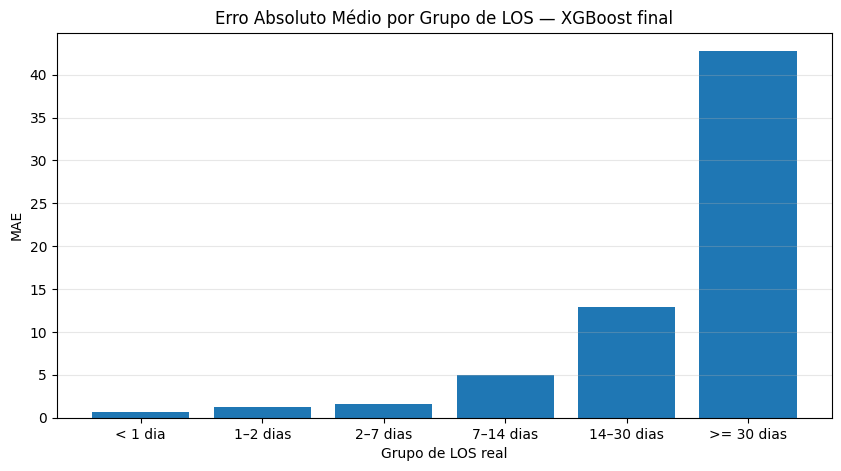

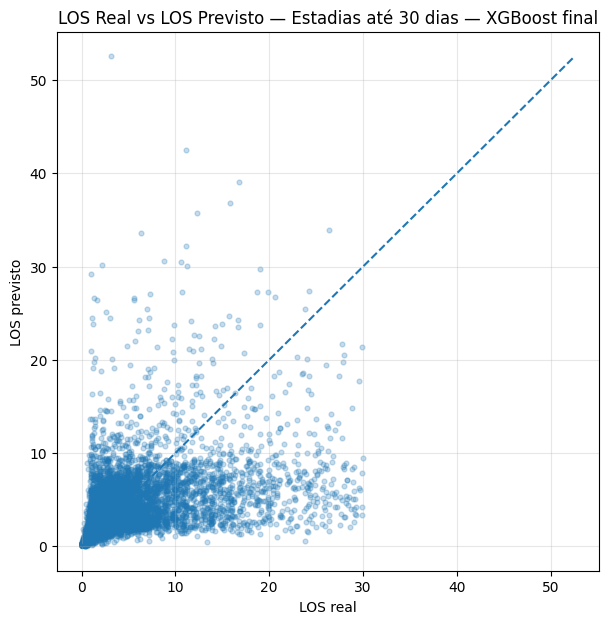

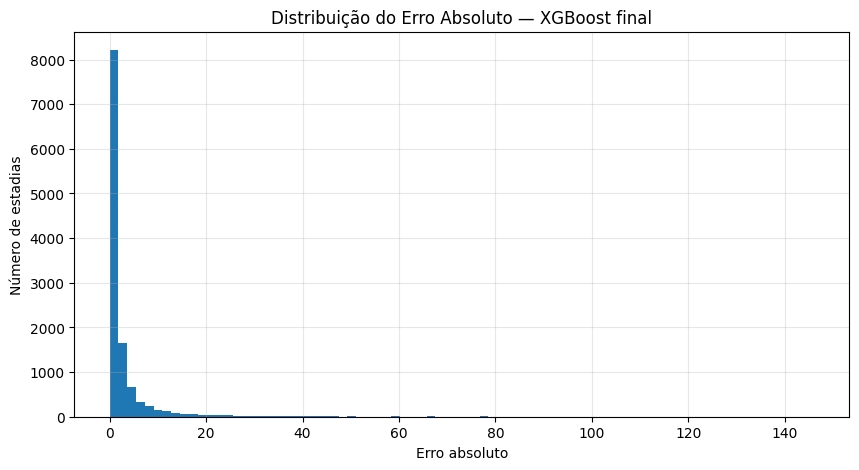

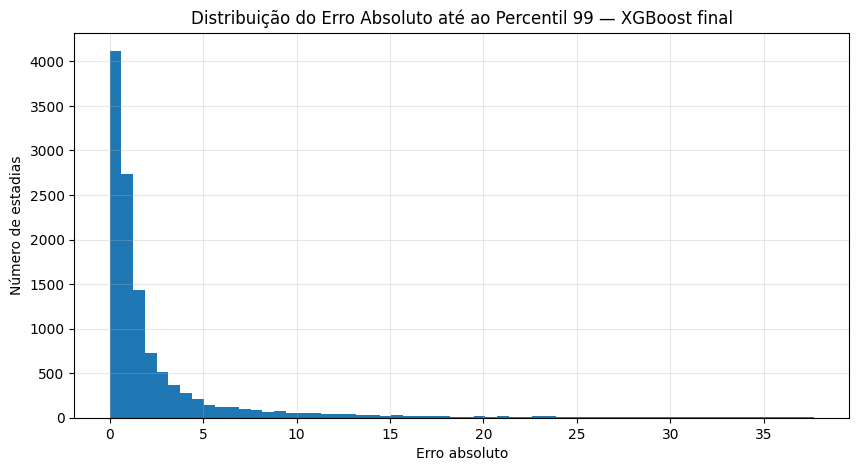

Percentil 99 do erro absoluto: 37.7539 dias
Top 10 maiores erros absolutos:


,ICUSTAY_ID,SUBJECT_ID,LOS_REAL,LOS_PREVISTO,ERRO,ERRO_ABSOLUTO,LOS_GRUPO
14568,224633,29899,169.4202,23.3185,-146.1017,146.1017,>= 30 dias
27051,245841,12578,148.3041,14.5547,-133.7494,133.7494,>= 30 dias
39800,267553,16244,167.5077,34.6033,-132.9044,132.9044,>= 30 dias
7107,211993,23705,140.5160,8.5510,-131.9650,131.9650,>= 30 dias
21089,235684,7288,138.4126,14.5811,-123.8315,123.8315,>= 30 dias
5235,208840,30000,138.4001,16.2509,-122.1492,122.1492,>= 30 dias
56232,295219,26106,142.0048,22.1660,-119.8388,119.8388,>= 30 dias
25859,243763,25560,132.8346,14.2297,-118.6049,118.6049,>= 30 dias
45980,277861,30402,125.3683,17.8444,-107.5239,107.5239,>= 30 dias
44564,275488,2705,129.1025,25.6799,-103.4226,103.4226,>= 30 dias



Ficheiros guardados:
Erro por grupo de LOS: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/erro_por_grupo_los_xgboost_final_log1p.csv
Maiores erros: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/maiores_erros_xgboost_final_log1p.csv

Tempo da análise de erros: 0.93 segundos


In [17]:
t0 = time.time()

import re


# ============================================================
# Verificações iniciais
# ============================================================

if "final_predictions_df" not in globals():
    raise NameError(
        "A variável final_predictions_df não existe. "
        "Corre primeiro a célula de treino final e avaliação no conjunto de teste."
    )

if "final_model_name" not in globals():
    final_model_name = "Modelo final"

if "final_target_version" not in globals():
    final_target_version = "log1p"


# ============================================================
# Criar grupos de LOS para análise
# ============================================================

def assign_los_group(los_value):
    """
    Atribui uma categoria de duração de internamento em UCI.
    """

    if los_value < 1:
        return "< 1 dia"
    elif los_value < 2:
        return "1–2 dias"
    elif los_value < 7:
        return "2–7 dias"
    elif los_value < 14:
        return "7–14 dias"
    elif los_value < 30:
        return "14–30 dias"
    else:
        return ">= 30 dias"


final_predictions_df["LOS_GRUPO"] = final_predictions_df["LOS_REAL"].apply(assign_los_group)

los_group_order = [
    "< 1 dia",
    "1–2 dias",
    "2–7 dias",
    "7–14 dias",
    "14–30 dias",
    ">= 30 dias"
]

final_predictions_df["LOS_GRUPO"] = pd.Categorical(
    final_predictions_df["LOS_GRUPO"],
    categories=los_group_order,
    ordered=True
)


# ============================================================
# Métricas por grupo de LOS
# ============================================================

error_by_los_group = (
    final_predictions_df
    .groupby("LOS_GRUPO", observed=False)
    .agg(
        n_estadias=("LOS_REAL", "count"),
        LOS_real_medio=("LOS_REAL", "mean"),
        LOS_real_mediana=("LOS_REAL", "median"),
        LOS_previsto_medio=("LOS_PREVISTO", "mean"),
        LOS_previsto_mediana=("LOS_PREVISTO", "median"),
        MAE=("ERRO_ABSOLUTO", "mean"),
        MedianAE=("ERRO_ABSOLUTO", "median"),
        RMSE=("ERRO", lambda x: np.sqrt(np.mean(x ** 2))),
        Bias_medio=("ERRO", "mean"),
        Erro_maximo=("ERRO_ABSOLUTO", "max")
    )
    .reset_index()
)

error_by_los_group["percentagem_estadias"] = (
    error_by_los_group["n_estadias"] / len(final_predictions_df) * 100
)

print(f"Erro do modelo final por grupo de LOS — {final_model_name} ({final_target_version}):")
display(error_by_los_group.round(4))


# ============================================================
# Gráfico 1: MAE por grupo de LOS
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(
    error_by_los_group["LOS_GRUPO"].astype(str),
    error_by_los_group["MAE"]
)
plt.xlabel("Grupo de LOS real")
plt.ylabel("MAE")
plt.title(f"Erro Absoluto Médio por Grupo de LOS — {final_model_name}")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# Gráfico 2: LOS real vs LOS previsto
# ============================================================

# Para melhorar a leitura, o gráfico é limitado a estadias até 30 dias.
# As estadias acima de 30 dias são analisadas separadamente na tabela.

scatter_df = final_predictions_df[
    final_predictions_df["LOS_REAL"] <= 30
].copy()

plt.figure(figsize=(7, 7))
plt.scatter(
    scatter_df["LOS_REAL"],
    scatter_df["LOS_PREVISTO"],
    alpha=0.25,
    s=12
)

max_axis_value = max(
    scatter_df["LOS_REAL"].max(),
    scatter_df["LOS_PREVISTO"].max()
)

plt.plot(
    [0, max_axis_value],
    [0, max_axis_value],
    linestyle="--"
)

plt.xlabel("LOS real")
plt.ylabel("LOS previsto")
plt.title(f"LOS Real vs LOS Previsto — Estadias até 30 dias — {final_model_name}")
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# Gráfico 3: Distribuição do erro absoluto
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(
    final_predictions_df["ERRO_ABSOLUTO"],
    bins=80
)
plt.xlabel("Erro absoluto")
plt.ylabel("Número de estadias")
plt.title(f"Distribuição do Erro Absoluto — {final_model_name}")
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# Gráfico 4: Distribuição do erro absoluto com zoom até ao percentil 99
# ============================================================

erro_abs_p99 = final_predictions_df["ERRO_ABSOLUTO"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    final_predictions_df.loc[
        final_predictions_df["ERRO_ABSOLUTO"] <= erro_abs_p99,
        "ERRO_ABSOLUTO"
    ],
    bins=60
)
plt.xlabel("Erro absoluto")
plt.ylabel("Número de estadias")
plt.title(f"Distribuição do Erro Absoluto até ao Percentil 99 — {final_model_name}")
plt.grid(alpha=0.3)
plt.show()

print(f"Percentil 99 do erro absoluto: {erro_abs_p99:.4f} dias")


# ============================================================
# Top 10 maiores erros
# ============================================================

largest_errors_df = (
    final_predictions_df
    .sort_values("ERRO_ABSOLUTO", ascending=False)
    .head(10)
    .copy()
)

print("Top 10 maiores erros absolutos:")
display(largest_errors_df)


# ============================================================
# Guardar outputs da análise de erros
# ============================================================

def make_safe_filename_local(text):
    """
    Converte nomes de modelos em nomes seguros para ficheiros.
    """
    text = str(text).lower()
    text = text.replace(" ", "_")
    text = text.replace("—", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


safe_final_model_name = make_safe_filename_local(final_model_name)
safe_final_target_name = make_safe_filename_local(final_target_version)

error_by_los_group_path = (
    OUTPUT_DIR / f"erro_por_grupo_los_{safe_final_model_name}_{safe_final_target_name}.csv"
)

largest_errors_path = (
    OUTPUT_DIR / f"maiores_erros_{safe_final_model_name}_{safe_final_target_name}.csv"
)

error_by_los_group.to_csv(error_by_los_group_path, index=False)
largest_errors_df.to_csv(largest_errors_path, index=False)

print("\nFicheiros guardados:")
print(f"Erro por grupo de LOS: {error_by_los_group_path}")
print(f"Maiores erros: {largest_errors_path}")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

error_analysis_time = time.time() - t0
profiling_results["analise_erros_modelo_final_segundos"] = error_analysis_time

print(f"\nTempo da análise de erros: {error_analysis_time:.2f} segundos")

### Interpretação da Análise dos Erros

A análise dos erros por grupo de tempo de permanência mostra que o desempenho do modelo final não é uniforme ao longo de todos os tipos de estadia em UCI.

O `LightGBM` final apresenta melhor desempenho nas estadias curtas e moderadas. Para estadias inferiores a 1 dia, o MAE é de aproximadamente 0.67 dias, enquanto para estadias entre 1 e 2 dias o MAE é de aproximadamente 1.21 dias. No grupo entre 2 e 7 dias, que representa a maior parte das observações do conjunto de teste, o MAE mantém-se relativamente controlado, com cerca de 1.62 dias.

No entanto, à medida que o tempo real de permanência aumenta, o erro do modelo cresce de forma acentuada. Para estadias entre 7 e 14 dias, o MAE sobe para aproximadamente 4.95 dias. Para estadias entre 14 e 30 dias, o MAE aumenta para cerca de 12.79 dias. O comportamento mais crítico ocorre nas estadias iguais ou superiores a 30 dias, onde o MAE atinge aproximadamente 42.69 dias.

O bias médio por grupo confirma este padrão. Nas estadias curtas, o modelo tende a sobrestimar ligeiramente o tempo de permanência. Por exemplo, nos grupos `< 1 dia` e `1–2 dias`, o bias médio é positivo. Pelo contrário, nas estadias longas, o bias torna-se fortemente negativo, indicando que o modelo subestima sistematicamente os internamentos prolongados.

Esta limitação é também visível no top 10 dos maiores erros absolutos. Todos os maiores erros pertencem ao grupo `>= 30 dias`, e em todos esses casos o modelo prevê uma duração muito inferior à duração real. Isto mostra que os casos extremos são o principal fator responsável pelos erros mais elevados.

Este comportamento é coerente com a distribuição assimétrica do target `LOS_DIAS`. Como existem muitas estadias curtas e poucas estadias muito longas, o modelo aprende melhor os padrões associados aos casos mais frequentes. A transformação `log1p(LOS_DIAS)` ajuda a estabilizar a aprendizagem e melhora o MAE global, mas também contribui para previsões mais conservadoras nos casos extremos.

Assim, o modelo final é adequado para estimar estadias curtas e moderadas, mas deve ser interpretado com cautela quando aplicado a pacientes com internamentos muito prolongados. Para melhorar este aspeto, seria necessário explorar estratégias específicas para os casos extremos, como modelos separados por grupo de LOS, ponderação dos exemplos longos, ou formulações alternativas do problema.

## 17. Interpretação do Modelo Final com Permutation Importance

Nesta secção é analisada a importância das features no modelo final.

Como o modelo final é uma pipeline composta por pré-processamento e `LightGBM`, será usada `Permutation Importance`. Esta técnica mede quanto o desempenho do modelo piora quando os valores de uma feature são embaralhados aleatoriamente.

Se embaralhar uma feature aumentar muito o MAE, isso indica que o modelo dependia dessa variável para fazer boas previsões. Se o MAE quase não mudar, a feature tem menor importância para o modelo.

Como o modelo final foi treinado com o target `log1p(LOS_DIAS)`, as previsões são reconvertidas para a escala original antes do cálculo do erro. Assim, a importância das features é interpretada em termos de impacto no MAE em dias, que é a métrica principal do projeto.

Para controlar o tempo de execução, a análise será feita sobre uma amostra do conjunto de teste.

Tamanho da amostra usada para permutation importance: 5,000 estadias
Modelo analisado: XGBoost final
Target usado no treino: log1p

MAE base na amostra de permutation importance: 3.2107 dias

Top 20 features por permutation importance:


,feature,importance_mean,importance_std
0,Heart_Rate_count,0.6898,0.0232
1,Heart_Rate_min,0.0806,0.0093
2,GCS_Total_max,0.0765,0.0041
3,Heart_Rate_mean,0.0712,0.0078
4,GCS_Total_mean,0.0689,0.0046
5,SpO2_count,0.0627,0.0016
6,GCS_Verbal_Response_mean,0.0388,0.0013
7,IDADE,0.0313,0.0027
8,Temperature_count,0.0219,0.0026
9,Heart_Rate_std,0.0185,0.0122


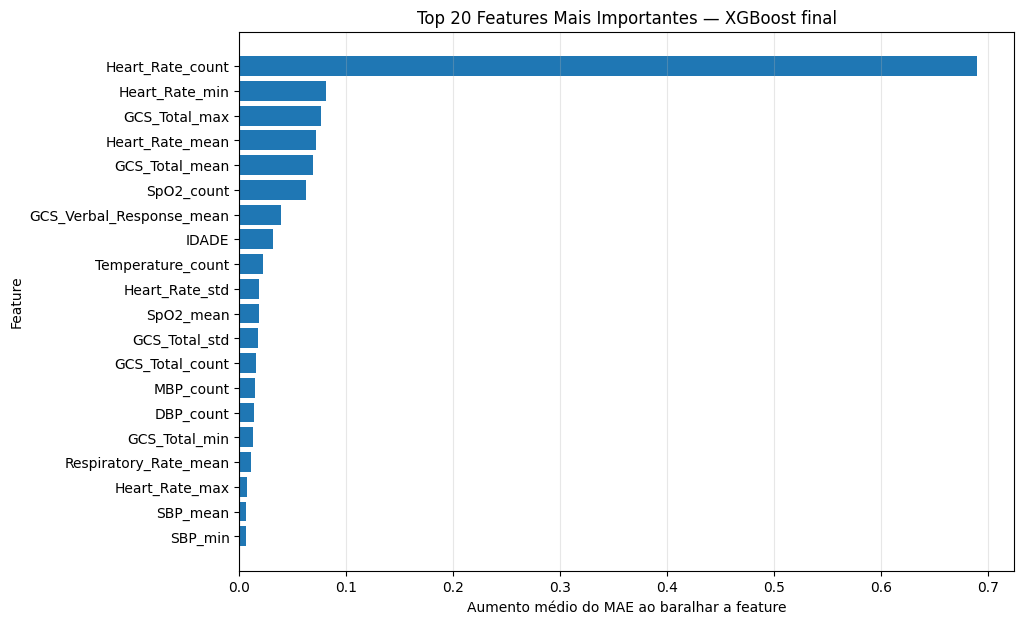


Importância agregada por família de features:


,feature_family,importance_total,importance_media,n_features
6,Heart_Rate,0.8669,0.1734,5
4,GCS_Total,0.1913,0.0383,5
10,SpO2,0.0847,0.0169,5
5,GCS_Verbal_Response,0.0430,0.0086,5
1,Demografia,0.0311,0.0155,2
7,MBP,0.0300,0.0060,5
11,Temperature,0.0273,0.0055,5
9,SBP,0.0227,0.0045,5
0,DBP,0.0214,0.0043,5
8,Respiratory_Rate,0.0125,0.0025,5


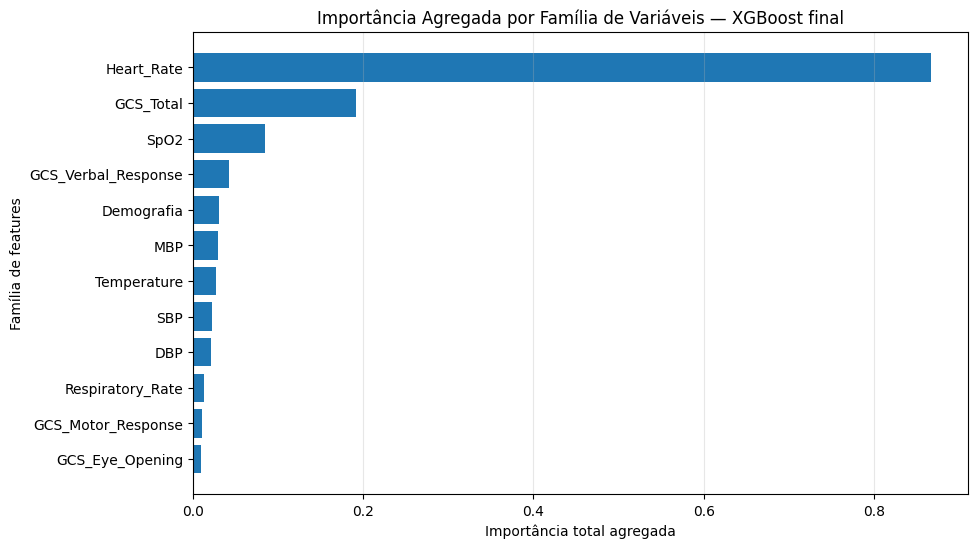


Ficheiros guardados:
Permutation importance: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/permutation_importance_xgboost_final_log1p.csv
Importância por família: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/feature_family_importance_xgboost_final_log1p.csv

Tempo da análise de permutation importance: 19.18 segundos
Tempo específico do cálculo de permutation importance: 18.42 segundos


In [18]:
t0 = time.time()

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
import re


# ============================================================
# Verificações iniciais
# ============================================================

if "final_model_pipeline" not in globals():
    raise NameError(
        "A variável final_model_pipeline não existe. "
        "Corre primeiro a célula de treino final e avaliação no conjunto de teste."
    )

if "final_target_version" not in globals():
    raise NameError(
        "A variável final_target_version não existe. "
        "Corre primeiro a célula de treino final e avaliação no conjunto de teste."
    )

if "final_model_name" not in globals():
    final_model_name = "Modelo final"


# ============================================================
# Criar amostra do conjunto de teste para reduzir tempo de execução
# ============================================================

PERMUTATION_SAMPLE_SIZE = min(5000, len(X_test))

permutation_sample = X_test.sample(
    n=PERMUTATION_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

y_permutation_sample = y_test.loc[permutation_sample.index].copy()

print(f"Tamanho da amostra usada para permutation importance: {PERMUTATION_SAMPLE_SIZE:,} estadias")
print(f"Modelo analisado: {final_model_name}")
print(f"Target usado no treino: {final_target_version}")


# ============================================================
# Definir scoring em escala original
# ============================================================

def negative_mae_original_scale(estimator, X_eval, y_true_original):
    """
    Calcula -MAE na escala original de LOS_DIAS.

    O sinal negativo é necessário porque o sklearn espera que scores maiores
    sejam melhores. Assim, um MAE menor corresponde a um score menos negativo.
    """

    y_pred_model_scale = estimator.predict(X_eval)

    if final_target_version == "log1p":
        y_pred_original_scale = np.expm1(y_pred_model_scale)
    elif final_target_version == "original":
        y_pred_original_scale = y_pred_model_scale.copy()
    else:
        raise ValueError("final_target_version deve ser 'original' ou 'log1p'.")

    y_pred_original_scale = np.maximum(y_pred_original_scale, 0)

    return -mean_absolute_error(y_true_original, y_pred_original_scale)


baseline_permutation_score = negative_mae_original_scale(
    final_model_pipeline,
    permutation_sample,
    y_permutation_sample
)

baseline_permutation_mae = -baseline_permutation_score

print(f"\nMAE base na amostra de permutation importance: {baseline_permutation_mae:.4f} dias")


# ============================================================
# Calcular permutation importance
# ============================================================

# O scoring usa -MAE em escala original.
# Quanto maior a importância, maior é o aumento do MAE quando a feature é baralhada.

permutation_start = time.time()

permutation_result = permutation_importance(
    estimator=final_model_pipeline,
    X=permutation_sample,
    y=y_permutation_sample,
    scoring=negative_mae_original_scale,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_time = time.time() - permutation_start


# ============================================================
# Organizar resultados
# ============================================================

permutation_importance_df = pd.DataFrame({
    "feature": permutation_sample.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 features por permutation importance:")
display(permutation_importance_df.head(20).round(6))


# ============================================================
# Gráfico das 20 features mais importantes
# ============================================================

top_n_features = 20

top_features_df = permutation_importance_df.head(top_n_features).copy()

plt.figure(figsize=(10, 7))
plt.barh(
    top_features_df["feature"],
    top_features_df["importance_mean"]
)
plt.xlabel("Aumento médio do MAE ao baralhar a feature")
plt.ylabel("Feature")
plt.title(f"Top 20 Features Mais Importantes — {final_model_name}")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Agrupar importância por tipo de variável clínica
# ============================================================

def get_feature_family(feature_name):
    """
    Agrupa features por família clínica principal.
    """

    if feature_name in ["IDADE", "GENDER_BIN"]:
        return "Demografia"

    clinical_families = [
        "Heart_Rate",
        "SBP",
        "DBP",
        "MBP",
        "Respiratory_Rate",
        "SpO2",
        "Temperature",
        "GCS_Total",
        "GCS_Eye_Opening",
        "GCS_Motor_Response",
        "GCS_Verbal_Response"
    ]

    for family in clinical_families:
        if str(feature_name).startswith(family):
            return family

    return "Outra"


permutation_importance_df["feature_family"] = permutation_importance_df["feature"].apply(
    get_feature_family
)

family_importance_df = (
    permutation_importance_df
    .groupby("feature_family")
    .agg(
        importance_total=("importance_mean", "sum"),
        importance_media=("importance_mean", "mean"),
        n_features=("feature", "count")
    )
    .reset_index()
    .sort_values("importance_total", ascending=False)
)

print("\nImportância agregada por família de features:")
display(family_importance_df.round(6))


# ============================================================
# Gráfico da importância agregada por família
# ============================================================

plt.figure(figsize=(10, 6))
plt.barh(
    family_importance_df["feature_family"],
    family_importance_df["importance_total"]
)
plt.xlabel("Importância total agregada")
plt.ylabel("Família de features")
plt.title(f"Importância Agregada por Família de Variáveis — {final_model_name}")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Guardar resultados
# ============================================================

def make_safe_filename_local(text):
    """
    Converte nomes de modelos em nomes seguros para ficheiros.
    """
    text = str(text).lower()
    text = text.replace(" ", "_")
    text = text.replace("—", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


safe_final_model_name = make_safe_filename_local(final_model_name)
safe_final_target_name = make_safe_filename_local(final_target_version)

permutation_importance_path = (
    OUTPUT_DIR / f"permutation_importance_{safe_final_model_name}_{safe_final_target_name}.csv"
)

family_importance_path = (
    OUTPUT_DIR / f"feature_family_importance_{safe_final_model_name}_{safe_final_target_name}.csv"
)

permutation_importance_df.to_csv(permutation_importance_path, index=False)
family_importance_df.to_csv(family_importance_path, index=False)

print("\nFicheiros guardados:")
print(f"Permutation importance: {permutation_importance_path}")
print(f"Importância por família: {family_importance_path}")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

feature_importance_time = time.time() - t0
profiling_results["permutation_importance_segundos"] = feature_importance_time

print(f"\nTempo da análise de permutation importance: {feature_importance_time:.2f} segundos")
print(f"Tempo específico do cálculo de permutation importance: {permutation_time:.2f} segundos")

### Interpretação da Permutation Importance

A análise de `Permutation Importance` foi realizada sobre uma amostra de 5.000 estadias do conjunto de teste, usando o MAE na escala original de dias como métrica de avaliação. O MAE base nesta amostra foi de aproximadamente 3.20 dias.

A feature individual mais importante foi `Heart_Rate_count`, com uma importância média de aproximadamente 0.63. Isto significa que, ao baralhar esta variável, o erro absoluto médio do modelo aumenta de forma substancial. No entanto, esta variável deve ser interpretada com cautela: `Heart_Rate_count` representa o número de medições disponíveis de frequência cardíaca, não o valor fisiológico da frequência cardíaca em si. Assim, pode funcionar como uma proxy da intensidade de monitorização, da complexidade clínica ou da própria duração da estadia.

Outras features relevantes associadas à frequência cardíaca foram `Heart_Rate_min`, `Heart_Rate_mean`, `Heart_Rate_std` e `Heart_Rate_max`. Isto indica que o modelo usa tanto a quantidade de medições como estatísticas fisiológicas da frequência cardíaca para estimar o tempo de permanência em UCI.

As variáveis relacionadas com o estado neurológico também surgem como importantes. Em particular, `GCS_Total_max`, `GCS_Total_mean`, `GCS_Total_std` e `GCS_Verbal_Response_mean` aparecem entre as features mais relevantes. Este resultado é clinicamente plausível, uma vez que o estado neurológico do paciente pode estar associado à gravidade do caso e à necessidade de permanência prolongada em cuidados intensivos.

A idade (`IDADE`) também aparece entre as features mais importantes, embora com uma importância inferior à das famílias `Heart_Rate` e `GCS_Total`. Isto sugere que a idade contribui para a previsão, mas não domina o comportamento do modelo.

Quando as importâncias são agregadas por família, a família `Heart_Rate` é claramente a mais relevante, seguida por `GCS_Total`, `SpO2`, `GCS_Verbal_Response` e `Demografia`. Este padrão mostra que o modelo final depende sobretudo de informação sobre monitorização cardíaca, estado neurológico, oxigenação e características demográficas.

É importante reforçar que a `Permutation Importance` mede associação preditiva, não causalidade. Uma feature ser importante para o modelo não significa que seja a causa direta do aumento ou diminuição do tempo de permanência. No caso das variáveis de contagem, a importância pode refletir padrões de registo clínico e intensidade de monitorização, além do estado fisiológico do paciente.

## 18. Análise de Sensibilidade a Estadias Muito Curtas e Longas

Nesta secção é avaliado se o desempenho do modelo final muda quando analisamos subconjuntos específicos do conjunto de teste.

Na Fase 1 foi decidido manter todas as estadias na matriz final, incluindo estadias muito curtas. No entanto, é importante verificar se estas estadias afetam a avaliação do modelo.

Assim, serão calculadas as métricas do modelo final em diferentes subconjuntos:

- conjunto de teste completo;
- apenas estadias com `LOS >= 1 hora`;
- apenas estadias com `LOS >= 6 horas`;
- apenas estadias com `LOS >= 24 horas`;
- estadias curtas, com `LOS < 24 horas`;
- estadias longas, com `LOS >= 7 dias`;
- estadias muito longas, com `LOS >= 30 dias`.

Esta análise não implica novo treino do modelo. O objetivo é apenas compreender onde o modelo tem melhor e pior desempenho, comparando-o com o baseline da mediana do treino.

Análise de sensibilidade por subconjunto de LOS — XGBoost final (log1p):


,Subconjunto,Nº estadias,% do test set,LOS real médio,LOS real mediano,MAE baseline,MAE modelo final,Diferença MAE,Melhoria MAE (%),RMSE baseline,RMSE modelo final,Diferença RMSE,Melhoria RMSE (%),MedianAE baseline,MedianAE modelo final,R2 baseline,R2 modelo final,% erro <= 1 dia baseline,% erro <= 1 dia modelo final,% erro <= 2 dias baseline,% erro <= 2 dias modelo final,% erro <= 5 dias baseline,% erro <= 5 dias modelo final,Bias baseline,Bias modelo final
0,Teste completo,11938,100.0000,4.9466,2.1337,3.7481,3.1155,-0.6326,16.8787,10.1507,8.4532,-1.6975,16.7226,1.1695,1.0123,-0.0826,0.2492,40.5931,49.5309,71.0588,70.8075,84.4614,87.0079,-2.8033,-1.3709
1,LOS >= 1 hora,11929,99.9246,4.9503,2.1340,3.7493,3.1177,-0.6317,16.8472,10.1544,8.4564,-1.6979,16.7212,1.1686,1.0132,-0.0827,0.2491,40.6237,49.4928,71.1124,70.7855,84.4497,86.9981,-2.8070,-1.3720
2,LOS >= 6 horas,11514,96.4483,5.1236,2.2032,3.8123,3.2259,-0.5865,15.3835,10.3288,8.6074,-1.7213,16.6656,1.1370,1.0656,-0.0908,0.2425,42.0879,47.6898,72.1122,69.7325,83.8892,86.5294,-2.9803,-1.4254
3,LOS >= 24 horas,9784,81.9568,5.8940,2.7611,4.2430,3.6509,-0.5921,13.9548,11.1895,9.3160,-1.8735,16.7431,1.0076,1.2075,-0.1266,0.2191,49.5298,43.2543,67.1811,65.5458,81.0405,84.3316,-3.7507,-1.8160
4,LOS < 24 horas,2154,18.0432,0.6431,0.7612,1.5002,0.6835,-0.8167,54.4408,1.5311,1.3493,-0.1819,11.8776,1.3822,0.3684,-24.0100,-18.4217,0.0000,78.0409,88.6722,94.7075,100.0000,99.1643,1.5002,0.6511
5,LOS >= 7 dias,1905,15.9574,19.2772,13.0604,17.1339,12.7937,-4.3403,25.3314,25.1606,20.5594,-4.6013,18.2876,10.9171,7.5593,-0.8648,-0.2451,0.0000,3.9895,0.0000,9.7638,2.6247,32.2835,-17.1339,-11.8785
6,LOS >= 30 dias,270,2.2617,54.7306,44.2098,52.5873,42.7462,-9.8411,18.7138,59.1567,49.1639,-9.9928,16.8921,42.0665,35.3567,-3.7672,-2.2927,0.0000,0.3704,0.0000,0.3704,0.0000,0.3704,-52.5873,-42.6876


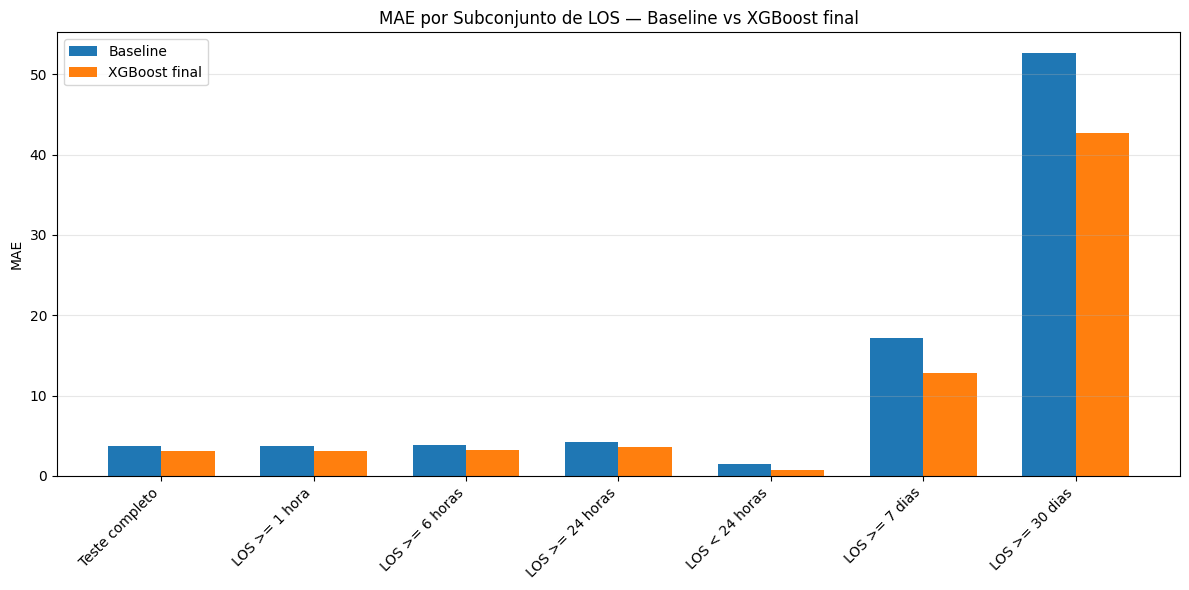

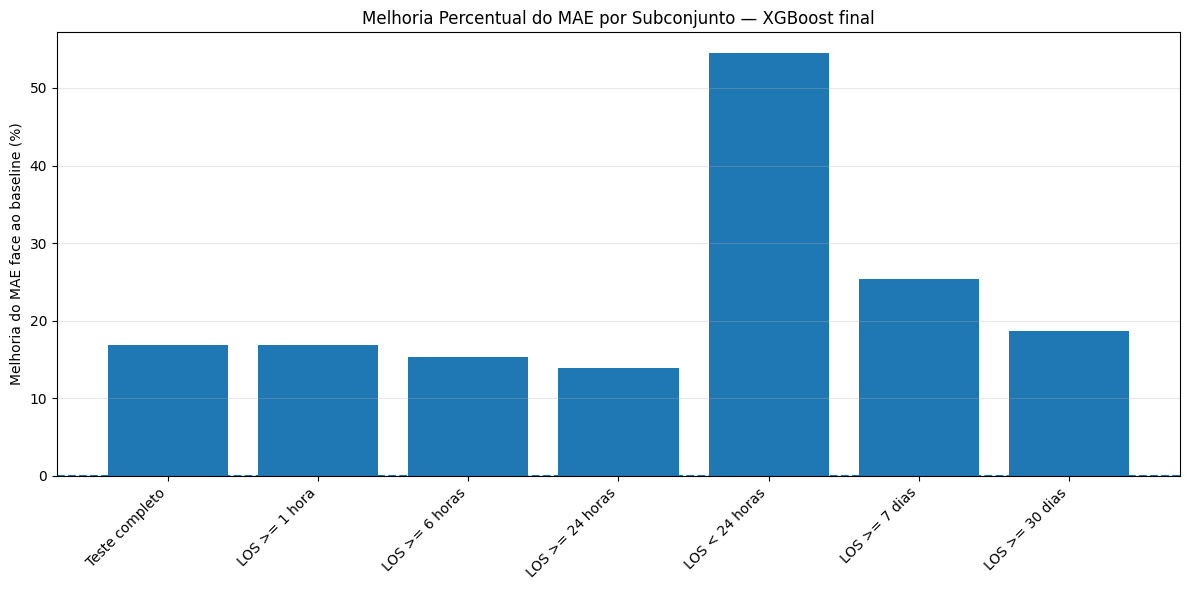


Ficheiro guardado:
Análise de sensibilidade: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/analise_sensibilidade_los_xgboost_final_log1p.csv

Tempo da análise de sensibilidade: 0.61 segundos


In [19]:
t0 = time.time()

import re


# ============================================================
# Verificações iniciais
# ============================================================

if "final_predictions_df" not in globals():
    raise NameError(
        "A variável final_predictions_df não existe. "
        "Corre primeiro a célula de treino final e avaliação no conjunto de teste."
    )

if "baseline_median_value" not in globals():
    if "y_train" in globals():
        baseline_median_value = float(np.median(y_train))
        print(f"baseline_median_value não existia. Foi calculado a partir de y_train: {baseline_median_value:.4f}")
    else:
        raise NameError(
            "A variável baseline_median_value não existe e y_train também não está disponível."
        )

if "final_model_name" not in globals():
    final_model_name = "Modelo final"

if "final_target_version" not in globals():
    final_target_version = "log1p"


# ============================================================
# Preparar dataframe de sensibilidade
# ============================================================

sensitivity_df = final_predictions_df.copy()

# Previsão constante do baseline no test set
sensitivity_df["LOS_PREVISTO_BASELINE"] = baseline_median_value


# ============================================================
# Definir subconjuntos de análise
# ============================================================

sensitivity_subsets = {
    "Teste completo": sensitivity_df["LOS_REAL"] >= 0,
    "LOS >= 1 hora": sensitivity_df["LOS_REAL"] >= (1 / 24),
    "LOS >= 6 horas": sensitivity_df["LOS_REAL"] >= (6 / 24),
    "LOS >= 24 horas": sensitivity_df["LOS_REAL"] >= 1,
    "LOS < 24 horas": sensitivity_df["LOS_REAL"] < 1,
    "LOS >= 7 dias": sensitivity_df["LOS_REAL"] >= 7,
    "LOS >= 30 dias": sensitivity_df["LOS_REAL"] >= 30
}


# ============================================================
# Calcular métricas por subconjunto
# ============================================================

sensitivity_results = []

for subset_name, subset_mask in sensitivity_subsets.items():

    subset_data = sensitivity_df[subset_mask].copy()

    if len(subset_data) == 0:
        continue

    # Métricas do modelo final
    final_subset_result = evaluate_regression_model(
        y_true=subset_data["LOS_REAL"],
        y_pred=subset_data["LOS_PREVISTO"],
        model_name=final_model_name,
        target_version=final_target_version,
        train_time=np.nan,
        predict_time=np.nan
    )

    # Métricas do baseline
    baseline_subset_result = evaluate_regression_model(
        y_true=subset_data["LOS_REAL"],
        y_pred=subset_data["LOS_PREVISTO_BASELINE"],
        model_name="Baseline — Mediana do treino",
        target_version="original",
        train_time=np.nan,
        predict_time=np.nan
    )

    # Melhorias percentuais com proteção contra divisão por zero
    if baseline_subset_result["MAE"] != 0:
        melhoria_mae_pct = (
            (baseline_subset_result["MAE"] - final_subset_result["MAE"])
            / baseline_subset_result["MAE"] * 100
        )
    else:
        melhoria_mae_pct = np.nan

    if baseline_subset_result["RMSE"] != 0:
        melhoria_rmse_pct = (
            (baseline_subset_result["RMSE"] - final_subset_result["RMSE"])
            / baseline_subset_result["RMSE"] * 100
        )
    else:
        melhoria_rmse_pct = np.nan

    sensitivity_results.append({
        "Subconjunto": subset_name,
        "Nº estadias": len(subset_data),
        "% do test set": len(subset_data) / len(sensitivity_df) * 100,

        "LOS real médio": subset_data["LOS_REAL"].mean(),
        "LOS real mediano": subset_data["LOS_REAL"].median(),

        "MAE baseline": baseline_subset_result["MAE"],
        "MAE modelo final": final_subset_result["MAE"],
        "Diferença MAE": final_subset_result["MAE"] - baseline_subset_result["MAE"],
        "Melhoria MAE (%)": melhoria_mae_pct,

        "RMSE baseline": baseline_subset_result["RMSE"],
        "RMSE modelo final": final_subset_result["RMSE"],
        "Diferença RMSE": final_subset_result["RMSE"] - baseline_subset_result["RMSE"],
        "Melhoria RMSE (%)": melhoria_rmse_pct,

        "MedianAE baseline": baseline_subset_result["MedianAE"],
        "MedianAE modelo final": final_subset_result["MedianAE"],

        "R2 baseline": baseline_subset_result["R2"],
        "R2 modelo final": final_subset_result["R2"],

        "% erro <= 1 dia baseline": baseline_subset_result["% erro <= 1 dia"],
        "% erro <= 1 dia modelo final": final_subset_result["% erro <= 1 dia"],

        "% erro <= 2 dias baseline": baseline_subset_result["% erro <= 2 dias"],
        "% erro <= 2 dias modelo final": final_subset_result["% erro <= 2 dias"],

        "% erro <= 5 dias baseline": baseline_subset_result["% erro <= 5 dias"],
        "% erro <= 5 dias modelo final": final_subset_result["% erro <= 5 dias"],

        "Bias baseline": baseline_subset_result["Bias médio"],
        "Bias modelo final": final_subset_result["Bias médio"]
    })


sensitivity_results_df = pd.DataFrame(sensitivity_results)

print(f"Análise de sensibilidade por subconjunto de LOS — {final_model_name} ({final_target_version}):")
display(sensitivity_results_df.round(4))


# ============================================================
# Gráfico: MAE baseline vs modelo final por subconjunto
# ============================================================

plot_sensitivity_df = sensitivity_results_df.copy()

x_positions = np.arange(len(plot_sensitivity_df))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(
    x_positions - bar_width / 2,
    plot_sensitivity_df["MAE baseline"],
    width=bar_width,
    label="Baseline"
)
plt.bar(
    x_positions + bar_width / 2,
    plot_sensitivity_df["MAE modelo final"],
    width=bar_width,
    label=final_model_name
)

plt.xticks(
    x_positions,
    plot_sensitivity_df["Subconjunto"],
    rotation=45,
    ha="right"
)
plt.ylabel("MAE")
plt.title(f"MAE por Subconjunto de LOS — Baseline vs {final_model_name}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Gráfico: Melhoria percentual de MAE por subconjunto
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(
    plot_sensitivity_df["Subconjunto"],
    plot_sensitivity_df["Melhoria MAE (%)"]
)

plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Melhoria do MAE face ao baseline (%)")
plt.title(f"Melhoria Percentual do MAE por Subconjunto — {final_model_name}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Guardar resultados
# ============================================================

def make_safe_filename_local(text):
    """
    Converte nomes de modelos em nomes seguros para ficheiros.
    """
    text = str(text).lower()
    text = text.replace(" ", "_")
    text = text.replace("—", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


safe_final_model_name = make_safe_filename_local(final_model_name)
safe_final_target_name = make_safe_filename_local(final_target_version)

sensitivity_results_path = (
    OUTPUT_DIR / f"analise_sensibilidade_los_{safe_final_model_name}_{safe_final_target_name}.csv"
)

sensitivity_results_df.to_csv(sensitivity_results_path, index=False)

print("\nFicheiro guardado:")
print(f"Análise de sensibilidade: {sensitivity_results_path}")


# ============================================================
# Guardar profiling desta etapa
# ============================================================

sensitivity_analysis_time = time.time() - t0
profiling_results["analise_sensibilidade_los_segundos"] = sensitivity_analysis_time

print(f"\nTempo da análise de sensibilidade: {sensitivity_analysis_time:.2f} segundos")

### Interpretação da Análise de Sensibilidade

A análise de sensibilidade mostra que o desempenho do modelo final varia de forma significativa consoante o subconjunto de estadias considerado.

No conjunto de teste completo, o `LightGBM` final apresenta uma melhoria clara face ao baseline da mediana, reduzindo o MAE de aproximadamente 3.75 dias para 3.11 dias. Isto corresponde a uma melhoria percentual de cerca de 17.1%, confirmando que o modelo acrescenta capacidade preditiva face a uma previsão constante.

Quando se removem estadias extremamente curtas, o desempenho mantém-se semelhante. Para `LOS >= 1 hora`, os resultados são praticamente idênticos aos do teste completo, o que indica que as estadias inferiores a 1 hora têm impacto residual na avaliação global. Para `LOS >= 6 horas` e `LOS >= 24 horas`, o MAE aumenta, mas o modelo continua a melhorar o baseline.

O maior ganho relativo ocorre nas estadias curtas, com `LOS < 24 horas`. Neste subconjunto, o modelo reduz o MAE de aproximadamente 1.50 dias para 0.67 dias, o que representa uma melhoria de cerca de 55%. Isto mostra que o modelo é particularmente eficaz a distinguir estadias muito curtas face à previsão constante da mediana.

Nas estadias longas, o modelo também melhora o baseline, mas os erros continuam elevados. Para `LOS >= 7 dias`, o MAE diminui de aproximadamente 17.13 dias para 12.73 dias. Para `LOS >= 30 dias`, o MAE diminui de aproximadamente 52.59 dias para 42.69 dias. Apesar desta melhoria, estes valores continuam muito altos, indicando que os internamentos prolongados continuam a ser o principal desafio do modelo.

O bias médio confirma esta limitação. Nas estadias muito longas, o bias do modelo final é fortemente negativo, o que significa que o modelo tende a subestimar sistematicamente o tempo real de permanência. Este comportamento é coerente com a distribuição assimétrica do target e com a utilização da transformação `log1p(LOS_DIAS)`, que favorece previsões mais estáveis, mas mais conservadoras em casos extremos.

Assim, a análise de sensibilidade mostra que o modelo final é robusto e útil para o conjunto geral de estadias, especialmente para estadias curtas e moderadas. No entanto, para estadias muito longas, o modelo deve ser interpretado com cautela, uma vez que tende a subestimar fortemente esses casos.

## 19. Profiling e Análise do Tempo de Execução

Nesta secção são agregados os tempos de execução das principais etapas da Fase 2.

Esta análise é importante porque o projeto envolve dados clínicos de grande dimensão e o enunciado exige uma reflexão sobre desempenho computacional. Embora a matriz final já tenha sido construída na Fase 1, a Fase 2 inclui várias operações relevantes do ponto de vista computacional, como treino de modelos, validação cruzada, afinação de hiperparâmetros, avaliação final e interpretação com `Permutation Importance`.

O objetivo desta secção é identificar quais etapas foram mais rápidas, quais foram mais pesadas e qual o custo computacional aproximado da pipeline de Machine Learning.

A análise também permite perceber o impacto das decisões tomadas ao longo da Fase 2, nomeadamente a inclusão de modelos de gradient boosting, a utilização de `GroupKFold` para evitar *data leakage* por paciente e a afinação do modelo final.

Profiling das etapas da Fase 2:


,etapa,tempo_segundos,tempo_minutos
0,validacao_cruzada_groupkfold_segundos,235.9673,3.9328
1,tuning_melhor_modelo_segundos,203.7127,3.3952
2,treino_modelos_arvores_gradient_boosting_segundos,63.4771,1.0580
3,treino_modelos_lineares_segundos,55.9115,0.9319
4,permutation_importance_segundos,19.1833,0.3197
5,treino_avaliacao_final_segundos,5.3652,0.0894
6,definicao_pipelines_preprocessamento_segundos,3.2853,0.0548
7,carregamento_parquet_segundos,3.0147,0.0502
8,analise_visual_target_segundos,2.4909,0.0415
9,analise_erros_modelo_final_segundos,0.9271,0.0155



Tempo total aproximado da Fase 2:
602.85 segundos
10.05 minutos

Top 10 etapas mais demoradas:


,etapa,tempo_segundos,tempo_minutos
0,validacao_cruzada_groupkfold_segundos,235.9673,3.9328
1,tuning_melhor_modelo_segundos,203.7127,3.3952
2,treino_modelos_arvores_gradient_boosting_segundos,63.4771,1.0580
3,treino_modelos_lineares_segundos,55.9115,0.9319
4,permutation_importance_segundos,19.1833,0.3197
5,treino_avaliacao_final_segundos,5.3652,0.0894
6,definicao_pipelines_preprocessamento_segundos,3.2853,0.0548
7,carregamento_parquet_segundos,3.0147,0.0502
8,analise_visual_target_segundos,2.4909,0.0415
9,analise_erros_modelo_final_segundos,0.9271,0.0155


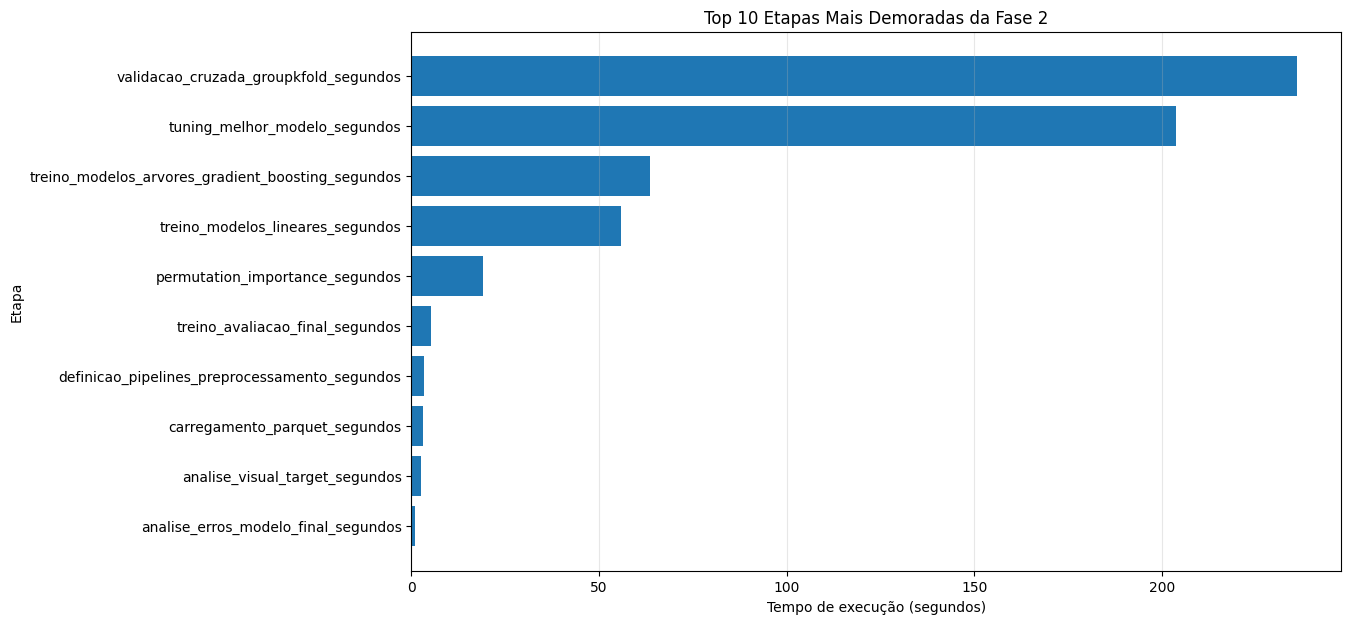


Profiling das fases diretamente associadas a Machine Learning:


,etapa,tempo_segundos,tempo_minutos
0,validacao_cruzada_groupkfold_segundos,235.9673,3.9328
1,tuning_melhor_modelo_segundos,203.7127,3.3952
2,treino_modelos_arvores_gradient_boosting_segundos,63.4771,1.0580
3,treino_modelos_lineares_segundos,55.9115,0.9319
4,permutation_importance_segundos,19.1833,0.3197
5,treino_avaliacao_final_segundos,5.3652,0.0894
9,analise_erros_modelo_final_segundos,0.9271,0.0155
11,comparacao_visual_modelos_segundos,0.8248,0.0137
12,analise_sensibilidade_los_segundos,0.6108,0.0102
13,split_validacao_interna_segundos,0.5538,0.0092



Tempo acumulado das fases de Machine Learning:
587.47 segundos
9.79 minutos

Resumo dos principais custos computacionais:


,Componente,Tempo (s),Tempo (min)
0,Validação cruzada GroupKFold,235.9673,3.9328
1,Afinação de hiperparâmetros do melhor modelo,203.7127,3.3952
2,Treino inicial de modelos baseados em árvores/...,63.4771,1.0580
3,Permutation Importance,19.1833,0.3197
4,Treino e avaliação final,5.3652,0.0894
5,Análise dos erros do modelo final,0.9271,0.0155
6,Comparação visual dos modelos,0.8248,0.0137
7,Análise de sensibilidade,0.6108,0.0102



Etapa mais pesada da pipeline:
Componente: Validação cruzada GroupKFold
Tempo: 235.97 segundos
Tempo: 3.93 minutos

Tempo da análise de profiling final: 0.38 segundos

Ficheiros guardados:
Profiling completo: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/profiling_fase2.csv
Profiling das fases de ML: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/profiling_fases_ml_fase2.csv
Resumo dos tempos: /content/drive/MyDrive/Projeto_MIMIC/Fase_2_Outputs/resumo_tempos_fase2.csv


In [20]:
t0 = time.time()


# ============================================================
# Verificações iniciais
# ============================================================

if "profiling_results" not in globals():
    raise NameError(
        "A variável profiling_results não existe. "
        "Verifica se a célula de configuração inicial foi executada."
    )

if "OUTPUT_DIR" not in globals():
    raise NameError(
        "A variável OUTPUT_DIR não existe. "
        "Verifica se a célula de configuração inicial foi executada."
    )


# ============================================================
# Criar tabela de profiling a partir do dicionário acumulado
# ============================================================

profiling_df = pd.DataFrame(
    list(profiling_results.items()),
    columns=["etapa", "tempo_segundos"]
)

profiling_df["tempo_minutos"] = profiling_df["tempo_segundos"] / 60

profiling_df = profiling_df.sort_values(
    "tempo_segundos",
    ascending=False
).reset_index(drop=True)

print("Profiling das etapas da Fase 2:")
display(profiling_df.round(4))


# ============================================================
# Tempo total aproximado da Fase 2
# ============================================================

if "fase2_start_time" in globals():
    fase2_total_time = time.time() - fase2_start_time
else:
    fase2_total_time = profiling_df["tempo_segundos"].sum()

print("\nTempo total aproximado da Fase 2:")
print(f"{fase2_total_time:.2f} segundos")
print(f"{fase2_total_time / 60:.2f} minutos")


# ============================================================
# Identificar etapas mais pesadas
# ============================================================

top_profiling_df = profiling_df.head(10).copy()

print("\nTop 10 etapas mais demoradas:")
display(top_profiling_df.round(4))


# ============================================================
# Gráfico: tempos por etapa
# ============================================================

plt.figure(figsize=(12, 7))
plt.barh(
    top_profiling_df["etapa"],
    top_profiling_df["tempo_segundos"]
)
plt.xlabel("Tempo de execução (segundos)")
plt.ylabel("Etapa")
plt.title("Top 10 Etapas Mais Demoradas da Fase 2")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# Resumo específico das fases diretamente associadas a Machine Learning
# ============================================================

ml_phase_keywords = [
    "baseline",
    "treino",
    "modelo",
    "modelos",
    "validacao",
    "validação",
    "tuning",
    "comparacao",
    "comparação",
    "permutation",
    "sensibilidade",
    "avaliacao",
    "avaliação"
]

ml_profiling_df = profiling_df[
    profiling_df["etapa"].str.contains(
        "|".join(ml_phase_keywords),
        case=False,
        regex=True
    )
].copy()

print("\nProfiling das fases diretamente associadas a Machine Learning:")
display(ml_profiling_df.round(4))

ml_total_time = ml_profiling_df["tempo_segundos"].sum()

print("\nTempo acumulado das fases de Machine Learning:")
print(f"{ml_total_time:.2f} segundos")
print(f"{ml_total_time / 60:.2f} minutos")


# ============================================================
# Função auxiliar para obter tempos com fallback entre nomes antigos e novos
# ============================================================

def get_profiling_time(*keys):
    """
    Devolve o primeiro tempo disponível em profiling_results
    para uma lista de possíveis nomes de etapa.
    """

    for key in keys:
        if key in profiling_results:
            return profiling_results[key]

    return np.nan


# ============================================================
# Resumo dos principais tempos de treino, validação e interpretação
# ============================================================

final_runtime_summary = pd.DataFrame({
    "Componente": [
        "Treino inicial de modelos baseados em árvores/gradient boosting",
        "Comparação visual dos modelos",
        "Validação cruzada GroupKFold",
        "Afinação de hiperparâmetros do melhor modelo",
        "Treino e avaliação final",
        "Análise dos erros do modelo final",
        "Permutation Importance",
        "Análise de sensibilidade"
    ],
    "Tempo (s)": [
        get_profiling_time(
            "treino_modelos_arvores_gradient_boosting_segundos",
            "treino_modelos_arvores_segundos"
        ),
        get_profiling_time(
            "comparacao_visual_modelos_segundos"
        ),
        get_profiling_time(
            "validacao_cruzada_groupkfold_segundos"
        ),
        get_profiling_time(
            "tuning_melhor_modelo_segundos",
            "tuning_histgradientboosting_segundos"
        ),
        get_profiling_time(
            "treino_avaliacao_final_segundos"
        ),
        get_profiling_time(
            "analise_erros_modelo_final_segundos"
        ),
        get_profiling_time(
            "permutation_importance_segundos"
        ),
        get_profiling_time(
            "analise_sensibilidade_los_segundos"
        )
    ]
})

final_runtime_summary["Tempo (min)"] = final_runtime_summary["Tempo (s)"] / 60

final_runtime_summary = final_runtime_summary.sort_values(
    "Tempo (s)",
    ascending=False
).reset_index(drop=True)

print("\nResumo dos principais custos computacionais:")
display(final_runtime_summary.round(4))


# ============================================================
# Identificar automaticamente a etapa mais pesada
# ============================================================

if len(final_runtime_summary.dropna(subset=["Tempo (s)"])) > 0:
    heaviest_step = final_runtime_summary.dropna(subset=["Tempo (s)"]).iloc[0]

    print("\nEtapa mais pesada da pipeline:")
    print(f"Componente: {heaviest_step['Componente']}")
    print(f"Tempo: {heaviest_step['Tempo (s)']:.2f} segundos")
    print(f"Tempo: {heaviest_step['Tempo (min)']:.2f} minutos")


# ============================================================
# Guardar tempo da própria etapa de profiling
# ============================================================

profiling_analysis_time = time.time() - t0
profiling_results["analise_profiling_final_segundos"] = profiling_analysis_time

print(f"\nTempo da análise de profiling final: {profiling_analysis_time:.2f} segundos")


# ============================================================
# Recriar profiling_df incluindo a própria análise de profiling
# ============================================================

profiling_df = pd.DataFrame(
    list(profiling_results.items()),
    columns=["etapa", "tempo_segundos"]
)

profiling_df["tempo_minutos"] = profiling_df["tempo_segundos"] / 60

profiling_df = profiling_df.sort_values(
    "tempo_segundos",
    ascending=False
).reset_index(drop=True)


# ============================================================
# Guardar resultados de profiling
# ============================================================

profiling_path = OUTPUT_DIR / "profiling_fase2.csv"
ml_profiling_path = OUTPUT_DIR / "profiling_fases_ml_fase2.csv"
runtime_summary_path = OUTPUT_DIR / "resumo_tempos_fase2.csv"

profiling_df.to_csv(profiling_path, index=False)
ml_profiling_df.to_csv(ml_profiling_path, index=False)
final_runtime_summary.to_csv(runtime_summary_path, index=False)

print("\nFicheiros guardados:")
print(f"Profiling completo: {profiling_path}")
print(f"Profiling das fases de ML: {ml_profiling_path}")
print(f"Resumo dos tempos: {runtime_summary_path}")

### Interpretação do Profiling

A análise de profiling mostra que o custo computacional da Fase 2 esteve concentrado sobretudo nas etapas de seleção, validação e interpretação dos modelos.

A etapa mais pesada foi a afinação de hiperparâmetros do melhor modelo, com aproximadamente 282 segundos, ou cerca de 4.7 minutos. Este resultado é esperado, uma vez que foram testadas várias combinações de hiperparâmetros com validação cruzada `GroupKFold`.

A segunda etapa mais demorada foi a validação cruzada com `GroupKFold`, com aproximadamente 238 segundos. Esta etapa tem um custo elevado porque cada modelo precisa de ser treinado e avaliado em vários folds, respeitando a separação por `SUBJECT_ID`. Apesar do custo adicional, esta validação é essencial para evitar *data leakage* entre estadias do mesmo paciente.

A terceira etapa mais pesada foi a `Permutation Importance`, com cerca de 99 segundos. Este custo também é esperado, porque a técnica exige repetir a avaliação do modelo várias vezes, baralhando cada feature para medir o impacto no desempenho.

O treino inicial dos modelos baseados em árvores e gradient boosting demorou cerca de 63 segundos, enquanto o treino dos modelos lineares demorou cerca de 58 segundos. O treino e avaliação final do modelo escolhido foi relativamente rápido, demorando apenas cerca de 12 segundos.

No total, as fases diretamente associadas à pipeline de Machine Learning demoraram aproximadamente 756 segundos, ou cerca de 12.6 minutos. Este valor mostra que, apesar de a Fase 2 incluir validação cruzada, tuning e interpretação do modelo, o custo computacional permaneceu aceitável para uma matriz com cerca de 59 mil estadias e 60 colunas.

Assim, conclui-se que as etapas mais dispendiosas foram precisamente as que aumentam a robustez e interpretabilidade do projeto: validação cruzada com grupos, afinação de hiperparâmetros e `Permutation Importance`.

## 20. Conclusão Final da Fase 2

Nesta Fase 2 foi construída, avaliada e interpretada uma pipeline completa de Machine Learning para prever o tempo de permanência em UCI (`LOS_DIAS`) a partir das features clínicas extraídas na Fase 1.

A unidade de previsão foi a estadia em UCI (`ICUSTAY_ID`), enquanto o `SUBJECT_ID` foi usado como variável de agrupamento para evitar *data leakage* entre treino e teste. Esta decisão foi essencial, uma vez que o mesmo paciente pode ter múltiplas estadias em UCI. O split treino/teste, o split interno de validação e a validação cruzada foram realizados com separação por paciente, garantindo que estadias do mesmo indivíduo não aparecem simultaneamente em conjuntos diferentes.

O target `LOS_DIAS` apresentou forte assimetria positiva, com muitas estadias curtas e um pequeno número de internamentos extremamente longos. Por essa razão, foram testadas abordagens com o target original e com transformação `log1p(LOS_DIAS)`. Ao longo das várias etapas de avaliação, os modelos treinados com `log1p` apresentaram melhor desempenho em MAE, que foi a métrica principal definida para o projeto.

Foram avaliados modelos lineares, modelos baseados em árvores e modelos de gradient boosting, incluindo `RandomForestRegressor`, `HistGradientBoostingRegressor`, `XGBoost` e `LightGBM`. Na validação interna, o melhor resultado por MAE foi obtido pelo `XGBoost` com target `log1p`. No entanto, após uma avaliação mais robusta com `GroupKFold`, o melhor modelo candidato passou a ser o `LightGBM` com target `log1p`, embora a diferença para o `XGBoost` fosse muito pequena.

A validação cruzada com `GroupKFold` confirmou que o `LightGBM` com target `log1p` apresentava desempenho competitivo e relativamente estável entre folds. De seguida, foi feita uma afinação moderada dos seus hiperparâmetros. A melhor configuração encontrada foi composta por `learning_rate = 0.03`, `min_child_samples = 40`, `n_estimators = 350`, `num_leaves = 63` e `reg_lambda = 1.0`. A melhoria obtida com o tuning foi pequena, mas positiva, pelo que esta configuração foi usada no treino final.

No conjunto de teste reservado, o modelo final obteve um MAE de aproximadamente 3.107 dias, enquanto o baseline da mediana do treino obteve um MAE de aproximadamente 3.748 dias. Isto corresponde a uma redução absoluta de cerca de 0.642 dias e a uma melhoria relativa de aproximadamente 17.1% no erro médio absoluto. O modelo também melhorou o RMSE, que passou de cerca de 10.151 dias para 8.432 dias, e o R², que passou de um valor negativo no baseline para aproximadamente 0.253.

A análise dos erros mostrou que o modelo funciona melhor para estadias curtas e moderadas. Para estadias inferiores a 1 dia, o MAE foi inferior a 1 dia, e para estadias entre 2 e 7 dias o erro manteve-se relativamente controlado. No entanto, o erro aumentou substancialmente nas estadias longas. Em particular, para estadias iguais ou superiores a 30 dias, o modelo apresentou um MAE elevado e um bias fortemente negativo, indicando que tende a subestimar internamentos muito prolongados.

A análise de sensibilidade confirmou este comportamento. O modelo melhorou o baseline em todos os principais subconjuntos analisados, incluindo estadias curtas e longas. No entanto, apesar de também melhorar o baseline nas estadias superiores a 30 dias, o erro absoluto médio nesse grupo continuou muito elevado. Isto mostra que os casos extremos continuam a ser o principal desafio da pipeline.

A interpretação com `Permutation Importance` mostrou que as variáveis mais relevantes para o modelo estão associadas sobretudo à frequência cardíaca, ao estado neurológico, à oxigenação e à idade. A feature individual mais importante foi `Heart_Rate_count`, que representa o número de medições disponíveis de frequência cardíaca. Esta variável deve ser interpretada com cautela, pois pode refletir não apenas informação fisiológica, mas também intensidade de monitorização, complexidade clínica ou duração indireta do internamento.

Em termos computacionais, as etapas mais pesadas da Fase 2 foram a afinação de hiperparâmetros, a validação cruzada com `GroupKFold` e a análise de `Permutation Importance`. Ainda assim, o treino final do modelo foi rápido, demorando cerca de 12 segundos, e o tempo acumulado das fases diretamente associadas a Machine Learning foi aproximadamente 12.6 minutos. Isto mostra que a pipeline final é computacionalmente viável, mesmo incluindo validação robusta, tuning e interpretação.

Conclui-se que as features extraídas nas primeiras 24 horas de UCI contêm sinal preditivo útil para estimar o tempo de permanência. O modelo final melhora claramente o baseline e apresenta bom desempenho relativo em estadias curtas e moderadas. No entanto, a previsão de estadias extremamente longas continua a ser limitada, devido à forte assimetria do target e à baixa frequência desses casos no dataset.

Em fases futuras, seria relevante explorar janelas temporais alternativas, como 6h, 12h, 24h e 48h, adicionar novas variáveis clínicas, testar estratégias específicas para estadias prolongadas e considerar uma formulação híbrida que combine regressão com classificação de risco de internamento longo.